<a href="https://colab.research.google.com/github/imagra93/ML-course-labs/blob/main/notebooks/extra/extra 01 - Graph Neural Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab · Graph Neural Networks (GNNs)

An MLP takes a vector. A CNN takes a grid of pixels, a recurrent network a sequence, a transformer a set of tokens with positions. A lot of data has none of these shapes. It is a **graph**: a set of objects plus the relations between them. Molecules are atoms linked by bonds. Papers cite papers, people follow people, roads join crossings. In insurance, claims, policyholders, garages, phone numbers and bank accounts form a graph, and **fraud rings** show up as suspicious structures in it. A graph has no natural order of its nodes and no fixed number of neighbours per node, so none of the previous architectures applies directly.

A **graph neural network** computes a vector for every node by repeatedly passing messages along the edges. In this lab we build one from scratch, see what it computes (a smoothing filter on the graph), train it on the classic benchmarks, and study its limits.

**Contents**

1. Graphs as data
2. Why not an MLP on the adjacency matrix: permutations
3. Message passing by hand on a toy graph
4. The Laplacian, smoothness and why GCN is a low-pass filter
5. A GCN from scratch in PyTorch (dense)
6. Sparse message passing with `edge_index`
7. Node classification on Cora
8. Graph attention (GAT) from scratch
9. Depth and over-smoothing in practice
10. Expressive power: aggregators and the Weisfeiler–Lehman test
11. Graph classification on MUTAG
12. Link prediction and edge leakage
13. Summary and exercises

This lab goes with the slides *Extra 1 · Graph neural networks* and uses the same notation. It assumes the neural-network part of the course: MLPs, backpropagation, the PyTorch training loop and attention. Everything runs on a CPU in a few minutes (about 3 with 4 CPU threads); a GPU is not needed.

**Notation**

| Symbol | Meaning |
|---|---|
| $G = (V, E)$ | graph with $n = \lvert V \rvert$ nodes and $\lvert E \rvert$ edges |
| $\mathbf{X} \in \mathbb{R}^{n \times d}$ | node features, **one row per node** (as $\mathbf{Z} = \mathbf{X}\mathbf{W} + \mathbf{b}$ in the rest of the course) |
| $\mathbf{A} \in \{0, 1\}^{n \times n}$ | adjacency matrix: $A_{uv} = 1$ if $u$ and $v$ are linked |
| $d_v$, $\mathbf{D} = \operatorname{diag}(d_1, \dots, d_n)$, $\mathcal{N}(v)$ | degree of $v$, degree matrix, neighbours of $v$ |
| $\tilde{\mathbf{A}} = \mathbf{A} + \mathbf{I}$, $\tilde{\mathbf{D}}$, $\tilde d_v = d_v + 1$ | adjacency with self-loops and its degrees |
| $\hat{\mathbf{A}} = \tilde{\mathbf{D}}^{-1/2}\tilde{\mathbf{A}}\tilde{\mathbf{D}}^{-1/2}$ | normalised adjacency used by GCN |
| $\mathbf{H}^{(k)}$, $\mathbf{H}^{(0)} = \mathbf{X}$; $\mathbf{W}^{(k)}$ | node embeddings after layer $k$; weights of layer $k$ |
| $\mathbf{L} = \mathbf{D} - \mathbf{A}$ | graph Laplacian |
| `edge_index` | $2 \times \lvert E \rvert$ integer tensor of (source, target) pairs, both directions stored |
| $\mathbf{P}$ | permutation matrix: the relabelled graph is $(\mathbf{P}\mathbf{X}, \mathbf{P}\mathbf{A}\mathbf{P}^\top)$ |

In [1]:
import random, time
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
import torch
import torch.nn as nn
import torch.nn.functional as F
plt.rcParams.update({"figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})
np.set_printoptions(precision=3, suppress=True)
random.seed(0); np.random.seed(0); torch.manual_seed(0)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device, "| torch", torch.__version__, "| networkx", nx.__version__)
T_START = time.time()

device: cpu | torch 2.12.0+cu130 | networkx 3.6.1


In [2]:
try:
    import torch_geometric
except ImportError:                       # e.g. on Colab: PyG is pure Python, the install takes a few seconds
    %pip install -q torch_geometric
    import torch_geometric
import torch_geometric.transforms as T
from torch_geometric.datasets import Planetoid, TUDataset
from torch_geometric.loader import DataLoader
from torch_geometric.nn import GCNConv, GATConv, GINConv, global_add_pool, global_mean_pool, global_max_pool
from torch_geometric.utils import k_hop_subgraph, negative_sampling, to_dense_adj, to_networkx
import warnings                           # harmless speed hint printed by global_max_pool on GPU
warnings.filterwarnings("ignore", message=".*can be accelerated via the 'torch-scatter' package.*")
print("torch_geometric", torch_geometric.__version__)

torch_geometric 2.8.0.post1


## 1. Graphs as data

A graph $G = (V, E)$ is a set of $n$ nodes and a set of edges between them. In this lab graphs are **undirected** (an edge $u$–$v$ goes both ways) and unweighted. Three matrices describe a graph with node features:

- the **adjacency matrix** $\mathbf{A} \in \{0,1\}^{n \times n}$, with $A_{uv} = A_{vu} = 1$ if $u$ and $v$ are linked. It is symmetric, and its row sums are the **degrees** $d_v = \sum_u A_{vu} = \lvert\mathcal{N}(v)\rvert$;
- the **degree matrix** $\mathbf{D} = \operatorname{diag}(d_1, \dots, d_n)$;
- the **feature matrix** $\mathbf{X} \in \mathbb{R}^{n \times d}$, one row per node.

In code we rarely store $\mathbf{A}$. We store the list of its non-zero entries, `edge_index`, a $2 \times \lvert E \rvert$ integer tensor whose column $(u, v)$ means "there is an edge from $u$ to $v$". An undirected edge is stored twice, as $(u, v)$ and $(v, u)$.

Our first graph is **Zachary's karate club** (1977): 34 members of a university karate club, with an edge when two members met outside the club. The club split in two after a conflict between the instructor (node 0, "Mr. Hi") and the administrator (node 33, "Officer"). Each node has a `club` attribute that says which side the member joined. The question for sections 1 to 5: can we predict a member's faction from the friendship graph alone?

In [3]:
G = nx.karate_club_graph()
n_k = G.number_of_nodes()
y_k = np.array([0 if G.nodes[v]["club"] == "Mr. Hi" else 1 for v in G])   # 0 = Mr. Hi, 1 = Officer
pos_k = nx.spring_layout(G, seed=3)               # one fixed layout, reused in the whole notebook
FACTION = np.array(["tab:blue", "tab:orange"])    # colour of each faction

def draw_graph(ax, G, pos, node_color="lightgray", labels=True, node_size=220, cmap=None,
               vmin=None, vmax=None, edge_width=0.8, title=""):
    """Draw G with a fixed layout; returns the node collection (for colour bars)."""
    nx.draw_networkx_edges(G, pos, ax=ax, width=edge_width, alpha=0.4)
    nodes = nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_color, node_size=node_size, cmap=cmap,
                                   vmin=vmin, vmax=vmax, edgecolors="k", linewidths=0.5)
    if labels:
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
    ax.set_title(title); ax.axis("off")
    return nodes

print(f"nodes: {n_k}   edges: {G.number_of_edges()}   (expected 34 and 78)")
print(f"faction sizes: Mr. Hi {np.sum(y_k == 0)}, Officer {np.sum(y_k == 1)}")

nodes: 34   edges: 78   (expected 34 and 78)
faction sizes: Mr. Hi 17, Officer 17


A symmetric: True   number of ones: 156  (= 2|E| = 156)
density: 0.135   mean degree: 4.59 (= 2|E| / n)
largest degrees: node 33 -> 17 , node 0 -> 16   (the two leaders)
edge_index shape: (2, 156)   first 8 columns (source row, target row):
tensor([[0, 0, 0, 0, 0, 0, 0, 0],
        [1, 2, 3, 4, 5, 6, 7, 8]])
fraction of edges inside one faction: 0.859


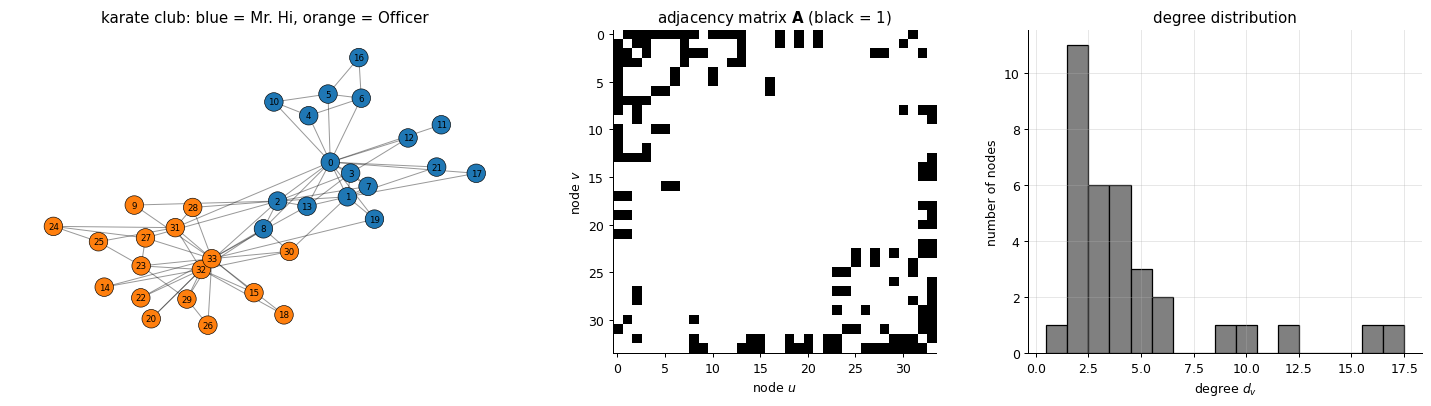

In [4]:
A_k = nx.to_numpy_array(G, nodelist=range(n_k), weight=None)   # weight=None: 0/1 entries (the graph also stores weights)
deg_k = A_k.sum(1)                                             # d_v = row sums of A
D_k = np.diag(deg_k)
src_k, dst_k = np.nonzero(A_k)                                 # every non-zero entry of A is one directed edge
edge_index_k = torch.tensor(np.array([src_k, dst_k]), dtype=torch.long)
same_k = np.mean(y_k[src_k] == y_k[dst_k])

print("A symmetric:", np.array_equal(A_k, A_k.T), "  number of ones:", int(A_k.sum()), " (= 2|E| = 156)")
print(f"density: {A_k.sum() / n_k**2:.3f}   mean degree: {deg_k.mean():.2f} (= 2|E| / n)")
print("largest degrees: node 33 ->", int(deg_k[33]), ", node 0 ->", int(deg_k[0]), "  (the two leaders)")
print("edge_index shape:", tuple(edge_index_k.shape), "  first 8 columns (source row, target row):")
print(edge_index_k[:, :8])
print(f"fraction of edges inside one faction: {same_k:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1.3, 1, 1]})
draw_graph(axes[0], G, pos_k, node_color=FACTION[y_k], title="karate club: blue = Mr. Hi, orange = Officer")
axes[1].imshow(A_k, cmap="Greys"); axes[1].grid(False)
axes[1].set_title(r"adjacency matrix $\mathbf{A}$ (black = 1)"); axes[1].set_xlabel("node $u$"); axes[1].set_ylabel("node $v$")
axes[2].hist(deg_k, bins=np.arange(0.5, 18.5), color="gray", edgecolor="k")
axes[2].set_xlabel("degree $d_v$"); axes[2].set_ylabel("number of nodes"); axes[2].set_title("degree distribution")
plt.tight_layout(); plt.show()

**Things to notice.**
- Most members have between 2 and 5 friends, but two have 16 and 17: the leaders, nodes 0 and 33. These **hubs** are typical of social networks, whose degree distributions have a long right tail. Section 3 shows why hubs need special care.
- $\mathbf{A}$ is symmetric and sparse: only 13.5% of its entries are 1. Real graphs are far sparser (a social network with $10^8$ users and a few hundred friends each has a density of about $10^{-6}$), so we store `edge_index` instead of $\mathbf{A}$. Section 6 builds the whole model on `edge_index`.
- The two factions are visible in the drawing, and 86% of the edges join two members of the same faction. The graph alone carries most of the label information. This property is called **homophily**, and section 7 shows that GNNs depend on it.

**Three kinds of tasks.** All three use the same building block, a GNN that computes an embedding vector $\mathbf{h}_v$ for every node. They differ in what is read out.

| Level | Predict | Read out | Examples | In this lab |
|---|---|---|---|---|
| node | a label per node | $\mathbf{h}_v$ | faction of a member, topic of a paper, is this claim fraudulent | karate club, Cora (sections 5, 7–9) |
| edge | whether two nodes are (or will be) linked | a function of $\mathbf{h}_u$ and $\mathbf{h}_v$ | friend recommendation, drug–drug interaction, is this claimant linked to this garage | Cora links (section 12) |
| graph | a label per whole graph | a pooling of all $\mathbf{h}_v$ | is this molecule mutagenic, toxic, soluble | MUTAG (section 11) |

## 2. Why not an MLP on the adjacency matrix: permutations

The simplest idea would be to flatten $\mathbf{A}$ into a vector of $n^2$ numbers and give it to an MLP. The problem is that **node numbers are arbitrary**. Relabelling the nodes gives the same graph, written down differently.

Let $\pi$ be a relabelling: new node $i$ is old node $\pi(i)$. Its **permutation matrix** $\mathbf{P}$ has $P_{i, \pi(i)} = 1$ and zeros elsewhere, so $\mathbf{P}$ reorders rows: $(\mathbf{P}\mathbf{X})_i = \mathbf{X}_{\pi(i)}$. The relabelled graph is

$$
(\mathbf{P}\mathbf{X},\; \mathbf{P}\mathbf{A}\mathbf{P}^\top), \qquad (\mathbf{P}\mathbf{A}\mathbf{P}^\top)_{ij} = A_{\pi(i)\pi(j)} .
$$

Left-multiplying by $\mathbf{P}$ reorders the rows, right-multiplying by $\mathbf{P}^\top$ reorders the columns in the same way. Below we relabel the karate club at random.

A == P A P^T as matrices?    False
same sorted degrees?         True
same graph (isomorphic)?     True
Mr. Hi (old node 0) is now node 15 and the Officer (old node 33) is now node 6


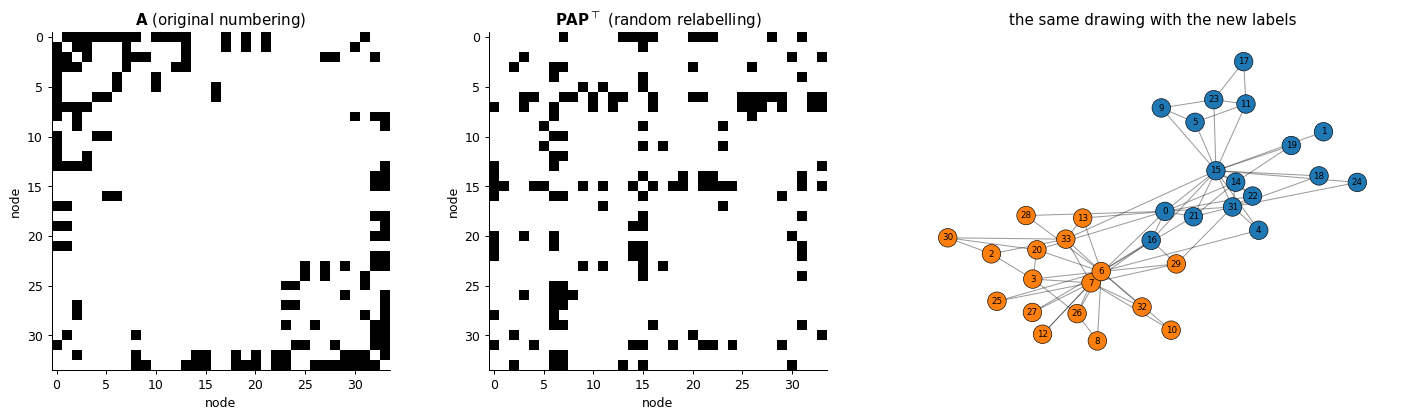

In [5]:
rng = np.random.default_rng(0)
perm = rng.permutation(n_k)                   # new node i is old node perm[i]
P = np.eye(n_k)[perm]                         # permutation matrix: (P X)[i] = X[perm[i]]
A_perm = P @ A_k @ P.T
assert np.array_equal(A_perm, A_k[np.ix_(perm, perm)])        # (P A P^T)[i, j] = A[perm[i], perm[j]]
inv = np.argsort(perm)                        # old node v is new node inv[v]

print("A == P A P^T as matrices?   ", np.array_equal(A_k, A_perm))
print("same sorted degrees?        ", np.array_equal(np.sort(A_k.sum(1)), np.sort(A_perm.sum(1))))
print("same graph (isomorphic)?    ", nx.is_isomorphic(nx.from_numpy_array(A_k), nx.from_numpy_array(A_perm)))
print("Mr. Hi (old node 0) is now node", inv[0], "and the Officer (old node 33) is now node", inv[33])

fig, axes = plt.subplots(1, 3, figsize=(16, 4.6), gridspec_kw={"width_ratios": [1, 1, 1.3]})
axes[0].imshow(A_k, cmap="Greys"); axes[0].set_title(r"$\mathbf{A}$ (original numbering)")
axes[1].imshow(A_perm, cmap="Greys"); axes[1].set_title(r"$\mathbf{P}\mathbf{A}\mathbf{P}^\top$ (random relabelling)")
for ax in axes[:2]:
    ax.grid(False); ax.set_xlabel("node"); ax.set_ylabel("node")
draw_graph(axes[2], G, pos_k, node_color=FACTION[y_k], labels=False, title="the same drawing with the new labels")
nx.draw_networkx_labels(G, pos_k, labels={v: inv[v] for v in G}, ax=axes[2], font_size=7)
plt.tight_layout(); plt.show()

The two matrices look unrelated, yet they describe the same club. An MLP on the flattened matrix ties each weight to one pair of node numbers, so it sees two different inputs. There are $34! \approx 3 \cdot 10^{38}$ ways to number this graph, and a model that had to learn that they are all equivalent would never see enough data. Same problem as the MLP on pixels in the CNN lab, but much worse: an image has one natural order of its pixels, a graph has none.

What we want instead:

- A **node-level** model $f$ (one output row per node) must be **permutation equivariant**: relabel the input, and the output is relabelled the same way,
$$ f(\mathbf{P}\mathbf{X}, \mathbf{P}\mathbf{A}\mathbf{P}^\top) = \mathbf{P}\, f(\mathbf{X}, \mathbf{A}). $$
- A **graph-level** model $g$ (one output per graph) must be **permutation invariant**: $g(\mathbf{P}\mathbf{X}, \mathbf{P}\mathbf{A}\mathbf{P}^\top) = g(\mathbf{X}, \mathbf{A})$.

We compare a random MLP on the flattened $\mathbf{A}$ with one random **GCN layer** $\mathbf{H} = \sigma(\hat{\mathbf{A}}\mathbf{X}\mathbf{W})$, the layer section 3 builds step by step. For now only its form matters: a matrix built from the graph multiplies $\mathbf{X}$ on the left (it mixes nodes), and a weight matrix multiplies on the right (it mixes features). For a graph-level output we add a **readout**: the sum (or mean, or max) of the rows of $\mathbf{H}$.

MLP on A               :   0.8064    on P A P^T:   1.3681   (same graph, different output)
GCN + sum readout [0]  :   6.3427    on P A P^T:   6.3427
max |f(PX, PAP^T) - P f(X, A)| = 4.4e-16   (equivariance: 0 up to rounding)
over 30 relabellings: std of the MLP output 0.804,  std of the GCN readout 5.6e-16


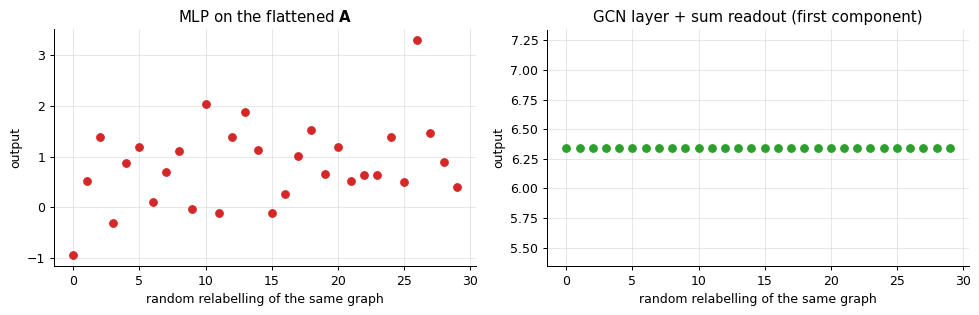

In [6]:
X_rand = rng.normal(size=(n_k, 4))                        # random node features (any features would do)
W1_mlp = rng.normal(size=(n_k * n_k, 16)) / n_k           # an MLP that reads the flattened A
W2_mlp = rng.normal(size=(16, 1))
W_gcn = rng.normal(size=(4, 8))                           # one GCN layer, 4 -> 8 features

def mlp_on_A(A):
    """Random MLP on the flattened adjacency matrix (n^2 inputs)."""
    return (np.maximum(0, A.reshape(1, -1) @ W1_mlp) @ W2_mlp).item()

def normalize_adj(A):
    """Â = D̃^{-1/2} (A + I) D̃^{-1/2} for a dense adjacency matrix."""
    A_tilde = A + np.eye(len(A))
    d_inv_sqrt = 1 / np.sqrt(A_tilde.sum(1))
    return d_inv_sqrt[:, None] * A_tilde * d_inv_sqrt[None, :]

def gcn_layer(X, A, W):
    """One GCN layer with ReLU: σ(Â X W)."""
    return np.maximum(0, normalize_adj(A) @ X @ W)

H = gcn_layer(X_rand, A_k, W_gcn)
H_perm = gcn_layer(P @ X_rand, A_perm, W_gcn)             # same layer, relabelled graph
print(f"MLP on A               : {mlp_on_A(A_k):8.4f}    on P A P^T: {mlp_on_A(A_perm):8.4f}   (same graph, different output)")
print(f"GCN + sum readout [0]  : {H.sum(0)[0]:8.4f}    on P A P^T: {H_perm.sum(0)[0]:8.4f}")
print(f"max |f(PX, PAP^T) - P f(X, A)| = {np.abs(H_perm - P @ H).max():.1e}   (equivariance: 0 up to rounding)")
assert np.allclose(H_perm, P @ H)                                      # node level: equivariant
for readout in (np.sum, np.mean, np.max):                             # graph level: invariant
    assert np.allclose(readout(H_perm, axis=0), readout(H, axis=0))

mlp_out, gcn_out = [], []
for _ in range(30):                                                    # 30 more random relabellings
    Pr = np.eye(n_k)[rng.permutation(n_k)]
    mlp_out.append(mlp_on_A(Pr @ A_k @ Pr.T))
    gcn_out.append(gcn_layer(Pr @ X_rand, Pr @ A_k @ Pr.T, W_gcn).sum(0)[0])
print(f"over 30 relabellings: std of the MLP output {np.std(mlp_out):.3f},  std of the GCN readout {np.std(gcn_out):.1e}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(mlp_out, "o", color="tab:red"); axes[0].set_title(r"MLP on the flattened $\mathbf{A}$")
axes[1].plot(gcn_out, "o", color="tab:green"); axes[1].set_title("GCN layer + sum readout (first component)")
axes[1].set_ylim(np.mean(gcn_out) - 1, np.mean(gcn_out) + 1)
for ax in axes:
    ax.set_xlabel("random relabelling of the same graph"); ax.set_ylabel("output")
plt.tight_layout(); plt.show()

**What just happened?** The MLP gives a different answer for every way of numbering the same club (standard deviation 0.80 over 30 relabellings). The GCN layer gives exactly the relabelled output, and its sum readout does not move at all (differences of order $10^{-15}$, pure rounding).

**Why the GCN layer is equivariant (proof).** Relabelling gives $\mathbf{P}\mathbf{A}\mathbf{P}^\top + \mathbf{I} = \mathbf{P}(\mathbf{A} + \mathbf{I})\mathbf{P}^\top = \mathbf{P}\tilde{\mathbf{A}}\mathbf{P}^\top$, because $\mathbf{P}\mathbf{P}^\top = \mathbf{I}$. The degrees are permuted the same way, $\tilde{\mathbf{D}}' = \mathbf{P}\tilde{\mathbf{D}}\mathbf{P}^\top$, and so is any function of a diagonal matrix: $\tilde{\mathbf{D}}'^{-1/2} = \mathbf{P}\tilde{\mathbf{D}}^{-1/2}\mathbf{P}^\top$. Hence $\hat{\mathbf{A}}' = \mathbf{P}\hat{\mathbf{A}}\mathbf{P}^\top$ and

$$
\sigma\big(\hat{\mathbf{A}}'\,\mathbf{P}\mathbf{X}\,\mathbf{W}\big) = \sigma\big(\mathbf{P}\hat{\mathbf{A}}\mathbf{P}^\top\mathbf{P}\mathbf{X}\mathbf{W}\big) = \sigma\big(\mathbf{P}\hat{\mathbf{A}}\mathbf{X}\mathbf{W}\big) = \mathbf{P}\,\sigma\big(\hat{\mathbf{A}}\mathbf{X}\mathbf{W}\big).
$$

The last step holds because $\sigma$ acts entry by entry, so it does not care in which order the rows come. $\blacksquare$

Two ideas make this work. $\mathbf{W}$ acts on the **feature** axis (columns), so it never sees node numbers: the same weights are shared by all nodes, like a convolution filter is shared by all pixels. And the graph enters only through $\hat{\mathbf{A}}$, which relabels consistently. A stack of equivariant layers is equivariant, and a sum, mean or max over the rows is invariant ($\mathbf{1}^\top\mathbf{P}\mathbf{H} = \mathbf{1}^\top\mathbf{H}$). So **equivariant layers followed by a symmetric readout** is the general recipe for graph models.

## 3. Message passing by hand on a toy graph

A GNN layer updates every node from its own vector and the vectors of its neighbours:

$$
\mathbf{h}_v^{(k+1)} = \text{UPDATE}\Big(\mathbf{h}_v^{(k)},\; \text{AGG}_{u \in \mathcal{N}(v)}\, \text{MSG}\big(\mathbf{h}_u^{(k)}, \mathbf{h}_v^{(k)}\big)\Big).
$$

- **MSG** computes what neighbour $u$ sends to $v$.
- **AGG** combines the messages. The neighbours have no order, so AGG must be a **symmetric** function of a multiset: sum, mean or max. This is what makes the whole layer permutation equivariant.
- **UPDATE** combines the result with $v$'s own vector, usually with a learned linear map and a non-linearity.

The same MSG, AGG and UPDATE are used at every node, so the layer works for any number of nodes and any degree. After $k$ layers, $\mathbf{h}_v$ depends on all nodes within $k$ hops of $v$: its **receptive field**, as in a CNN.

We now build the GCN layer step by step, with $\text{MSG}(\mathbf{h}_u, \mathbf{h}_v) = \mathbf{h}_u$, on the toy graph of the slides: five nodes A to E, a triangle A–B–C with a tail C–D–E, and two features per node.

A =
 [[0 1 1 0 0]
 [1 0 1 0 0]
 [1 1 0 1 0]
 [0 0 1 0 1]
 [0 0 0 1 0]]
degrees: {'A': np.int64(2), 'B': np.int64(2), 'C': np.int64(3), 'D': np.int64(2), 'E': np.int64(1)}   (expected A 2, B 2, C 3, D 2, E 1)
X =
 [[1. 0.]
 [0. 1.]
 [1. 1.]
 [2. 0.]
 [0. 2.]]


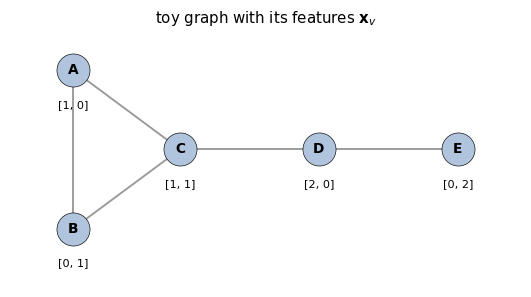

In [7]:
names = ["A", "B", "C", "D", "E"]
edges_toy = [(0, 1), (0, 2), (1, 2), (2, 3), (3, 4)]          # A-B, A-C, B-C, C-D, D-E
G_toy = nx.Graph(edges_toy)
A_toy = nx.to_numpy_array(G_toy, nodelist=range(5))
X_toy = np.array([[1, 0], [0, 1], [1, 1], [2, 0], [0, 2]], dtype=float)
pos_toy = {0: (-1, 0.8), 1: (-1, -0.8), 2: (0, 0), 3: (1.3, 0), 4: (2.6, 0)}

def draw_toy(ax, H, title):
    """The toy graph with each node's vector written under it."""
    draw_graph(ax, G_toy, pos_toy, node_color="lightsteelblue", labels=False, node_size=700, edge_width=1.5)
    nx.draw_networkx_labels(G_toy, pos_toy, labels=dict(enumerate(names)), ax=ax, font_size=11, font_weight="bold")
    for v, (px, py) in pos_toy.items():
        ax.text(px, py - 0.3, "[" + ", ".join(f"{h:.3g}" for h in H[v]) + "]", ha="center", va="top", fontsize=9)
    ax.set_title(title); ax.set_xlim(-1.6, 3.2); ax.set_ylim(-1.4, 1.2)

print("A =\n", A_toy.astype(int))
print("degrees:", dict(zip(names, A_toy.sum(1).astype(int))), "  (expected A 2, B 2, C 3, D 2, E 1)")
print("X =\n", X_toy)
fig, ax = plt.subplots(figsize=(6, 3.4))
draw_toy(ax, X_toy, r"toy graph with its features $\mathbf{x}_v$")
plt.tight_layout(); plt.show()

**Step 1: sum the neighbours.** $\mathbf{h}_v = \sum_{u \in \mathcal{N}(v)} \mathbf{x}_u$. Row $v$ of $\mathbf{A}\mathbf{X}$ is $\sum_u A_{vu}\mathbf{x}_u$, which is exactly this sum, so for all nodes at once

$$
\mathbf{H} = \mathbf{A}\mathbf{X}.
$$

In [8]:
AX = A_toy @ X_toy
print("A X =\n", AX)
print("row C by hand: x_A + x_B + x_D = [1,0] + [0,1] + [2,0] = [3, 1]")
assert np.array_equal(AX, [[1, 2], [2, 1], [3, 1], [1, 3], [2, 0]])

A X =
 [[1. 2.]
 [2. 1.]
 [3. 1.]
 [1. 3.]
 [2. 0.]]
row C by hand: x_A + x_B + x_D = [1,0] + [0,1] + [2,0] = [3, 1]


**Problem 1: a node forgets itself.** Row C is $[3, 1]$ whatever C's own features are: changing $\mathbf{x}_C$ would not change $\mathbf{h}_C$. The fix is to give every node a **self-loop**, $\tilde{\mathbf{A}} = \mathbf{A} + \mathbf{I}$, so that $\tilde{\mathbf{A}}\mathbf{X} = \mathbf{A}\mathbf{X} + \mathbf{X}$ includes $\mathbf{x}_v$ in its own sum.

In [9]:
A_tilde_toy = A_toy + np.eye(5)
AtX = A_tilde_toy @ X_toy
print("Ã X = A X + X =\n", AtX)
assert np.array_equal(AtX, [[2, 2], [2, 2], [4, 2], [3, 3], [2, 2]])

Ã X = A X + X =
 [[2. 2.]
 [2. 2.]
 [4. 2.]
 [3. 3.]
 [2. 2.]]


**Problem 2: sums grow with the degree.** C adds up 4 vectors and E only 2, so C's vector is larger only because C has more neighbours. Stacking layers makes it much worse. With all inputs equal to 1, $(\tilde{\mathbf{A}}^k\mathbf{1})_v$ is the number of walks of length $k$ that start at $v$ (self-loops allowed), and that number grows roughly like the $k$-th power of the degrees around $v$. On the karate club we compare the hub (node 33, degree 17) with a leaf (node 11, degree 1) under three aggregations: the plain sum $\tilde{\mathbf{A}}$, the **mean** $\tilde{\mathbf{D}}^{-1}\tilde{\mathbf{A}}$ and the **symmetric normalisation** $\hat{\mathbf{A}} = \tilde{\mathbf{D}}^{-1/2}\tilde{\mathbf{A}}\tilde{\mathbf{D}}^{-1/2}$ used by GCN.

      sum: after 4 layers  hub =   6492.00   leaf =  979.00   ratio =   6.63
     mean: after 4 layers  hub =      1.00   leaf =    1.00   ratio =   1.00
symmetric: after 4 layers  hub =      1.68   leaf =    0.60   ratio =   2.82


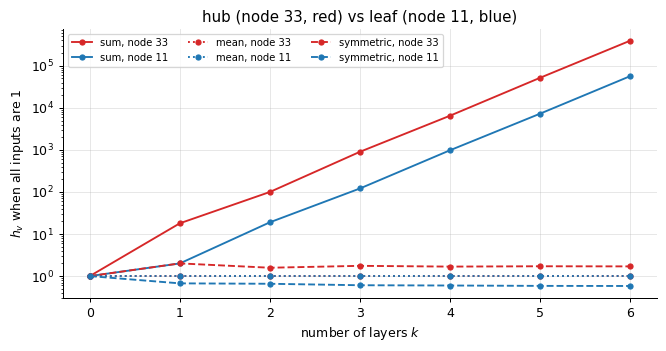

In [10]:
A_tilde_k = A_k + np.eye(n_k)
ops = {"sum": A_tilde_k, "mean": A_tilde_k / A_tilde_k.sum(1, keepdims=True), "symmetric": normalize_adj(A_k)}
ks = np.arange(7)
fig, ax = plt.subplots(figsize=(7.5, 4))
for (label, M), ls in zip(ops.items(), ["-", ":", "--"]):
    vals = np.array([np.linalg.matrix_power(M, k) @ np.ones(n_k) for k in ks])      # (k, n)
    for node, color in [(33, "tab:red"), (11, "tab:blue")]:
        ax.plot(ks, vals[:, node], ls, marker="o", ms=4, color=color, label=f"{label}, node {node}")
    print(f"{label:>9}: after 4 layers  hub = {vals[4, 33]:9.2f}   leaf = {vals[4, 11]:7.2f}   ratio = {vals[4, 33] / vals[4, 11]:6.2f}")
ax.set_yscale("log"); ax.set_xlabel("number of layers $k$"); ax.set_ylabel("$h_v$ when all inputs are 1")
ax.set_title("hub (node 33, red) vs leaf (node 11, blue)"); ax.legend(fontsize=8, ncol=3)
plt.tight_layout(); plt.show()

With plain sums the values explode: the hub goes from 1 to 6492 after 4 layers, almost a factor of 9 per layer, and stays about 7 times larger than the leaf (979; the leaf's only friend is node 0, the other hub). One weight matrix cannot handle inputs whose scale grows by an order of magnitude per layer and differs by a factor of 7 between nodes, and the gradients blow up with them. Both normalisations keep every node on the same scale: the mean gives exactly 1 to everyone (an average of ones), and the symmetric version settles at 1.68 for the hub and 0.60 for the leaf. That is a profile proportional to $\sqrt{\tilde d_v}$, explained in section 4: $\sqrt{18/2} = 3$, close to the ratio 2.8.

**Fix: normalise by the degree.** Two standard choices, with $\tilde d_v = d_v + 1$:

$$
\text{mean:}\quad \mathbf{h}_v = \frac{1}{\tilde d_v}\sum_{u \in \mathcal{N}(v)\cup\{v\}} \mathbf{x}_u
\qquad\Longleftrightarrow\qquad \mathbf{H} = \tilde{\mathbf{D}}^{-1}\tilde{\mathbf{A}}\mathbf{X},
$$

$$
\text{symmetric:}\quad \mathbf{h}_v = \sum_{u \in \mathcal{N}(v)\cup\{v\}} \frac{\mathbf{x}_u}{\sqrt{\tilde d_u\,\tilde d_v}}
\qquad\Longleftrightarrow\qquad \mathbf{H} = \tilde{\mathbf{D}}^{-1/2}\tilde{\mathbf{A}}\tilde{\mathbf{D}}^{-1/2}\mathbf{X} = \hat{\mathbf{A}}\mathbf{X}.
$$

The matrix version is the per-node formula for all nodes at once: entry $(v, u)$ of $\hat{\mathbf{A}}$ is $\tilde A_{vu}/\sqrt{\tilde d_v \tilde d_u}$. GCN uses the symmetric version for two reasons. It also divides each message by the **sender's** degree, so a hub, which says little about each of its many neighbours, speaks quietly to each of them. And $\hat{\mathbf{A}}$ is a symmetric matrix, with real eigenvalues between $-1$ and $1$: this is what section 4 uses to explain what the layer does.

d̃ = [3. 3. 4. 3. 2.]   (expected 3, 3, 4, 3, 2)
mean aggregation D̃^{-1} Ã X =
 [[0.667 0.667]
 [0.667 0.667]
 [1.    0.5  ]
 [1.    1.   ]
 [1.    1.   ]]
symmetric normalisation Â X =
 [[0.622 0.622]
 [0.622 0.622]
 [1.116 0.539]
 [0.955 1.105]
 [0.816 1.   ]]
node C, per-node formula: [1.116 0.539]    row C of Â X: [1.116 0.539]
by hand: [3/√12 + 1/4, 1/√12 + 1/4] = [1.116 0.539]
row sums of the mean operator: [1. 1. 1. 1. 1.]   row sums of Â: [0.955 0.955 1.116 1.03  0.908]


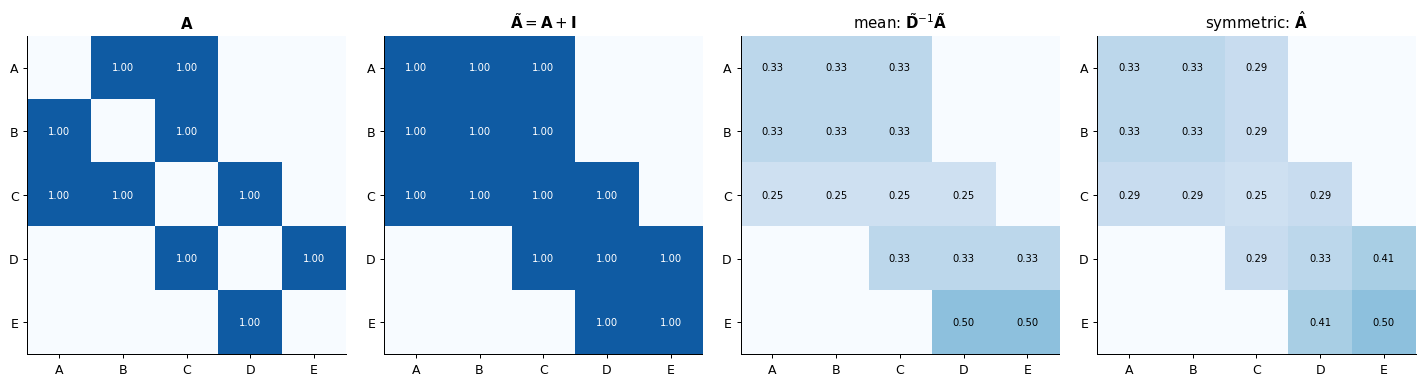

In [11]:
d_tilde = A_tilde_toy.sum(1)                                  # d̃_v = d_v + 1
mean_op = A_tilde_toy / d_tilde[:, None]                      # D̃^{-1} Ã
A_hat_toy = normalize_adj(A_toy)                              # D̃^{-1/2} Ã D̃^{-1/2}
print("d̃ =", d_tilde, "  (expected 3, 3, 4, 3, 2)")
print("mean aggregation D̃^{-1} Ã X =\n", mean_op @ X_toy)
print("symmetric normalisation Â X =\n", A_hat_toy @ X_toy)

c = 2                                                         # node C: N(C) ∪ {C} = {A, B, C, D}
h_C = sum(X_toy[u] / np.sqrt(d_tilde[u] * d_tilde[c]) for u in [0, 1, 2, 3])
print("node C, per-node formula:", h_C, "   row C of Â X:", (A_hat_toy @ X_toy)[c])
print("by hand: [3/√12 + 1/4, 1/√12 + 1/4] =", np.array([3 / np.sqrt(12) + 0.25, 1 / np.sqrt(12) + 0.25]))
assert np.allclose(h_C, (A_hat_toy @ X_toy)[c])
assert np.allclose(mean_op @ X_toy, [[2/3, 2/3], [2/3, 2/3], [1, 0.5], [1, 1], [1, 1]])
print("row sums of the mean operator:", mean_op.sum(1), "  row sums of Â:", A_hat_toy.sum(1))

mats = {r"$\mathbf{A}$": A_toy, r"$\tilde{\mathbf{A}} = \mathbf{A} + \mathbf{I}$": A_tilde_toy,
        r"mean: $\tilde{\mathbf{D}}^{-1}\tilde{\mathbf{A}}$": mean_op, r"symmetric: $\hat{\mathbf{A}}$": A_hat_toy}
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (title, M) in zip(axes, mats.items()):
    ax.imshow(M, cmap="Blues", vmin=0, vmax=1.2)
    for i in range(5):
        for j in range(5):
            if M[i, j]:
                ax.text(j, i, f"{M[i, j]:.2f}", ha="center", va="center", fontsize=8, color="white" if M[i, j] > 0.7 else "black")
    ax.set_xticks(range(5)); ax.set_xticklabels(names); ax.set_yticks(range(5)); ax.set_yticklabels(names)
    ax.grid(False); ax.set_title(title)
plt.tight_layout(); plt.show()

**Reading the matrices.** Row $v$ of each operator lists the weights that node $v$ gives to the nodes it listens to. The mean operator has rows that sum to 1, a plain average. In $\hat{\mathbf{A}}$, row C gives $1/\sqrt{3 \cdot 4} = 0.29$ to A, B and D and $1/4 = 0.25$ to itself; row E gives $1/2$ to itself but only $1/\sqrt{6} = 0.41$ to D, because D has more neighbours than E. The rows of $\hat{\mathbf{A}}$ do not sum exactly to 1 (between 0.91 and 1.12 here), but they stay close to it.

**A full GCN layer.** Now add the learned part, a weight matrix $\mathbf{W}$ that maps the 2 input features to 2 output features, and a ReLU:

$$
\mathbf{H}^{(1)} = \text{ReLU}\big(\hat{\mathbf{A}}\,\mathbf{X}\,\mathbf{W}\big), \qquad
\mathbf{W} = \begin{pmatrix} 1 & -1 \\ 0.5 & 1 \end{pmatrix}.
$$

Per node: $\mathbf{h}_v' = \sigma\big(\sum_{u \in \mathcal{N}(v)\cup\{v\}} \mathbf{W}^\top\mathbf{h}_u / \sqrt{\tilde d_u \tilde d_v}\big)$. $\hat{\mathbf{A}}$ mixes **rows** (nodes), $\mathbf{W}$ mixes **columns** (features), and the order does not matter: $(\hat{\mathbf{A}}\mathbf{X})\mathbf{W} = \hat{\mathbf{A}}(\mathbf{X}\mathbf{W})$. The first output feature is $x_1 + 0.5\,x_2$ and the second is $x_2 - x_1$, both computed on the aggregated vectors.

Â X W =
 [[ 0.933  0.   ]
 [ 0.933  0.   ]
 [ 1.385 -0.577]
 [ 1.508  0.15 ]
 [ 1.316  0.184]]
H^(1) = ReLU(Â X W) =
 [[0.933 0.   ]
 [0.933 0.   ]
 [1.385 0.   ]
 [1.508 0.15 ]
 [1.316 0.184]]


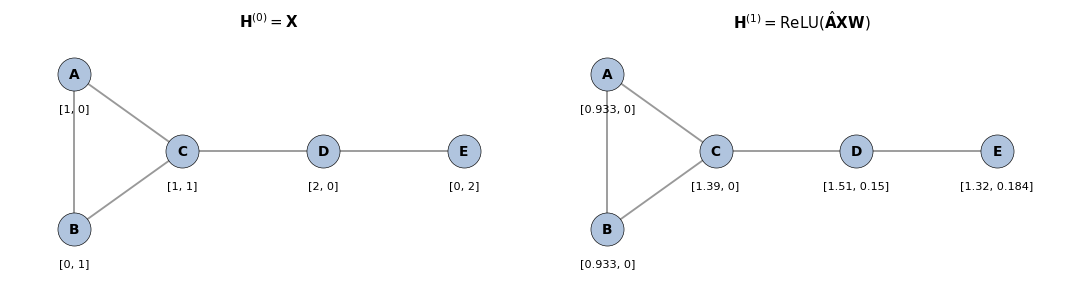

In [12]:
W_toy = np.array([[1, -1], [0.5, 1]])
Z_toy = A_hat_toy @ X_toy @ W_toy
H1_toy = np.maximum(0, Z_toy)
print("Â X W =\n", Z_toy)
print("H^(1) = ReLU(Â X W) =\n", H1_toy)

fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
draw_toy(axes[0], X_toy, r"$\mathbf{H}^{(0)} = \mathbf{X}$")
draw_toy(axes[1], H1_toy, r"$\mathbf{H}^{(1)} = \mathrm{ReLU}(\hat{\mathbf{A}}\mathbf{X}\mathbf{W})$")
plt.tight_layout(); plt.show()

**What just happened?**
- A and B started with different features, $[1, 0]$ and $[0, 1]$, and end with the **same** vector $[0.933, 0]$. They have the same neighbourhood including themselves ($\{A, B, C\}$, with the same degrees), so after one layer the GCN cannot tell them apart. The layer is a **smoothing** operation: it pulls connected nodes towards each other. Section 4 makes this precise.
- C's second feature was $-0.577$ before the ReLU and is cut to 0. D and E keep a small positive second feature (0.150 and 0.184) because their neighbourhoods contain E's feature $[0, 2]$.
- E has only one neighbour, so its output is dominated by its own features ($1/2$ of $\mathbf{x}_E$ against $1/\sqrt 6 \approx 0.41$ of $\mathbf{x}_D$). C has three neighbours and keeps only $1/4$ of itself.

## 4. The Laplacian, smoothness and why GCN is a low-pass filter

Section 3 looked at one node at a time. Now look at a whole **graph signal**: a vector $\mathbf{x} \in \mathbb{R}^n$ with one number per node (one column of $\mathbf{X}$). The key object is the **Laplacian**

$$
\mathbf{L} = \mathbf{D} - \mathbf{A}.
$$

**Claim.** For every $\mathbf{x} \in \mathbb{R}^n$,
$$
\mathbf{x}^\top\mathbf{L}\,\mathbf{x} = \sum_{(u,v) \in E} (x_u - x_v)^2 ,
$$
with each undirected edge counted once.

*Proof.* $\mathbf{x}^\top\mathbf{L}\mathbf{x} = \mathbf{x}^\top\mathbf{D}\mathbf{x} - \mathbf{x}^\top\mathbf{A}\mathbf{x} = \sum_v d_v x_v^2 - \sum_{u,v} A_{uv}x_u x_v$. An edge $(u, v)$ adds 1 to $d_u$ and 1 to $d_v$, so it contributes $x_u^2 + x_v^2$ to the first sum. It appears twice in $\mathbf{A}$ ($A_{uv}$ and $A_{vu}$), so it contributes $2x_ux_v$ to the second. Hence $\mathbf{x}^\top\mathbf{L}\mathbf{x} = \sum_{(u,v)\in E}(x_u^2 + x_v^2 - 2x_ux_v) = \sum_{(u,v)\in E}(x_u - x_v)^2$. $\blacksquare$

This quantity is the **Dirichlet energy** of the signal. It is small when neighbours have similar values (a **smooth** signal) and large when values jump across edges. Three consequences:
- $\mathbf{L}$ is positive semidefinite, since a sum of squares is $\ge 0$.
- $\mathbf{L}\mathbf{1} = \mathbf{0}$: the constant signal has zero energy, so 0 is an eigenvalue with eigenvector $\mathbf{1}$ (one such eigenvector per connected component).
- Write $\mathbf{L} = \sum_i \lambda_i \mathbf{u}_i\mathbf{u}_i^\top$ with $0 = \lambda_1 \le \lambda_2 \le \dots \le \lambda_n$ and orthonormal $\mathbf{u}_i$. Then $\mathbf{u}_i^\top\mathbf{L}\mathbf{u}_i = \lambda_i$: **each eigenvalue is the energy of its eigenvector**. Eigenvectors with small $\lambda$ vary slowly over the graph, those with large $\lambda$ oscillate. They are the graph's Fourier modes, from low to high **frequency**, and $\mathbf{x} = \sum_i (\mathbf{u}_i^\top\mathbf{x})\,\mathbf{u}_i$ is the **graph Fourier transform** of $\mathbf{x}$.

In [13]:
L_toy = np.diag(A_toy.sum(1)) - A_toy
x = X_toy[:, 0]                                           # first feature: A 1, B 0, C 1, D 2, E 0
print("L =\n", L_toy.astype(int))
print("x =", x, "  x^T L x =", x @ L_toy @ x, "  Σ_edges (x_u - x_v)^2 =",
      sum((x[u] - x[v]) ** 2 for u, v in edges_toy), "  (expected 1 + 0 + 1 + 1 + 4 = 7)")
print("L 1 =", L_toy @ np.ones(5), "  eigenvalues of L:", np.linalg.eigvalsh(L_toy))

L_k = D_k - A_k                                           # karate club, random signal
x_rand = rng.normal(size=n_k)
quad, edge_sum = x_rand @ L_k @ x_rand, sum((x_rand[u] - x_rand[v]) ** 2 for u, v in G.edges())
print(f"karate club, random x: x^T L x = {quad:.4f}   Σ_edges = {edge_sum:.4f}")
assert np.isclose(quad, edge_sum)

L =
 [[ 2 -1 -1  0  0]
 [-1  2 -1  0  0]
 [-1 -1  3 -1  0]
 [ 0  0 -1  2 -1]
 [ 0  0  0 -1  1]]
x = [1. 0. 1. 2. 0.]   x^T L x = 7.0   Σ_edges (x_u - x_v)^2 = 7.0   (expected 1 + 0 + 1 + 1 + 4 = 7)
L 1 = [0. 0. 0. 0. 0.]   eigenvalues of L: [0.    0.519 2.311 3.    4.17 ]
karate club, random x: x^T L x = 255.6933   Σ_edges = 255.6933


**Fourier modes on a path and on a grid.** For a path of $n$ nodes the eigenvalues are known in closed form, $\lambda_k = 2 - 2\cos(\pi k / n)$ for $k = 0, \dots, n-1$, and the eigenvectors are sampled cosines $\cos\big(\pi k (j + \tfrac12)/n\big)$: the discrete cosine transform. We check this, and then look at a $20 \times 30$ grid graph, the graph of an image.

smallest eigenvalues: [0.    0.006 0.025 0.055]   largest: 3.994   (formula checked)


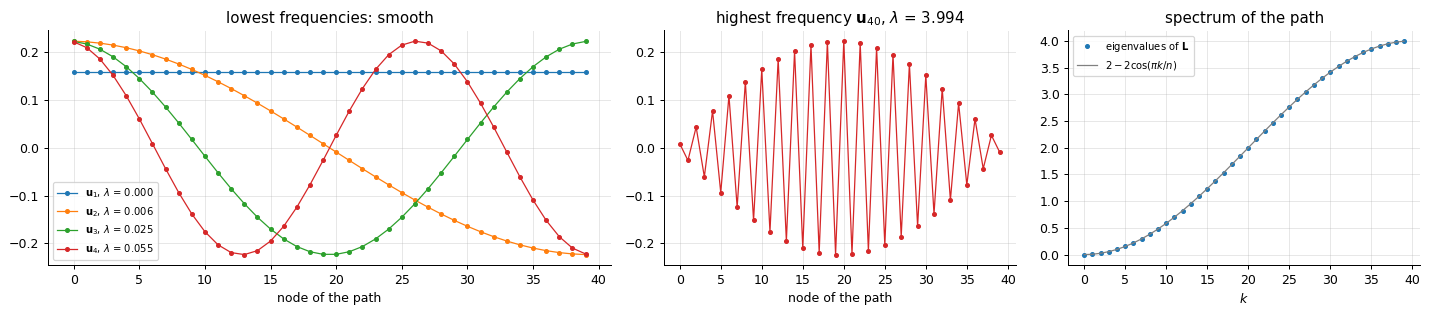

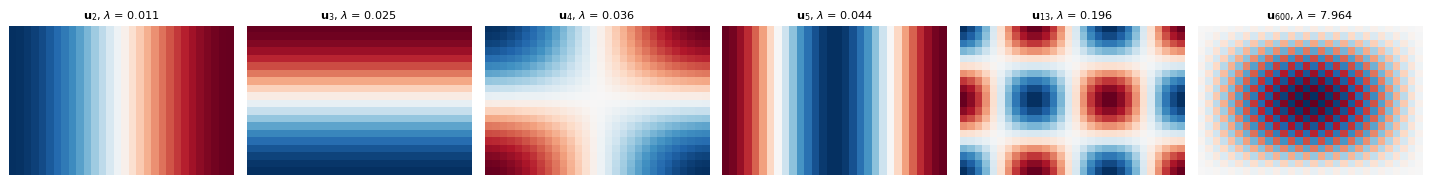

In [14]:
n_path = 40
lam_p, U_p = np.linalg.eigh(nx.laplacian_matrix(nx.path_graph(n_path)).toarray().astype(float))
kk = np.arange(n_path)
assert np.allclose(lam_p, 2 - 2 * np.cos(np.pi * kk / n_path))      # closed form for the path graph
lam_p = np.abs(lam_p)                                               # λ_1 = 0 can come out as -1e-16
print("smallest eigenvalues:", lam_p[:4], "  largest:", lam_p[-1].round(3), "  (formula checked)")

fig, axes = plt.subplots(1, 3, figsize=(16, 3.6), gridspec_kw={"width_ratios": [1.6, 1, 1]})
for i in range(4):
    axes[0].plot(U_p[:, i] * np.sign(U_p[0, i]), "o-", ms=3, lw=1, label=rf"$\mathbf{{u}}_{i + 1}$, $\lambda$ = {lam_p[i]:.3f}")
axes[0].set_title("lowest frequencies: smooth"); axes[0].legend(fontsize=8); axes[0].set_xlabel("node of the path")
axes[1].plot(U_p[:, -1], "o-", ms=3, lw=1, color="tab:red")
axes[1].set_title(rf"highest frequency $\mathbf{{u}}_{{{n_path}}}$, $\lambda$ = {lam_p[-1]:.3f}"); axes[1].set_xlabel("node of the path")
axes[2].plot(kk, lam_p, "o", ms=3, label="eigenvalues of $\\mathbf{L}$")
axes[2].plot(kk, 2 - 2 * np.cos(np.pi * kk / n_path), lw=1, color="gray", label=r"$2 - 2\cos(\pi k / n)$")
axes[2].set_xlabel("$k$"); axes[2].set_title("spectrum of the path"); axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

rows, cols = 20, 30
G_grid = nx.grid_2d_graph(rows, cols)
lam_g, U_g = np.linalg.eigh(nx.laplacian_matrix(G_grid, nodelist=sorted(G_grid)).toarray().astype(float))
show = [1, 2, 3, 4, 12, rows * cols - 1]
fig, axes = plt.subplots(1, len(show), figsize=(16, 2.4))
for ax, i in zip(axes, show):
    lim = np.abs(U_g[:, i]).max()
    ax.imshow(U_g[:, i].reshape(rows, cols), cmap="RdBu_r", vmin=-lim, vmax=lim)
    ax.set_title(rf"$\mathbf{{u}}_{{{i + 1}}}$, $\lambda$ = {lam_g[i]:.3f}", fontsize=9); ax.axis("off")
plt.tight_layout(); plt.show()

The low-frequency eigenvectors are the slow waves of the classical Fourier basis: half a period along the path, then one full period, then one and a half. The highest one alternates sign at every node, so almost every edge pays the maximum price. On the grid the same happens in 2-D: the first modes are smooth gradients and waves across the image, the last one is a checkerboard (under a slow envelope) that flips sign across almost every edge. For a general graph the eigenvectors have no formula, but the interpretation stays: **eigenvalue = how much the mode changes across edges**.

**The Fiedler vector splits the karate club.** The second eigenvector $\mathbf{u}_2$ is the smoothest signal that is not constant:
$$
\lambda_2 = \min_{\mathbf{x} \perp \mathbf{1},\; \lVert\mathbf{x}\rVert = 1}\; \sum_{(u,v)\in E}(x_u - x_v)^2 .
$$
Being orthogonal to $\mathbf{1}$, it must take positive and negative values; being smooth, it changes sign where few edges are cut. So the sign of $\mathbf{u}_2$ is a relaxed solution of the **minimum cut** problem. This is **spectral clustering**, and it needs no labels and no features.

smallest eigenvalues of L: [0.    0.469 0.909 1.125]   (one zero: the graph is connected)
the sign of u_2 agrees with the factions on 32 of 34 nodes; disagreement on node(s) [2, 8] with u_2 = [0.023, 0.052]  (largest |u_2|: 0.423)


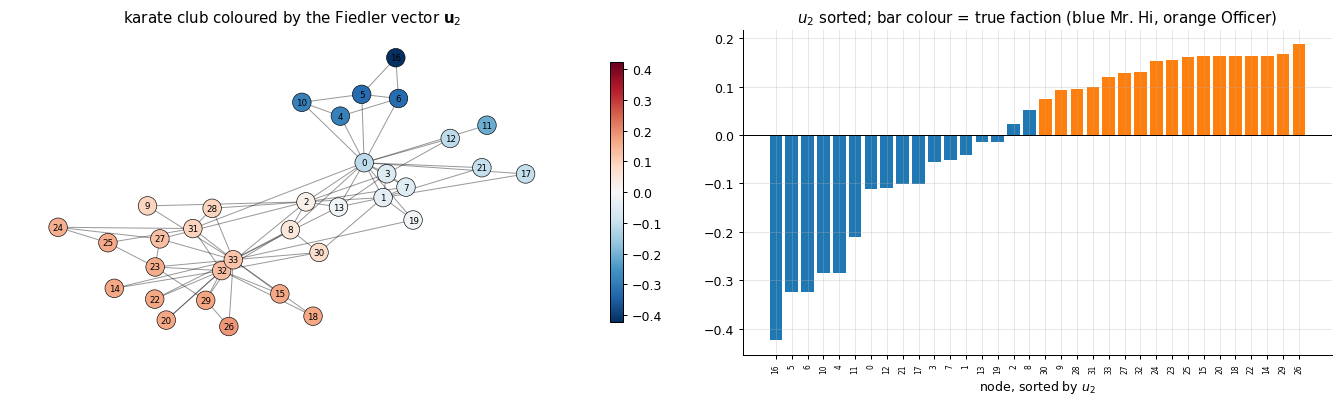

In [15]:
lam_k, U_k = np.linalg.eigh(L_k)
fiedler = U_k[:, 1] * np.sign(U_k[33, 1])                 # orient it so that node 33 (Officer) is positive
split = (fiedler > 0).astype(int)
wrong_f = np.where(split != y_k)[0]
print("smallest eigenvalues of L:", np.abs(lam_k[:4]), "  (one zero: the graph is connected)")
print(f"the sign of u_2 agrees with the factions on {np.sum(split == y_k)} of {n_k} nodes;"
      f" disagreement on node(s) {wrong_f.tolist()} with u_2 = {fiedler[wrong_f].round(3).tolist()}"
      f"  (largest |u_2|: {np.abs(fiedler).max():.3f})")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6), gridspec_kw={"width_ratios": [1.2, 1]})
lim = np.abs(fiedler).max()
nodes = draw_graph(axes[0], G, pos_k, node_color=fiedler, cmap="RdBu_r", vmin=-lim, vmax=lim,
                   title=r"karate club coloured by the Fiedler vector $\mathbf{u}_2$")
fig.colorbar(nodes, ax=axes[0], shrink=0.8)
order = np.argsort(fiedler)
axes[1].bar(range(n_k), fiedler[order], color=FACTION[y_k[order]])
axes[1].set_xticks(range(n_k)); axes[1].set_xticklabels(order, fontsize=6, rotation=90)
axes[1].axhline(0, color="k", lw=0.8); axes[1].set_xlabel("node, sorted by $u_2$")
axes[1].set_title("$u_2$ sorted; bar colour = true faction (blue Mr. Hi, orange Officer)")
plt.tight_layout(); plt.show()

The sign of the Fiedler vector recovers the real split of the club for 32 of the 34 members. The two exceptions, nodes 2 and 8, have values close to zero (0.023 and 0.052, against up to 0.423 elsewhere): they sit on the boundary between the two groups. Node 8, for example, joined Mr. Hi, but 3 of its 5 friends joined the Officer. The communities are written in the low frequencies of the graph. A GCN exploits exactly this, as we now show.

**From the Laplacian to GCN.** The self-loops cancel in the Laplacian: $\tilde{\mathbf{D}} - \tilde{\mathbf{A}} = (\mathbf{D} + \mathbf{I}) - (\mathbf{A} + \mathbf{I}) = \mathbf{L}$. Therefore

$$
\mathbf{I} - \hat{\mathbf{A}} = \tilde{\mathbf{D}}^{-1/2}(\tilde{\mathbf{D}} - \tilde{\mathbf{A}})\tilde{\mathbf{D}}^{-1/2} = \tilde{\mathbf{D}}^{-1/2}\,\mathbf{L}\,\tilde{\mathbf{D}}^{-1/2} =: \hat{\mathbf{L}},
\qquad \hat{\mathbf{A}} = \mathbf{I} - \hat{\mathbf{L}} .
$$

$\hat{\mathbf{L}}$ is a normalised Laplacian, and $\hat{\mathbf{A}}$ has the same eigenvectors with eigenvalues $\mu_i = 1 - \lambda_i(\hat{\mathbf{L}})$.

**Claim.** The eigenvalues of $\hat{\mathbf{A}}$ lie in $(-1, 1]$.

*Proof.* Take $\mathbf{x} \ne \mathbf{0}$ and set $\mathbf{z} = \tilde{\mathbf{D}}^{-1/2}\mathbf{x}$ (also $\ne \mathbf{0}$).
- Upper bound: $\mathbf{x}^\top(\mathbf{I} - \hat{\mathbf{A}})\mathbf{x} = \mathbf{z}^\top\mathbf{L}\mathbf{z} = \sum_{E}(z_u - z_v)^2 \ge 0$, so every eigenvalue is $\le 1$. Equality holds for $\mathbf{z}$ constant, i.e. $x_v \propto \sqrt{\tilde d_v}$.
- Lower bound: $\mathbf{x}^\top(\mathbf{I} + \hat{\mathbf{A}})\mathbf{x} = \mathbf{z}^\top(\tilde{\mathbf{D}} + \tilde{\mathbf{A}})\mathbf{z} = \sum_v (d_v + 2) z_v^2 + 2\sum_E z_u z_v = \sum_E (z_u + z_v)^2 + 2\sum_v z_v^2 > 0$, so every eigenvalue is $> -1$. $\blacksquare$

Without self-loops the lower bound would only be $\ge -1$, reached on bipartite graphs, where repeated propagation oscillates. The self-loops are part of what keeps a deep stack of GCN layers stable.

**GCN is a low-pass filter.** Expand $\hat{\mathbf{A}} = \sum_i \mu_i \mathbf{v}_i\mathbf{v}_i^\top$. Then
$$
\hat{\mathbf{A}}^k\mathbf{x} = \sum_i \mu_i^k\,(\mathbf{v}_i^\top\mathbf{x})\,\mathbf{v}_i .
$$
Each frequency component is multiplied by $\mu_i^k = (1 - \lambda_i)^k$. Components with $\lambda_i$ near 0 (smooth) survive; components with larger $\lambda_i$ (rough) shrink geometrically. A GCN layer is a fixed low-pass filter on the graph followed by a learned map $\mathbf{W}$ on the features.

eigenvalues of Â on the karate club: min -0.420, max 1.000000   (expected in (-1, 1], max exactly 1)
the eigenvector of eigenvalue 1 is proportional to sqrt(d̃_v): checked


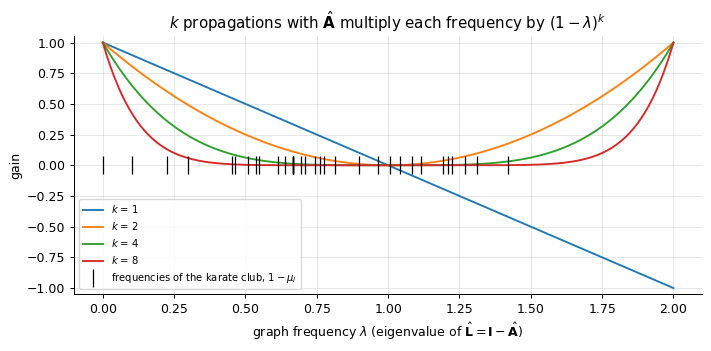

In [16]:
A_hat_k = normalize_adj(A_k)
mu, V = np.linalg.eigh(A_hat_k)                           # ascending eigenvalues
d_tilde_k = deg_k + 1
print(f"eigenvalues of Â on the karate club: min {mu.min():.3f}, max {mu.max():.6f}   (expected in (-1, 1], max exactly 1)")
assert mu.min() > -1 and np.isclose(mu.max(), 1)
v_top = V[:, -1] * np.sign(V[0, -1])
assert np.allclose(v_top, np.sqrt(d_tilde_k) / np.linalg.norm(np.sqrt(d_tilde_k)))
print("the eigenvector of eigenvalue 1 is proportional to sqrt(d̃_v): checked")

freq = np.linspace(0, 2, 300)                              # frequency = eigenvalue of L̂ = 1 - μ
fig, ax = plt.subplots(figsize=(8, 4))
for k in [1, 2, 4, 8]:
    ax.plot(freq, (1 - freq) ** k, label=f"$k$ = {k}")
ax.plot(1 - mu, np.zeros_like(mu), "|", color="k", ms=14, label=r"frequencies of the karate club, $1 - \mu_i$")
ax.set_xlabel(r"graph frequency $\lambda$ (eigenvalue of $\hat{\mathbf{L}} = \mathbf{I} - \hat{\mathbf{A}}$)")
ax.set_ylabel("gain"); ax.set_ylim(-1.05, 1.05); ax.legend(fontsize=8)
ax.set_title(r"$k$ propagations with $\hat{\mathbf{A}}$ multiply each frequency by $(1 - \lambda)^k$")
plt.tight_layout(); plt.show()

**Over-smoothing.** What happens if we keep filtering? Every $\lvert\mu_i\rvert < 1$ goes to zero, so $\hat{\mathbf{A}}^k\mathbf{x}$ converges to its component along the top eigenvector, $\mathbf{x}_\infty \propto \sqrt{\tilde d_v}$: a signal that depends on the degree of each node and on nothing else. To measure how close a signal is to this limit we use the **normalised Dirichlet energy**

$$
E(\mathbf{H}) = \frac{\operatorname{tr}\big(\mathbf{H}^\top(\mathbf{I} - \hat{\mathbf{A}})\mathbf{H}\big)}{\operatorname{tr}(\mathbf{H}^\top\mathbf{H})}
= \frac{\sum_{(u,v)\in E}\big\lVert \mathbf{h}_u/\sqrt{\tilde d_u} - \mathbf{h}_v/\sqrt{\tilde d_v}\big\rVert^2}{\lVert\mathbf{H}\rVert_F^2},
$$

the degree-corrected version of $\mathbf{x}^\top\mathbf{L}\mathbf{x}$ (the second form is the identity of the proof above). It is 0 exactly when the degree-corrected values $h_v/\sqrt{\tilde d_v}$ are equal on every edge. We apply $\hat{\mathbf{A}}^k$ to a random signal on the karate club and colour the nodes by $h_v/\sqrt{\tilde d_v}$, on a fixed colour scale.

k =  0   energy = 7.65e-01   range of h_v / sqrt(d̃_v) over the nodes = 2.0384
k =  1   energy = 3.68e-01   range of h_v / sqrt(d̃_v) over the nodes = 0.8988
k =  2   energy = 1.42e-01   range of h_v / sqrt(d̃_v) over the nodes = 0.4853
k =  4   energy = 2.82e-02   range of h_v / sqrt(d̃_v) over the nodes = 0.1863
k =  8   energy = 7.85e-03   range of h_v / sqrt(d̃_v) over the nodes = 0.0988
k = 16   energy = 1.39e-03   range of h_v / sqrt(d̃_v) over the nodes = 0.0417
k = 32   energy = 4.20e-05   range of h_v / sqrt(d̃_v) over the nodes = 0.0073


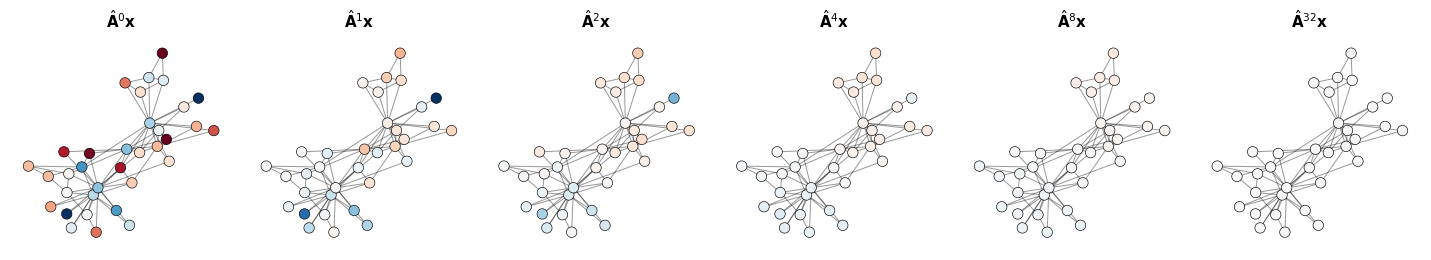

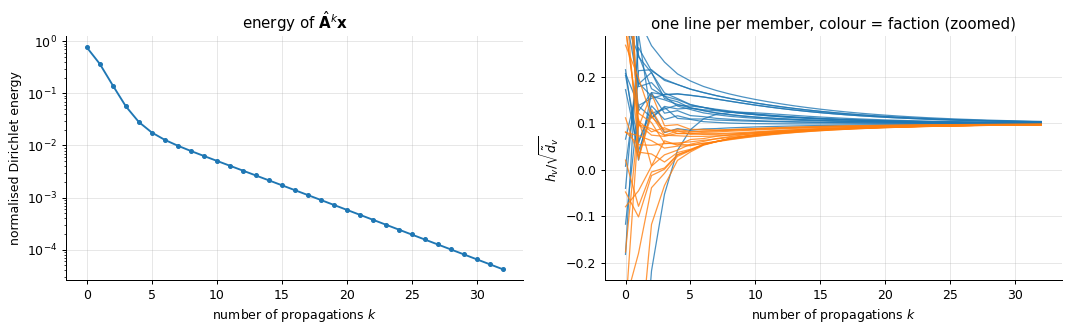

k = 4: mean of h_v / sqrt(d̃_v) over Mr. Hi's faction 0.141, over the Officer's 0.059;  limit value 0.099


In [17]:
def dirichlet_energy(H, A_hat):
    """Normalised Dirichlet energy tr(Hᵀ (I - Â) H) / tr(Hᵀ H): 0 means fully smoothed."""
    return np.trace(H.T @ (H - A_hat @ H)) / np.trace(H.T @ H)

x0 = rng.normal(size=(n_k, 1))                            # a random signal on the karate club
traj = [x0]
for _ in range(32):
    traj.append(A_hat_k @ traj[-1])                       # traj[k] = Â^k x0
traj = np.hstack(traj)                                    # (34, 33)
corrected = traj / np.sqrt(d_tilde_k)[:, None]            # h_v / sqrt(d̃_v)
energy = np.array([dirichlet_energy(traj[:, [k]], A_hat_k) for k in range(33)])
for k in [0, 1, 2, 4, 8, 16, 32]:
    print(f"k = {k:2d}   energy = {energy[k]:.2e}   range of h_v / sqrt(d̃_v) over the nodes = {np.ptp(corrected[:, k]):.4f}")

show_k = [0, 1, 2, 4, 8, 32]
c_inf = corrected[:, -1].mean()                           # the common limit value
lim = np.abs(corrected[:, 1] - c_inf).max()               # colour scale fixed by k = 1 (k = 0 saturates)
fig, axes = plt.subplots(1, len(show_k), figsize=(16, 3))
for ax, k in zip(axes, show_k):
    draw_graph(ax, G, pos_k, node_color=corrected[:, k], cmap="RdBu_r", vmin=c_inf - lim, vmax=c_inf + lim, labels=False,
               node_size=70, title=rf"$\hat{{\mathbf{{A}}}}^{{{k}}}\mathbf{{x}}$")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].semilogy(range(33), energy, "o-", ms=3)
axes[0].set_xlabel("number of propagations $k$"); axes[0].set_ylabel("normalised Dirichlet energy")
axes[0].set_title("energy of $\\hat{\\mathbf{A}}^k\\mathbf{x}$")
for v in range(n_k):
    axes[1].plot(range(33), corrected[v], color=FACTION[y_k[v]], lw=1, alpha=0.8)
axes[1].set_ylim(corrected[:, 2:].min() - 0.02, corrected[:, 2:].max() + 0.02)     # zoom: k = 0, 1 go off the chart
axes[1].set_xlabel("number of propagations $k$"); axes[1].set_ylabel(r"$h_v / \sqrt{\tilde d_v}$")
axes[1].set_title("one line per member, colour = faction (zoomed)")
plt.tight_layout(); plt.show()
print(f"k = 4: mean of h_v / sqrt(d̃_v) over Mr. Hi's faction {corrected[y_k == 0, 4].mean():.3f}, over the Officer's {corrected[y_k == 1, 4].mean():.3f};"
      f"  limit value {c_inf:.3f}")

**Interpretation.**
- The energy falls by more than four orders of magnitude in 32 steps (from 0.77 to $4 \cdot 10^{-5}$), and the node colours fade to one common value, 0.099: after enough propagations every node carries the same (degree-corrected) number, whatever the input was. This is **over-smoothing**. A GCN with many layers applies this filter many times, so its node embeddings lose the information that distinguishes nodes, and a classifier on top cannot separate them. Section 9 measures the effect on real accuracy.
- The trajectories show the useful middle ground. After a few steps the noise is gone but the members still form two bundles, one per faction: at $k = 4$ Mr. Hi's side averages 0.141 and the Officer's side 0.059, on either side of the limit 0.099. The high frequencies are removed and the smooth, community-level component (close to the Fiedler vector) is what remains. Only after 20 to 30 steps do the two bundles merge. A **few** rounds of smoothing denoise features within communities; **many** rounds erase everything. This is why typical GCNs have only 2 or 3 layers.

## 5. A GCN from scratch in PyTorch (dense)

The layer is two lines. We follow the conventions of PyG's `GCNConv`: no bias inside the propagation, the bias is added after it (otherwise it would be multiplied by the row sums of $\hat{\mathbf{A}}$), and Glorot initialisation as in the GCN paper. `nn.Linear` stores its weight transposed, so `self.W(H)` computes $\mathbf{H}\mathbf{W}$ with $\mathbf{W}$ = `self.W.weight.T`.

The karate club has no node features. We give each node a **one-hot identifier**, $\mathbf{X} = \mathbf{I}_{34}$, so that the only information the network has is the graph. The model has three GCN layers $34 \to 4 \to 4 \to 2$ with tanh, so the last layer gives a **2-D embedding** we can plot, and a linear classifier on top.

In [18]:
class GCNLayer(nn.Module):
    """Dense GCN layer: H' = Â H W + b (the activation is applied outside)."""
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W = nn.Linear(d_in, d_out, bias=False)      # self.W(H) = H W
        self.b = nn.Parameter(torch.zeros(d_out))
        nn.init.xavier_uniform_(self.W.weight)           # Glorot initialisation, as in the GCN paper

    def forward(self, H, A_hat):
        return A_hat @ self.W(H) + self.b


class KarateGCN(nn.Module):
    """Three GCN layers 34 -> 4 -> 4 -> 2 with tanh, then a linear classifier on the 2-D embedding."""
    def __init__(self, d_in):
        super().__init__()
        self.convs = nn.ModuleList([GCNLayer(d_in, 4), GCNLayer(4, 4), GCNLayer(4, 2)])
        self.classifier = nn.Linear(2, 2)

    def embed(self, X, A_hat):
        H = X
        for conv in self.convs:
            H = torch.tanh(conv(H, A_hat))
        return H

    def forward(self, X, A_hat):
        return self.classifier(self.embed(X, A_hat))

A_hat_t = torch.tensor(normalize_adj(A_k), dtype=torch.float32)
X_id = torch.eye(n_k)                                     # node v is the one-hot vector e_v
print("parameters:", sum(p.numel() for p in KarateGCN(n_k).parameters()), " (34*4+4 + 4*4+4 + 4*2+2 + 2*2+2 = 176)")

parameters: 176  (34*4+4 + 4*4+4 + 4*2+2 + 2*2+2 = 176)


### 5a. An untrained GCN already separates the factions

Before any training, we push the graph through the network with **random** weights and plot the 2-D output. To put a number on "separated" we fit a logistic regression on the 34 points and report its training accuracy: the fraction of members that a straight line can put on the right side. As a control, we run the same network with $\hat{\mathbf{A}}$ replaced by $\mathbf{I}$, which removes the graph.

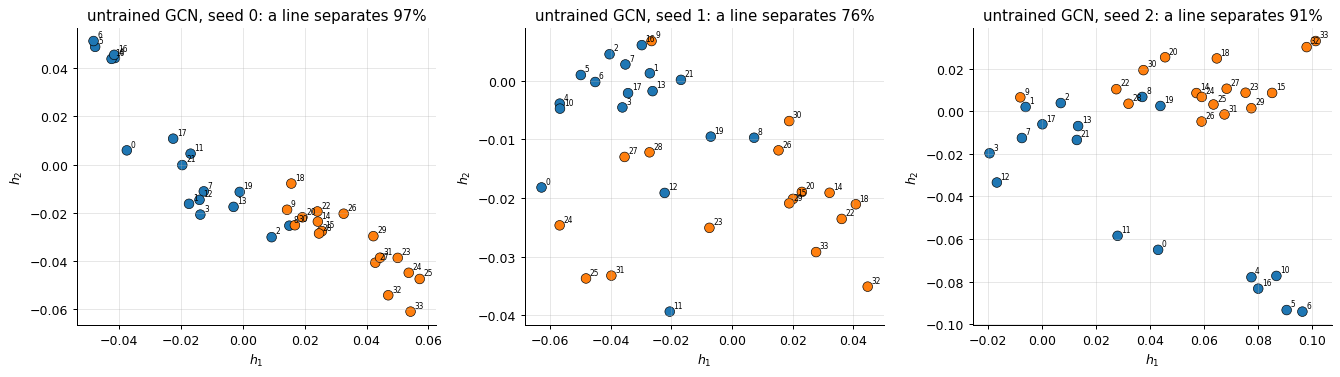

linear separability of the random 2-D embedding, mean over 20 initialisations:
  random GCN (uses the graph)        : 0.874
  same network with Â = I (no graph) : 0.613


In [19]:
from sklearn.linear_model import LogisticRegression

def linear_separability(Z, y):
    """Training accuracy of an almost unregularised logistic regression: can a line split the classes?"""
    return LogisticRegression(C=1e4, max_iter=5000).fit(Z, y).score(Z, y)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, seed in zip(axes, [0, 1, 2]):
    torch.manual_seed(seed)
    with torch.no_grad():
        Z = KarateGCN(n_k).embed(X_id, A_hat_t).numpy()
    ax.scatter(Z[:, 0], Z[:, 1], c=FACTION[y_k], s=60, edgecolors="k", linewidths=0.5)
    for v in range(n_k):
        ax.annotate(v, Z[v], fontsize=6, xytext=(3, 3), textcoords="offset points")
    ax.set_title(f"untrained GCN, seed {seed}: a line separates {linear_separability(Z, y_k):.0%}")
    ax.set_xlabel("$h_1$"); ax.set_ylabel("$h_2$")
plt.tight_layout(); plt.show()

sep_gcn, sep_nograph = [], []
for seed in range(20):
    torch.manual_seed(seed)
    model = KarateGCN(n_k)
    with torch.no_grad():
        sep_gcn.append(linear_separability(model.embed(X_id, A_hat_t).numpy(), y_k))
        sep_nograph.append(linear_separability(model.embed(X_id, torch.eye(n_k)).numpy(), y_k))
print("linear separability of the random 2-D embedding, mean over 20 initialisations:")
print(f"  random GCN (uses the graph)        : {np.mean(sep_gcn):.3f}")
print(f"  same network with Â = I (no graph) : {np.mean(sep_nograph):.3f}")

**Why does a random network work?** With $\mathbf{X} = \mathbf{I}$, the first layer computes $\hat{\mathbf{A}}\mathbf{W}^{(0)}$: row $v$ is a random projection of row $v$ of $\hat{\mathbf{A}}$, which is $v$'s neighbourhood. Members with overlapping circles of friends get similar rows. Three layers apply $\hat{\mathbf{A}}$ three times, so the embedding of $v$ is a random function of its **3-hop** neighbourhood, and within a faction these neighbourhoods overlap a lot. In the language of section 4, $\hat{\mathbf{A}}^3$ removes the high frequencies and keeps the smooth, community-level ones. The random weights only rotate and squash what the filter produced. Without the graph ($\hat{\mathbf{A}} = \mathbf{I}$) the 34 one-hot vectors are mapped to 34 unrelated random points, and a line separates them only 61% of the time on average, against 87% with the graph. Some initialisations are poor (seed 1 above separates only 76%), which is why we average over 20.

### 5b. Semi-supervised training with one label per faction

Now we train, using the labels of **only two members**: node 0 (Mr. Hi) and node 33 (Officer). The loss is the cross-entropy on these 2 nodes, but the forward pass runs on the whole graph, so the gradient reaches the embeddings of every node through $\hat{\mathbf{A}}$. This setting, a few labelled nodes in one big graph, is called **semi-supervised node classification**.

final training loss (2 nodes): 0.0055
accuracy on the 32 unlabelled members: 0.969   misclassified: [8]


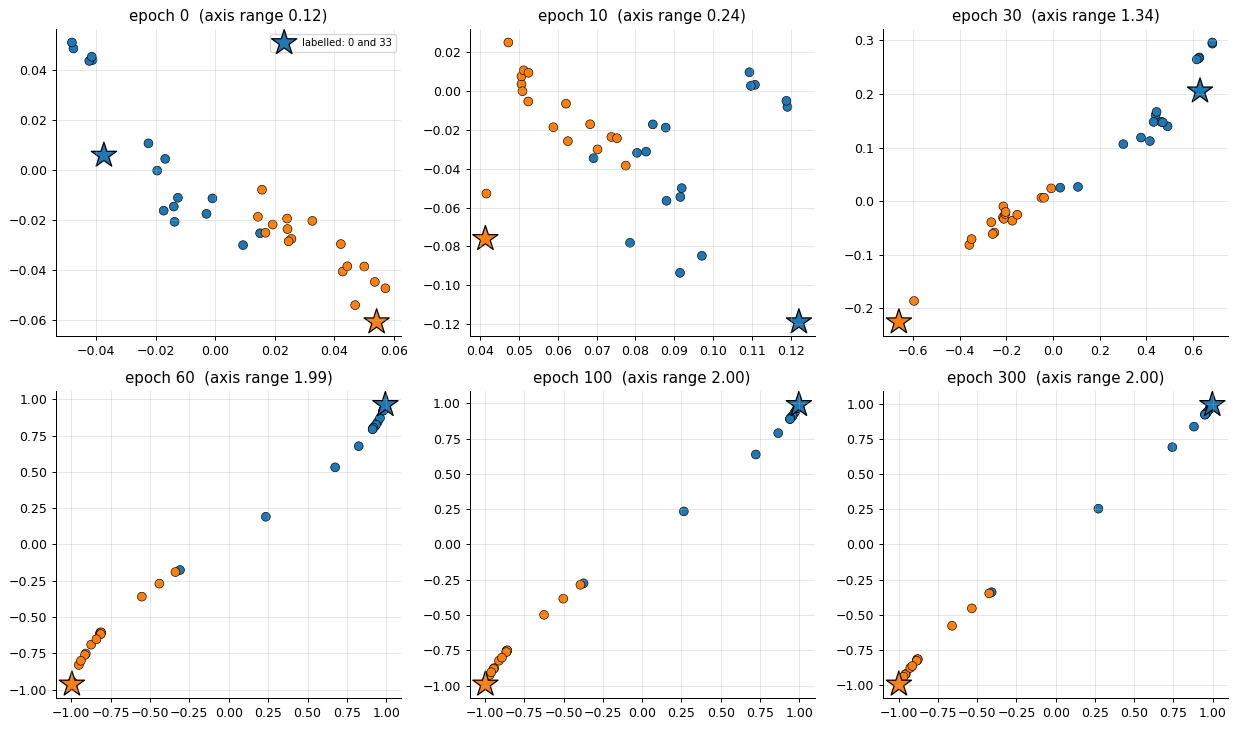

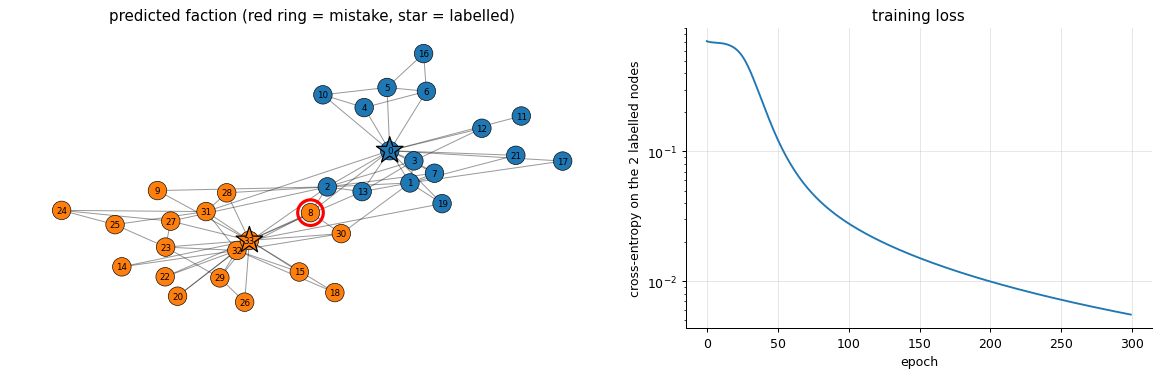

In [20]:
torch.manual_seed(0)
model = KarateGCN(n_k)
opt = torch.optim.Adam(model.parameters(), lr=0.01)
labelled = torch.tensor([0, 33])
y_t = torch.tensor(y_k)
snap_epochs = [0, 10, 30, 60, 100, 300]
snaps, losses = {}, []
with torch.no_grad():
    snaps[0] = model.embed(X_id, A_hat_t).numpy()
for epoch in range(1, 301):
    opt.zero_grad()
    loss = F.cross_entropy(model(X_id, A_hat_t)[labelled], y_t[labelled])      # loss on 2 nodes only
    loss.backward(); opt.step(); losses.append(loss.item())
    if epoch in snap_epochs:
        with torch.no_grad():
            snaps[epoch] = model.embed(X_id, A_hat_t).numpy()

with torch.no_grad():
    pred_k = model(X_id, A_hat_t).argmax(1).numpy()
others = np.setdiff1d(np.arange(n_k), [0, 33])
wrong_k = others[pred_k[others] != y_k[others]]
print(f"final training loss (2 nodes): {losses[-1]:.4f}")
print(f"accuracy on the 32 unlabelled members: {np.mean(pred_k[others] == y_k[others]):.3f}   misclassified: {wrong_k.tolist()}")

fig, axes = plt.subplots(2, 3, figsize=(14, 8.2))
for ax, ep in zip(axes.ravel(), snap_epochs):
    Z = snaps[ep]
    ax.scatter(Z[:, 0], Z[:, 1], c=FACTION[y_k], s=50, edgecolors="k", linewidths=0.5)
    ax.scatter(Z[[0, 33], 0], Z[[0, 33], 1], marker="*", s=450, c=FACTION[y_k[[0, 33]]], edgecolors="k", label="labelled: 0 and 33")
    ax.set_title(f"epoch {ep}  (axis range {np.ptp(Z):.2f})")       # each panel has its own scale
axes[0, 0].legend(loc="best", fontsize=8)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), gridspec_kw={"width_ratios": [1.3, 1]})
draw_graph(axes[0], G, pos_k, node_color=FACTION[pred_k], title="predicted faction (red ring = mistake, star = labelled)")
nx.draw_networkx_nodes(G, pos_k, nodelist=wrong_k.tolist(), ax=axes[0], node_color="none", edgecolors="red", linewidths=2.5, node_size=420)
nx.draw_networkx_nodes(G, pos_k, nodelist=[0, 33], ax=axes[0], node_color=FACTION[[0, 1]], node_shape="*", node_size=500, edgecolors="k")
axes[1].semilogy(losses); axes[1].set_xlabel("epoch"); axes[1].set_ylabel("cross-entropy on the 2 labelled nodes"); axes[1].set_title("training loss")
plt.tight_layout(); plt.show()

**What just happened?** At epoch 0 the embedding is the seed-0 network of section 5a, already organised by faction but tiny (axis range 0.12). Training pulls the two labelled nodes to opposite corners, and their neighbours follow because they share most of their computation: in a GCN the embeddings of connected nodes are tied together. By epoch 60 the tanh outputs reach $\pm 1$. With two labels the model classifies 31 of the 32 other members correctly (96.9%). The one mistake, node 8, is one of the two boundary members that the Fiedler vector also got wrong: 3 of its 5 friends are on the Officer's side, so the graph alone points the wrong way.

The loss is computed on 2 nodes, so it falls to almost zero; it tells us nothing about the other 32 nodes. That is why section 7 uses separate validation and test nodes.

## 6. Sparse message passing with `edge_index`

The dense layer stores $\hat{\mathbf{A}}$ as an $n \times n$ matrix and computes $\hat{\mathbf{A}}\mathbf{H}$ in $O(n^2 d)$ time and $O(n^2)$ memory. For Cora ($n = 2708$) that is 7.3 million entries, fine. For a graph with $10^6$ nodes it is $10^{12}$ entries, 3.6 TB in float32, although only a few million of them are non-zero. We only need the non-zeros:

$$
(\hat{\mathbf{A}}\mathbf{H})_v = \sum_{(u \to v)\, \in\, E\, \cup\, \text{self-loops}} w_{uv}\,\mathbf{h}_u,
\qquad w_{uv} = \frac{1}{\sqrt{\tilde d_u\,\tilde d_v}} .
$$

With `edge_index` = (`src`, `dst`), this is three tensor operations:

1. **gather**: `H[src]` copies the vector of the sender of every edge, a $\lvert E\rvert \times d$ matrix with one message per edge;
2. **weight**: multiply each message by its edge weight $w_{uv}$;
3. **scatter-add**: add every message into the row of its receiver, `out.index_add_(0, dst, messages)`.

Cost $O(\lvert E\rvert d)$ in time and $O(\lvert E\rvert + nd)$ in memory. Convention (as in PyG): row 0 of `edge_index` is the **source** $u$, row 1 the **target** $v$, and messages flow $u \to v$. An undirected edge is stored in both directions, so each endpoint receives the other's message. Self-loops are added as extra edges $(v, v)$, and the degrees $\tilde d_v$ are counted from `dst`.

In [21]:
def gcn_norm_edges(edge_index, n):
    """Add self-loops; return (src, dst, w) with w = 1 / sqrt(d̃_src d̃_dst) for every edge."""
    loops = torch.arange(n, device=edge_index.device)
    src = torch.cat([edge_index[0], loops])
    dst = torch.cat([edge_index[1], loops])
    deg = torch.zeros(n, device=edge_index.device).index_add_(0, dst, torch.ones(dst.numel(), device=dst.device))
    return src, dst, deg[src].rsqrt() * deg[dst].rsqrt()

def propagate(H, src, dst, w):
    """Sparse Â H: out[v] = sum over the edges (u -> v) of w_uv * H[u]."""
    messages = H[src] * w[:, None]                              # gather: one message per edge, (|E|, d)
    return H.new_zeros(H.shape).index_add_(0, dst, messages)    # scatter-add into the target rows

ei_toy = torch.tensor(np.array(np.nonzero(A_toy)), dtype=torch.long)
src_t, dst_t, w_t = gcn_norm_edges(ei_toy, 5)
X_toy_t = torch.tensor(X_toy, dtype=torch.float32)
print("edge_index of the toy graph: 5 undirected edges = 10 columns\n", ei_toy)
print(f"\n #   edge    w = 1/sqrt(d̃_u d̃_v)   message w * x_u")
for i in range(len(src_t)):
    u, v = src_t[i].item(), dst_t[i].item()
    m = (w_t[i] * X_toy_t[u]).tolist()
    print(f"{i:>2}   {names[u]} -> {names[v]}   {w_t[i].item():>14.3f}         [{m[0]:.3f}, {m[1]:.3f}]")
out_toy = propagate(X_toy_t, src_t, dst_t, w_t)
print("\nafter the scatter-add (one row per target node):\n", out_toy.numpy())
assert np.allclose(out_toy.numpy(), normalize_adj(A_toy) @ X_toy, atol=1e-6)
print("equal to the dense Â X of section 3: checked")

edge_index of the toy graph: 5 undirected edges = 10 columns
 tensor([[0, 0, 1, 1, 2, 2, 2, 3, 3, 4],
        [1, 2, 0, 2, 0, 1, 3, 2, 4, 3]])

 #   edge    w = 1/sqrt(d̃_u d̃_v)   message w * x_u
 0   A -> B            0.333         [0.333, 0.000]
 1   A -> C            0.289         [0.289, 0.000]
 2   B -> A            0.333         [0.000, 0.333]
 3   B -> C            0.289         [0.000, 0.289]
 4   C -> A            0.289         [0.289, 0.289]
 5   C -> B            0.289         [0.289, 0.289]
 6   C -> D            0.289         [0.289, 0.289]
 7   D -> C            0.289         [0.577, 0.000]
 8   D -> E            0.408         [0.816, 0.000]
 9   E -> D            0.408         [0.000, 0.816]
10   A -> A            0.333         [0.333, 0.000]
11   B -> B            0.333         [0.000, 0.333]
12   C -> C            0.250         [0.250, 0.250]
13   D -> D            0.333         [0.667, 0.000]
14   E -> E            0.500         [0.000, 1.000]

after the scatter-add 

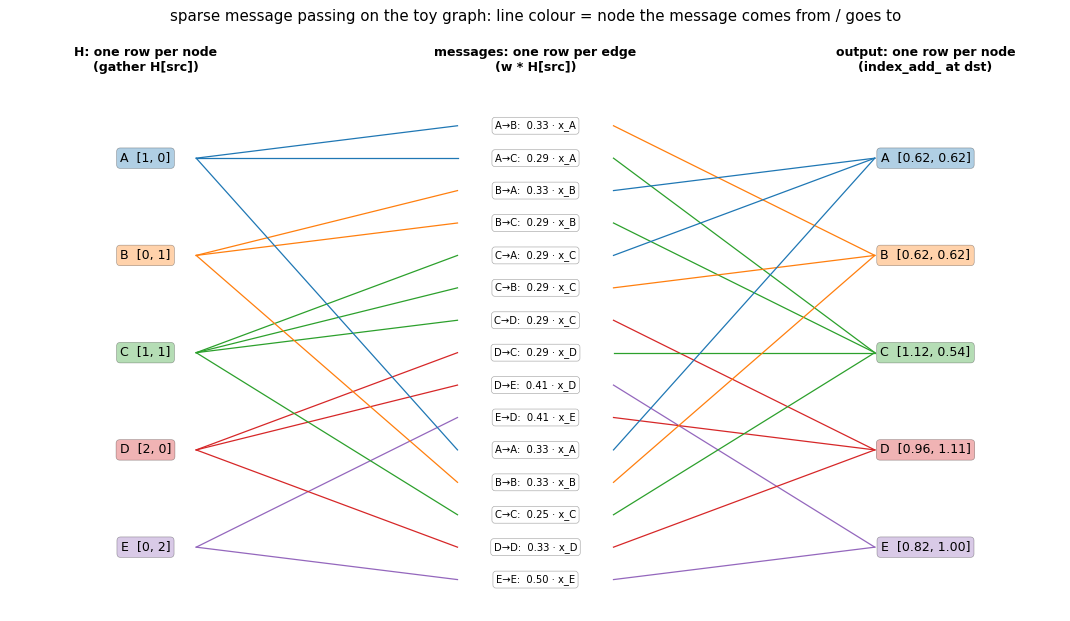

In [22]:
fig, ax = plt.subplots(figsize=(12, 7))
n_e = len(src_t)
cmap10 = plt.get_cmap("tab10")
y_node = np.linspace(n_e - 2, 1, 5)                      # vertical positions of the 5 nodes
y_edge = np.arange(n_e - 1, -1, -1, dtype=float)         # and of the 15 messages
box = lambda c: dict(boxstyle="round,pad=0.3", fc=c, alpha=0.35, ec="k", lw=0.5)
for i in range(n_e):
    u, v = src_t[i].item(), dst_t[i].item()
    ax.plot([0.13, 0.80], [y_node[u], y_edge[i]], color=cmap10(u), lw=1)      # gather from the source
    ax.plot([1.20, 1.87], [y_edge[i], y_node[v]], color=cmap10(v), lw=1)      # scatter into the target
    ax.text(1, y_edge[i], f"{names[u]}→{names[v]}:  {w_t[i]:.2f} · x_{names[u]}", ha="center", va="center", fontsize=8, bbox=box("white"))
for v in range(5):
    ax.text(0, y_node[v], f"{names[v]}  {X_toy[v].astype(int).tolist()}", ha="center", va="center", fontsize=10, bbox=box(cmap10(v)))
    ax.text(2, y_node[v], f"{names[v]}  [{out_toy[v, 0]:.2f}, {out_toy[v, 1]:.2f}]", ha="center", va="center", fontsize=10, bbox=box(cmap10(v)))
for xx, t in [(0, "H: one row per node\n(gather H[src])"), (1, "messages: one row per edge\n(w * H[src])"), (2, "output: one row per node\n(index_add_ at dst)")]:
    ax.text(xx, n_e + 0.6, t, ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xlim(-0.35, 2.35); ax.set_ylim(-1, n_e + 2); ax.axis("off")
ax.set_title("sparse message passing on the toy graph: line colour = node the message comes from / goes to")
plt.tight_layout(); plt.show()

Every node receives exactly $\tilde d_v$ messages: C receives 4 (from A, B, D and itself), E receives 2. Now the same layer as a module. Its parameters have the same names as `GCNLayer`, so we can copy the weights of a dense layer into it and check that both compute the same thing.

In [23]:
class SparseGCNLayer(nn.Module):
    """GCN layer with edge-list message passing: same maths as GCNLayer, cost O(|E| d)."""
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W = nn.Linear(d_in, d_out, bias=False)
        self.b = nn.Parameter(torch.zeros(d_out))
        nn.init.xavier_uniform_(self.W.weight)

    def forward(self, H, src, dst, w):
        return propagate(self.W(H), src, dst, w) + self.b

torch.manual_seed(0)
dense_layer, sparse_layer = GCNLayer(n_k, 8), SparseGCNLayer(n_k, 8)
sparse_layer.load_state_dict(dense_layer.state_dict())          # same parameter names, same values
H_in = torch.randn(n_k, n_k)
out_dense = dense_layer(H_in, A_hat_t)
out_sparse = sparse_layer(H_in, *gcn_norm_edges(edge_index_k, n_k))
print(f"karate club: max |dense - sparse| = {(out_dense - out_sparse).abs().max():.1e}   (float32 rounding)")
assert torch.allclose(out_dense, out_sparse, atol=1e-5)

karate club: max |dense - sparse| = 2.4e-07   (float32 rounding)


**Timing.** We compare one propagation $\hat{\mathbf{A}}\mathbf{H}$, dense matrix product against gather/scatter, on random graphs with average degree 10 and $d = 64$ features.

     n  directed edges  dense (ms)  sparse (ms)  dense Â (MB)  edge list (MB)
   500            4938        0.14         0.11           1.0            0.10
  1000            9942        0.55         0.16           3.8            0.21


  2000           19942        2.27         0.27          15.3            0.42


  4000           39946       11.31         2.23          61.0            0.84
a graph with 10^6 nodes and mean degree 10: dense Â needs 3.6 TB, the edge list 210 MB


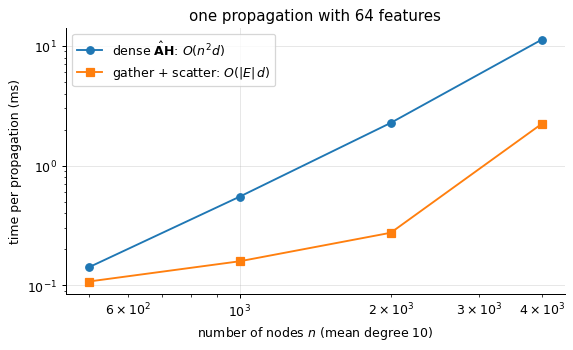

In [24]:
def time_ms(f, reps=20):
    """Best wall time of f() over several runs, in milliseconds (the minimum is the least noisy estimate)."""
    times = []
    for _ in range(reps):
        t0 = time.perf_counter(); f(); times.append(time.perf_counter() - t0)
    return 1000 * np.min(times)

sizes, t_dense, t_sparse = [500, 1000, 2000, 4000], [], []
g = torch.Generator().manual_seed(0)
print(f"{'n':>6}{'directed edges':>16}{'dense (ms)':>12}{'sparse (ms)':>13}{'dense Â (MB)':>14}{'edge list (MB)':>16}")
for n in sizes:
    e = torch.randint(0, n, (2, 5 * n), generator=g)                      # 5n random pairs -> mean degree about 10
    e = e[:, e[0] != e[1]]
    e = torch.unique(torch.cat([e, e.flip(0)], 1), dim=1)                # both directions, no duplicates
    A_dense = torch.zeros(n, n); A_dense[e[0], e[1]] = 1
    A_hat_dense = torch.tensor(normalize_adj(A_dense.numpy()), dtype=torch.float32)
    s, d_, w_ = gcn_norm_edges(e, n)
    H_r = torch.randn(n, 64)
    assert torch.allclose(A_hat_dense @ H_r, propagate(H_r, s, d_, w_), atol=1e-4)
    t_dense.append(time_ms(lambda: A_hat_dense @ H_r))
    t_sparse.append(time_ms(lambda: propagate(H_r, s, d_, w_)))
    print(f"{n:>6}{e.size(1):>16}{t_dense[-1]:>12.2f}{t_sparse[-1]:>13.2f}{n * n * 4 / 2**20:>14.1f}{s.numel() * 20 / 2**20:>16.2f}")
print(f"a graph with 10^6 nodes and mean degree 10: dense Â needs {1e12 * 4 / 2**40:.1f} TB, the edge list {1.1e7 * 20 / 2**20:.0f} MB")

fig, ax = plt.subplots(figsize=(6.5, 4))
ax.loglog(sizes, t_dense, "o-", label=r"dense $\hat{\mathbf{A}}\mathbf{H}$: $O(n^2 d)$")
ax.loglog(sizes, t_sparse, "s-", label=r"gather + scatter: $O(|E|\, d)$")
ax.set_xlabel("number of nodes $n$ (mean degree 10)"); ax.set_ylabel("time per propagation (ms)"); ax.legend()
ax.set_title("one propagation with 64 features")
plt.tight_layout(); plt.show()

**Interpretation.** The dense time grows like $n^2$: roughly four times longer each time $n$ doubles, about 11 ms at $n = 4000$. The sparse time grows only linearly with the number of edges (here proportional to $n$, at a fixed mean degree) and ends several times smaller; at these sizes it is dominated by fixed overheads, so it is also noisy from run to run. At $n = 4000$ the dense matrix also uses 61 MB against less than 1 MB for the edge list. On a GPU the dense product is very fast for small graphs, so the crossover moves, but the memory wall does not: a dense $\hat{\mathbf{A}}$ for a million nodes does not fit anywhere. Libraries such as PyG implement exactly this gather/scatter pattern (with fused kernels); from now on we use `edge_index` everywhere.

## 7. Node classification on Cora

**Cora** is the classic benchmark for node classification. Nodes are 2708 machine-learning papers, edges are citations (treated as undirected), and each paper is described by a binary bag-of-words vector: which of 1433 dictionary words appear in it. The task is to predict the topic of each paper among 7 classes. The standard **Planetoid split** gives labels for only 20 papers per class (140 in total), and uses 500 papers for validation and 1000 for testing. We normalise each feature row to sum to 1, as in the GCN paper.

In [25]:
dataset = Planetoid(root="data/Planetoid", name="Cora", transform=T.NormalizeFeatures())   # rows of X sum to 1
data = dataset[0].to(device)
CLASSES = ["Theory", "Reinforcement_Learning", "Genetic_Algorithms", "Neural_Networks",
           "Probabilistic_Methods", "Case_Based", "Rule_Learning"]          # topic names, identified by the class sizes
counts = torch.bincount(data.y).tolist()
print(data)
print(f"nodes {data.num_nodes}, directed edges {data.num_edges} (= 2 x {data.num_edges // 2}), "
      f"features {dataset.num_features}, classes {dataset.num_classes}")
print(f"split: train {int(data.train_mask.sum())}, val {int(data.val_mask.sum())}, test {int(data.test_mask.sum())}   (expected 140 / 500 / 1000)")
print(f"undirected: {data.is_undirected()},  self-loops: {data.has_self_loops()},  mean degree: {data.num_edges / data.num_nodes:.2f}")
print("papers per class:", dict(zip(CLASSES, counts)))
assert counts == [351, 217, 418, 818, 426, 298, 180]

from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
ei_np = data.edge_index.cpu().numpy()
n_comp, comp = connected_components(coo_matrix((np.ones(ei_np.shape[1]), ei_np), shape=(data.num_nodes, data.num_nodes)))
print(f"connected components: {n_comp}, the largest has {np.bincount(comp).max()} nodes")

Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])
nodes 2708, directed edges 10556 (= 2 x 5278), features 1433, classes 7
split: train 140, val 500, test 1000   (expected 140 / 500 / 1000)
undirected: True,  self-loops: False,  mean degree: 3.90
papers per class: {'Theory': 351, 'Reinforcement_Learning': 217, 'Genetic_Algorithms': 418, 'Neural_Networks': 818, 'Probabilistic_Methods': 426, 'Case_Based': 298, 'Rule_Learning': 180}
connected components: 78, the largest has 2485 nodes


**Homophily.** A GCN averages each node with its neighbours. That helps only if neighbours tend to share the label. The **edge homophily** of a graph is the fraction of edges whose two endpoints have the same class:

$$
h = \frac{\lvert\{(u, v) \in E : y_u = y_v\}\rvert}{\lvert E\rvert}.
$$

If labels were assigned at random, two endpoints would agree with probability about $\sum_c p_c^2$, where $p_c$ is the fraction of nodes in class $c$.

edge homophily of Cora: 0.810
chance level Σ_c p_c^2: 0.180


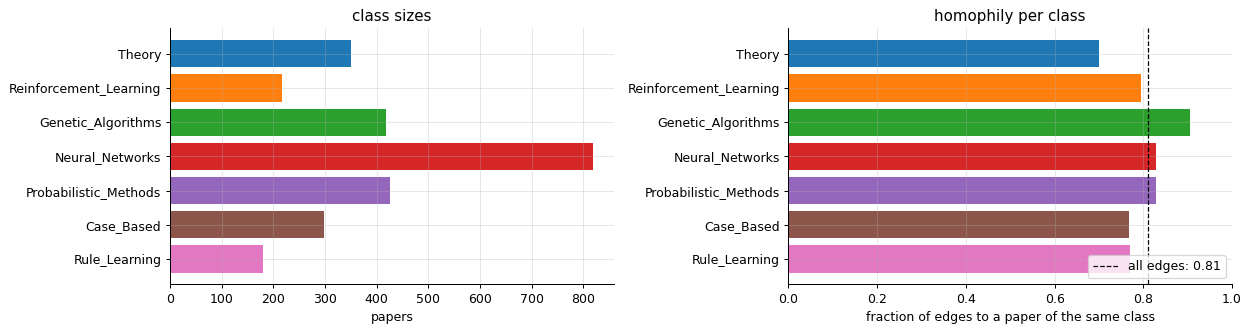

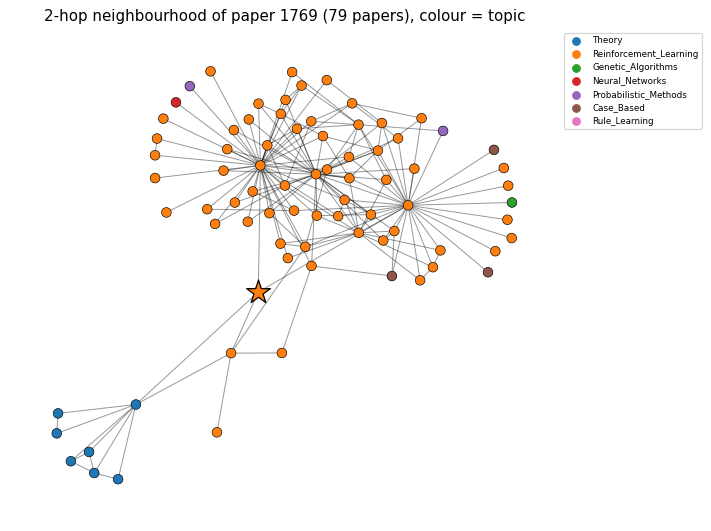

In [26]:
src_c, dst_c = data.edge_index
same = (data.y[src_c] == data.y[dst_c]).float()
h_edge = same.mean().item()
h_class = (torch.zeros(7, device=device).index_add_(0, data.y[dst_c], same) / torch.bincount(data.y[dst_c], minlength=7)).cpu()
print(f"edge homophily of Cora: {h_edge:.3f}")
print(f"chance level Σ_c p_c^2: {sum((c / data.num_nodes) ** 2 for c in counts):.3f}")

CLS_COLORS = plt.get_cmap("tab10")(np.arange(7))
fig, axes = plt.subplots(1, 2, figsize=(14, 3.8))
axes[0].barh(CLASSES, counts, color=CLS_COLORS); axes[0].invert_yaxis()
axes[0].set_xlabel("papers"); axes[0].set_title("class sizes")
axes[1].barh(CLASSES, h_class, color=CLS_COLORS); axes[1].invert_yaxis()
axes[1].axvline(h_edge, color="k", ls="--", lw=1, label=f"all edges: {h_edge:.2f}")
axes[1].set_xlim(0, 1); axes[1].set_xlabel("fraction of edges to a paper of the same class"); axes[1].legend(loc="lower right")
axes[1].set_title("homophily per class")
plt.tight_layout(); plt.show()

for center in data.test_mask.nonzero().flatten().tolist():           # first test paper with a mid-sized 2-hop neighbourhood
    subset, sub_ei, _, _ = k_hop_subgraph(center, 2, data.edge_index, relabel_nodes=True)
    if 60 <= len(subset) <= 110:
        break
G_sub = nx.Graph(); G_sub.add_nodes_from(range(len(subset))); G_sub.add_edges_from(sub_ei.t().tolist())
c_sub = subset.tolist().index(center)
pos_sub = nx.spring_layout(G_sub, seed=0)
fig, ax = plt.subplots(figsize=(8, 6))
draw_graph(ax, G_sub, pos_sub, node_color=CLS_COLORS[data.y[subset].cpu().numpy()], labels=False, node_size=60,
           title=f"2-hop neighbourhood of paper {center} ({len(subset)} papers), colour = topic")
nx.draw_networkx_nodes(G_sub, pos_sub, nodelist=[c_sub], ax=ax, node_color=[CLS_COLORS[data.y[center].item()]], node_size=400, node_shape="*", edgecolors="k")
for i, name in enumerate(CLASSES):
    ax.scatter([], [], color=CLS_COLORS[i], label=name)
ax.legend(fontsize=7, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.show()

81% of the citation edges join two papers on the same topic, against 18% by chance. Papers cite papers in their own field, and the neighbourhood drawing shows big single-colour patches. Cora is a strongly **homophilous** graph: averaging over neighbours mostly averages over papers of the same class, which removes noise from the bag-of-words features without mixing classes. On a **heterophilous** graph (for example a fraud network, where fraudsters connect to honest accounts on purpose, or a dating network) the same averaging would mix classes and hurt.

**Four models**, all evaluated on the same 1000 test papers:

1. an **MLP** on the features alone (ignores the graph);
2. **label propagation** on the graph alone (ignores the features): start from the one-hot labels of the 140 training nodes, zeros elsewhere, and repeat $\mathbf{Y} \leftarrow \hat{\mathbf{A}}\mathbf{Y}$, resetting the training rows to their true labels after every step. The prediction is the argmax of each row. No parameters, no training;
3. **our GCN** from section 6: two `SparseGCNLayer`s $1433 \to 16 \to 7$, ReLU, dropout 0.5;
4. the same network with PyG's `GCNConv`.

Training: Adam, learning rate 0.01, weight decay $5 \cdot 10^{-4}$, 200 full-batch epochs, cross-entropy on the 140 training nodes, test accuracy after the last epoch, 5 seeds. (The GCN paper also applies dropout to the 1433-dimensional input. On a CPU that single random mask costs more than the rest of the training step, and it adds only about one point of accuracy, so we leave it out.)

In [27]:
class MLP(nn.Module):
    """Two-layer MLP on the node features only (ignores edge_index)."""
    def __init__(self, d_in, d_hidden, d_out, dropout=0.5):
        super().__init__()
        self.lin1, self.lin2, self.dropout = nn.Linear(d_in, d_hidden), nn.Linear(d_hidden, d_out), dropout

    def forward(self, x, edge_index):
        h = F.relu(self.lin1(x))
        return self.lin2(F.dropout(h, self.dropout, self.training))


class GCN(nn.Module):
    """Two-layer GCN built from SparseGCNLayer (section 6)."""
    def __init__(self, d_in, d_hidden, d_out, dropout=0.5):
        super().__init__()
        self.conv1, self.conv2, self.dropout = SparseGCNLayer(d_in, d_hidden), SparseGCNLayer(d_hidden, d_out), dropout

    def forward(self, x, edge_index, return_hidden=False):
        src, dst, w = gcn_norm_edges(edge_index, x.size(0))
        h = F.relu(self.conv1(x, src, dst, w))
        out = self.conv2(F.dropout(h, self.dropout, self.training), src, dst, w)
        return (out, h) if return_hidden else out


class PyGGCN(nn.Module):
    """The same two-layer GCN with PyG's GCNConv."""
    def __init__(self, d_in, d_hidden, d_out, dropout=0.5):
        super().__init__()
        self.conv1, self.conv2, self.dropout = GCNConv(d_in, d_hidden), GCNConv(d_hidden, d_out), dropout

    def forward(self, x, edge_index):
        h = F.relu(self.conv1(x, edge_index))
        return self.conv2(F.dropout(h, self.dropout, self.training), edge_index)


def accuracy(logits, y, mask):
    return (logits[mask].argmax(1) == y[mask]).float().mean().item()

def train_node_classifier(model, data, epochs=200, lr=0.01, weight_decay=5e-4, track=True):
    """Full-batch training on the labelled nodes; returns train / val / test accuracy
    after every epoch (track=True) or only after the last one."""
    model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    hist = {"train": [], "val": [], "test": []}
    for epoch in range(epochs):
        model.train(); opt.zero_grad()
        loss = F.cross_entropy(model(data.x, data.edge_index)[data.train_mask], data.y[data.train_mask])
        loss.backward(); opt.step()
        if track or epoch == epochs - 1:
            model.eval()
            with torch.no_grad():
                logits = model(data.x, data.edge_index)
            for split in hist:
                hist[split].append(accuracy(logits, data.y, data[f"{split}_mask"]))
    return hist

def label_propagation(data, iters=50):
    """Spread the one-hot training labels with Y <- Â Y, clamping the labelled rows after every step."""
    src, dst, w = gcn_norm_edges(data.edge_index, data.num_nodes)
    Y0 = torch.zeros(data.num_nodes, dataset.num_classes, device=device)
    Y0[data.train_mask, data.y[data.train_mask]] = 1
    Y = Y0.clone()
    for _ in range(iters):
        Y = propagate(Y, src, dst, w)
        Y[data.train_mask] = Y0[data.train_mask]
    return Y

MLP (features only)      test accuracy 0.573 ± 0.004   runs [0.569 0.577 0.576 0.567 0.578]   (6.7 s)


GCN (ours, section 6)    test accuracy 0.810 ± 0.006   runs [0.802 0.812 0.812 0.818 0.804]   (10.4 s)


GCN (PyG GCNConv)        test accuracy 0.810 ± 0.006   runs [0.802 0.812 0.812 0.818 0.804]   (11.0 s)
label propagation        test accuracy 0.731   (deterministic, no training)
nodes that no label reached (all-zero row): 158   nodes in components without any training node: 158


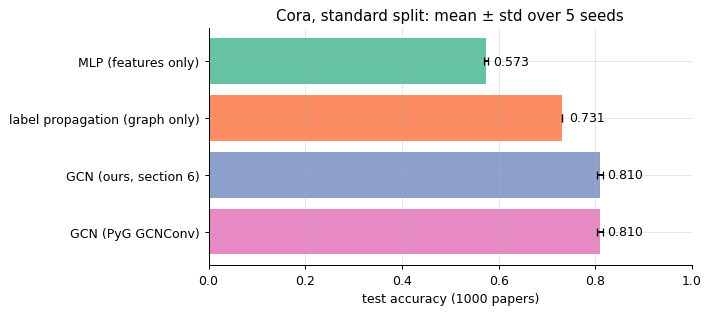

In [28]:
SEEDS = range(5)
results, histories, trained = {}, {}, {}
for name, make in [("MLP (features only)", lambda: MLP(dataset.num_features, 16, 7)),
                   ("GCN (ours, section 6)", lambda: GCN(dataset.num_features, 16, 7)),
                   ("GCN (PyG GCNConv)", lambda: PyGGCN(dataset.num_features, 16, 7))]:
    t0, accs = time.time(), []
    for seed in SEEDS:
        torch.manual_seed(seed)
        model = make()
        hist = train_node_classifier(model, data)
        accs.append(hist["test"][-1])
        if seed == 0:
            histories[name], trained[name] = hist, model
    results[name] = accs
    print(f"{name:<24} test accuracy {np.mean(accs):.3f} ± {np.std(accs):.3f}   runs {np.round(accs, 3)}   ({time.time() - t0:.1f} s)")

Y_lp = label_propagation(data)
results["label propagation (graph only)"] = [accuracy(Y_lp, data.y, data.test_mask)]
print(f"{'label propagation':<24} test accuracy {results['label propagation (graph only)'][0]:.3f}   (deterministic, no training)")
no_label_comp = ~np.isin(comp, comp[data.train_mask.cpu().numpy()])          # components without a training node
print("nodes that no label reached (all-zero row):", int((Y_lp.abs().sum(1) == 0).sum()),
      "  nodes in components without any training node:", int(no_label_comp.sum()))

def plot_results(results, title):
    """Horizontal bar chart of mean ± std test accuracy."""
    names_r = list(results)
    means, stds = [np.mean(results[k]) for k in names_r], [np.std(results[k]) for k in names_r]
    fig, ax = plt.subplots(figsize=(8, 0.6 * len(names_r) + 1.2))
    ax.barh(names_r, means, xerr=stds, color=plt.get_cmap("Set2")(np.arange(len(names_r))), capsize=3)
    for i, m in enumerate(means):
        ax.text(m + 0.015, i, f"{m:.3f}", va="center")
    ax.set_xlim(0, 1); ax.invert_yaxis(); ax.set_xlabel("test accuracy (1000 papers)"); ax.set_title(title)
    plt.tight_layout(); plt.show()

order = ["MLP (features only)", "label propagation (graph only)", "GCN (ours, section 6)", "GCN (PyG GCNConv)"]
plot_results({k: results[k] for k in order}, "Cora, standard split: mean ± std over 5 seeds")

**Reading the results.**
- **Features alone** (MLP): 57.3%. 140 labelled bags of words are not enough to learn 1433-dimensional topic boundaries.
- **Graph alone** (label propagation): 73.1%, with no learned parameter at all. Homophily does a lot of the work. Cora has 78 connected components, and the 158 nodes in components without any training node never receive a label: their row stays zero and the argmax defaults to class 0. A GCN has the same blind spot for the graph part, but it still has the features of these nodes.
- **Features and graph** (GCN): 81.0%. The GCN combines both: it learns which words matter from the 140 labels, and the propagation smooths these predictions over the citation neighbourhoods. The gain over the MLP is about 24 points.
- **Our layer equals PyG's.** Both versions use the same initialisation and draw the same dropout masks, so with the same seed they give identical results, run by run. `GCNConv` does exactly what we wrote in section 6.

Below: the learning curves of the first seed, and a t-SNE map of the raw features against the 16-dimensional hidden layer of the trained GCN.

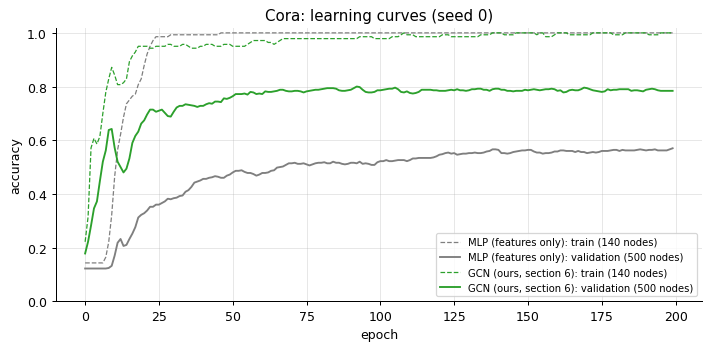

seed 0, final epoch: MLP train 1.000 / val 0.570;  GCN train 1.000 / val 0.784


In [29]:
fig, ax = plt.subplots(figsize=(8, 4))
for name, color in [("MLP (features only)", "tab:gray"), ("GCN (ours, section 6)", "tab:green")]:
    h = histories[name]
    ax.plot(h["train"], "--", color=color, lw=1, label=f"{name}: train (140 nodes)")
    ax.plot(h["val"], color=color, label=f"{name}: validation (500 nodes)")
ax.set_xlabel("epoch"); ax.set_ylabel("accuracy"); ax.set_ylim(0, 1.02); ax.legend(fontsize=8, loc="lower right")
ax.set_title("Cora: learning curves (seed 0)")
plt.tight_layout(); plt.show()
print(f"seed 0, final epoch: MLP train {histories['MLP (features only)']['train'][-1]:.3f} / val {histories['MLP (features only)']['val'][-1]:.3f};"
      f"  GCN train {histories['GCN (ours, section 6)']['train'][-1]:.3f} / val {histories['GCN (ours, section 6)']['val'][-1]:.3f}")

t-SNE of 2708 points, twice: 11.2 s


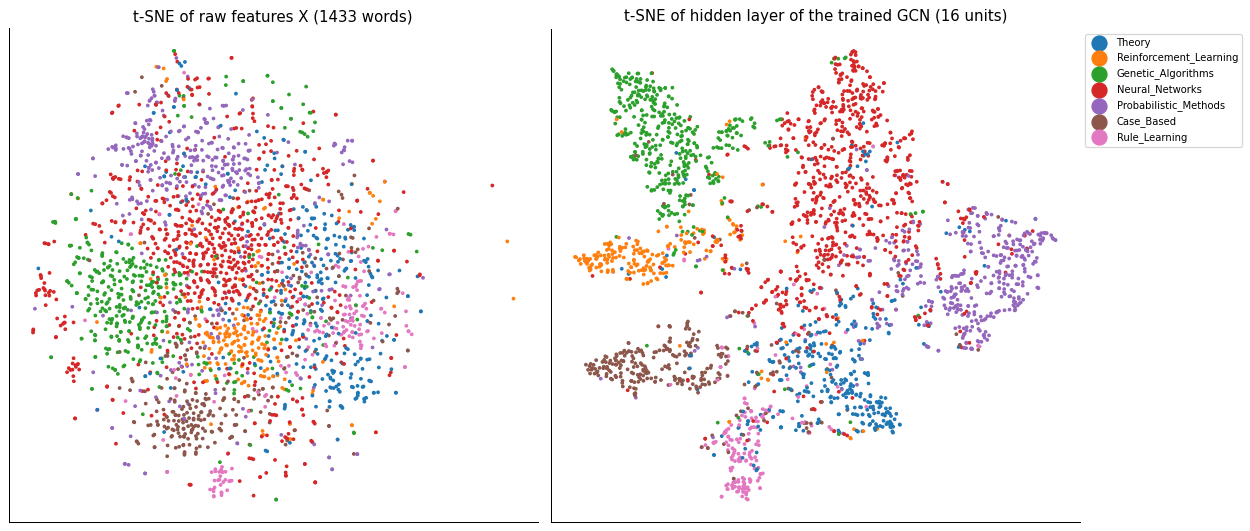

In [30]:
from sklearn.manifold import TSNE
gcn0 = trained["GCN (ours, section 6)"].eval()
with torch.no_grad():
    _, H_hidden = gcn0(data.x, data.edge_index, return_hidden=True)
y_np = data.y.cpu().numpy()
t0 = time.time()
emb_raw = TSNE(init="pca", random_state=0).fit_transform(data.x.cpu().numpy())
emb_gcn = TSNE(init="pca", random_state=0).fit_transform(H_hidden.cpu().numpy())
print(f"t-SNE of 2708 points, twice: {time.time() - t0:.1f} s")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, emb, title in [(axes[0], emb_raw, "raw features X (1433 words)"),
                       (axes[1], emb_gcn, "hidden layer of the trained GCN (16 units)")]:
    ax.scatter(emb[:, 0], emb[:, 1], c=CLS_COLORS[y_np], s=4)
    ax.set_title(f"t-SNE of {title}"); ax.set_xticks([]); ax.set_yticks([])
for i, name in enumerate(CLASSES):
    axes[1].scatter([], [], color=CLS_COLORS[i], label=name)
axes[1].legend(fontsize=8, markerscale=2, loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout(); plt.show()

**Things to notice.**
- Both models end up fitting the 140 training nodes perfectly, the MLP within about 25 epochs. On the validation papers the MLP stalls at 0.57 while the GCN reaches 0.78. The MLP is free to memorise 140 examples; in the GCN every prediction is tied to those of the neighbours, so the 140 labels effectively cover their neighbourhoods. The graph acts as a strong **regulariser**.
- In t-SNE, the raw bag-of-words vectors form one cloud in which the topics overlap heavily, with only a few compact groups. The hidden layer of the GCN shows well-separated clusters by topic, for all 2708 papers, although only 140 labels were used. Part of this comes from the labels, but much comes from the propagation: papers that cite each other end up close.

**Transductive vs inductive.** Here the whole graph, including the features and edges of the test papers, is visible during training; only their **labels** are hidden. The model is trained and evaluated on one fixed graph: this is the **transductive** setting. In the **inductive** setting the model must handle nodes or whole graphs it has never seen (new papers, new users, new molecules). A GCN can do both, because its weights are shared across nodes and never refer to a node identity, but only if its input features are not node identifiers: with the one-hot $\mathbf{X} = \mathbf{I}$ of section 5 there is no way to embed a new member. Sections 11 and 12 are inductive in this sense: section 11 classifies unseen molecules, and section 12 predicts edges that were removed from the graph.

## 8. Graph attention (GAT) from scratch

In a GCN the weight of the message from $u$ to $v$, $1/\sqrt{\tilde d_u \tilde d_v}$, is fixed by the degrees. A **graph attention network** learns it from the features, as in the attention of transformers:

$$
e_{vu} = \text{LeakyReLU}\big(\mathbf{a}^\top[\mathbf{W}\mathbf{h}_v \,\Vert\, \mathbf{W}\mathbf{h}_u]\big), \qquad
\alpha_{vu} = \frac{\exp(e_{vu})}{\sum_{u' \in \mathcal{N}(v)\cup\{v\}} \exp(e_{vu'})}, \qquad
\mathbf{h}_v' = \sum_{u \in \mathcal{N}(v)\cup\{v\}} \alpha_{vu}\,\mathbf{W}\mathbf{h}_u .
$$

($\mathbf{W}\mathbf{h}$ is the column-vector form of the course's $\mathbf{h}^\top\mathbf{W}$; in code it is `self.W(H)` as before.) Here $\Vert$ is concatenation, $\mathbf{a} \in \mathbb{R}^{2d'}$ is a learned vector, and the LeakyReLU has slope 0.2. Each node distributes a total attention of 1 over its neighbourhood, so $\mathbf{h}_v'$ is a learned weighted average.

**Implementation trick.** Split $\mathbf{a} = [\mathbf{a}_{\text{dst}}; \mathbf{a}_{\text{src}}]$. Then $\mathbf{a}^\top[\mathbf{W}\mathbf{h}_v \Vert \mathbf{W}\mathbf{h}_u] = \mathbf{a}_{\text{dst}}^\top\mathbf{W}\mathbf{h}_v + \mathbf{a}_{\text{src}}^\top\mathbf{W}\mathbf{h}_u$: compute one score per node for each half, and gather them per edge. No $\lvert E\rvert \times 2d'$ concatenation is ever built.

**Softmax over a neighbourhood with scatter operations.** The softmax runs over the incoming edges of each node, a different set for each node. With `dst` the target of each edge: compute the per-node maximum of the scores with a scatter-max, subtract it from every edge score (softmax is unchanged by a shift, and this avoids overflow in `exp`), exponentiate, scatter-add the exponentials to get each node's denominator, and divide.

**Multi-head attention.** As in transformers, $K$ independent heads (each with its own $\mathbf{W}^k$, $\mathbf{a}^k$) run in parallel and their outputs are concatenated: $\mathbf{h}_v' = \Vert_{k=1}^K \sum_u \alpha^k_{vu}\mathbf{W}^k\mathbf{h}_u$. Heads can attend to different neighbours, and averaging over heads stabilises training. The output layer averages its heads instead of concatenating them.

In [31]:
def edge_softmax(e, dst, n):
    """Softmax of the edge scores e (|E|, heads) over the incoming edges of every target node."""
    e_max = torch.full((n, e.size(1)), -torch.inf, device=e.device)
    e_max = e_max.scatter_reduce(0, dst[:, None].expand_as(e), e.detach(), reduce="amax")   # per-node max (stability only)
    ex = (e - e_max[dst]).exp()
    denom = torch.zeros(n, e.size(1), device=e.device).index_add_(0, dst, ex)
    return ex / denom[dst]


class GATLayer(nn.Module):
    """Graph attention layer with `heads` heads, written with gather / scatter on edge_index."""
    def __init__(self, d_in, d_out, heads=1, concat=True, dropout=0.6):
        super().__init__()
        self.heads, self.d_out, self.concat, self.dropout = heads, d_out, concat, dropout
        self.W = nn.Linear(d_in, heads * d_out, bias=False)
        self.a_src = nn.Parameter(torch.empty(heads, d_out))      # half of a that multiplies W h_u (sender)
        self.a_dst = nn.Parameter(torch.empty(heads, d_out))      # half of a that multiplies W h_v (receiver)
        self.b = nn.Parameter(torch.zeros(heads * d_out if concat else d_out))
        for p in (self.W.weight, self.a_src, self.a_dst):
            nn.init.xavier_uniform_(p)

    def forward(self, H, edge_index, return_attention=False):
        n = H.size(0)
        loops = torch.arange(n, device=H.device)
        src, dst = torch.cat([edge_index[0], loops]), torch.cat([edge_index[1], loops])        # N(v) ∪ {v}
        Wh = self.W(H).view(n, self.heads, self.d_out)                                         # (n, heads, d_out)
        e = F.leaky_relu((Wh * self.a_dst).sum(-1)[dst] + (Wh * self.a_src).sum(-1)[src], 0.2)   # (|E|, heads)
        alpha = edge_softmax(e, dst, n)
        msg = F.dropout(alpha, self.dropout, self.training)[..., None] * Wh[src]               # (|E|, heads, d_out)
        out = Wh.new_zeros(n, self.heads, self.d_out).index_add_(0, dst, msg)
        out = (out.reshape(n, -1) if self.concat else out.mean(1)) + self.b
        return (out, (src, dst, alpha)) if return_attention else out

# check against PyG's GATConv with the same weights
torch.manual_seed(0)
ours, ref = GATLayer(16, 4, heads=3).eval(), GATConv(16, 4, heads=3).eval()
with torch.no_grad():
    ref.lin.weight.copy_(ours.W.weight); ref.bias.copy_(ours.b)
    ref.att_src.copy_(ours.a_src[None]); ref.att_dst.copy_(ours.a_dst[None])
H_in = torch.randn(n_k, 16)
out_ours, (s_, d_, alpha_) = ours(H_in, edge_index_k, return_attention=True)
out_ref = ref(H_in, edge_index_k)
print(f"karate club, 3 heads: max |our GAT layer - PyG GATConv| = {(out_ours - out_ref).abs().max():.1e}")
assert torch.allclose(out_ours, out_ref, atol=1e-5)
alpha_sums = torch.zeros(n_k, 3).index_add_(0, d_, alpha_)
assert torch.allclose(alpha_sums, torch.ones(n_k, 3), atol=1e-6)
print("attention weights of every node sum to 1 in every head: checked")

karate club, 3 heads: max |our GAT layer - PyG GATConv| = 0.0e+00
attention weights of every node sum to 1 in every head: checked


**Training on Cora.** The architecture of the GAT paper: a first layer with 8 heads of 8 features (64 after concatenation) and ELU, then an output layer with 1 head and the 7 class scores. Dropout 0.6 on the hidden layer and on the attention weights (each neighbour is dropped from a node's average with probability 0.6 during training), Adam with learning rate 0.005, weight decay $5 \cdot 10^{-4}$, 200 epochs, 5 seeds. As for the GCN, we leave out the input dropout.

GAT (ours)   test accuracy 0.817 ± 0.004   runs [0.818 0.822 0.82  0.813 0.811]   (24.5 s)
GCN (ours)   test accuracy 0.810 ± 0.006


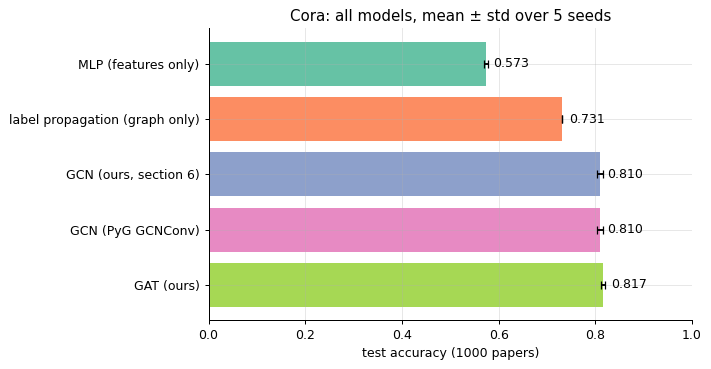

In [32]:
class GAT(nn.Module):
    """Two GAT layers: 8 heads x 8 features (concatenated, ELU), then 1 head with the 7 class scores."""
    def __init__(self, d_in, d_out, hidden=8, heads=8, dropout=0.6):
        super().__init__()
        self.gat1 = GATLayer(d_in, hidden, heads=heads, dropout=dropout)
        self.gat2 = GATLayer(hidden * heads, d_out, heads=1, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        h = F.elu(self.gat1(x, edge_index))
        return self.gat2(F.dropout(h, self.dropout, self.training), edge_index)

t0, accs = time.time(), []
for seed in SEEDS:
    torch.manual_seed(seed)
    model = GAT(dataset.num_features, dataset.num_classes)
    hist = train_node_classifier(model, data, epochs=200, lr=0.005)
    accs.append(hist["test"][-1])
    if seed == 0:
        gat0 = model
results["GAT (ours)"] = accs
print(f"GAT (ours)   test accuracy {np.mean(accs):.3f} ± {np.std(accs):.3f}   runs {np.round(accs, 3)}   ({time.time() - t0:.1f} s)")
print(f"GCN (ours)   test accuracy {np.mean(results['GCN (ours, section 6)']):.3f} ± {np.std(results['GCN (ours, section 6)']):.3f}")
plot_results({k: results[k] for k in order + ["GAT (ours)"]}, "Cora: all models, mean ± std over 5 seeds")

**Inspecting the attention.** For every node we compute the entropy of its attention distribution in the first layer, $-\sum_u \alpha_{vu}\log\alpha_{vu}$, and compare it with the entropy of uniform weights over the same neighbourhood, $\log(d_v + 1)$. Equal entropies mean the node averages its neighbours uniformly, like a mean aggregator; lower entropy means it focuses on a few of them.

nodes with >= 2 neighbours: 2223
mean attention entropy 1.566  vs  uniform 1.569  (nats)
median gap (uniform - attention) over all nodes and heads: 0.000 nats; 90th percentile: 0.005
node 1735 (8 neighbours, class Reinforcement_Learning), head 0: attention weights [0.289 0.102 0.088 0.12  0.082 0.1   0.073 0.078 0.068]


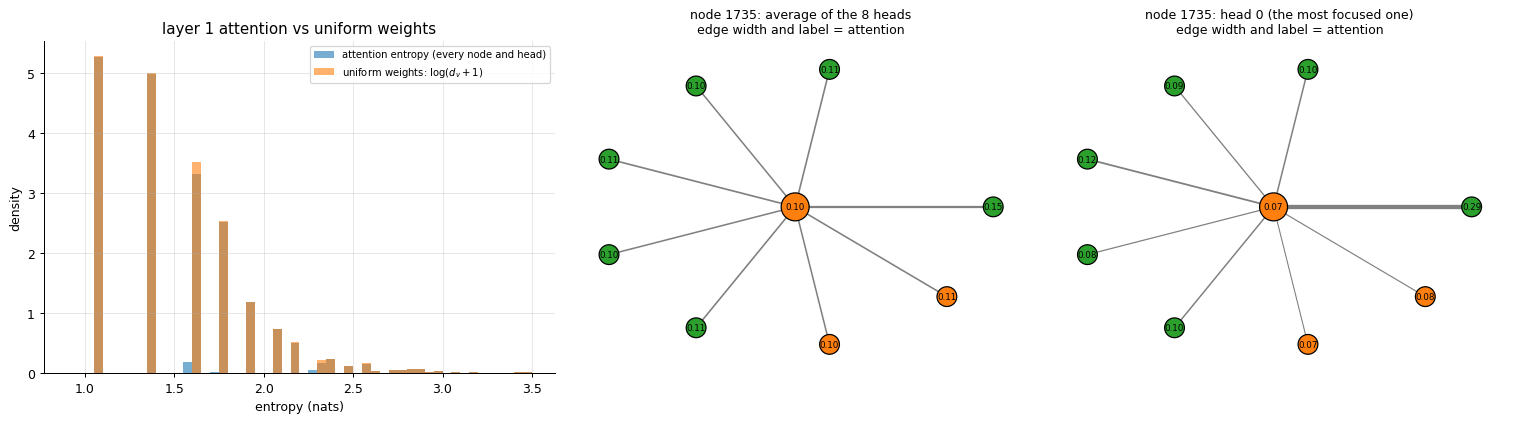

In [33]:
gat0.eval()
with torch.no_grad():
    _, (src_a, dst_a, alpha1) = gat0.gat1(data.x, data.edge_index, return_attention=True)   # alpha1: (|E| + n, 8)
n_c = data.num_nodes
size_nb = torch.bincount(dst_a, minlength=n_c).float()                                    # d_v + 1
ent = torch.zeros(n_c, alpha1.size(1), device=device).index_add_(0, dst_a, -alpha1 * alpha1.clamp_min(1e-12).log())
ent_uniform = size_nb.log()
gap = (ent_uniform[:, None] - ent).cpu()                    # (n, heads): 0 = uniform attention
multi = (size_nb > 2).cpu()                                 # nodes with at least 2 neighbours
print(f"nodes with >= 2 neighbours: {int(multi.sum())}")
print(f"mean attention entropy {ent[multi.to(device)].mean():.3f}  vs  uniform {ent_uniform[multi.to(device)].mean():.3f}  (nats)")
print(f"median gap (uniform - attention) over all nodes and heads: {gap[multi].median():.3f} nats;"
      f" 90th percentile: {gap[multi].quantile(0.9):.3f}")

# the test node (4 to 10 neighbours) whose attention, in its most focused head, is furthest from uniform
cand = (data.test_mask.cpu() & (size_nb.cpu() >= 5) & (size_nb.cpu() <= 11)).nonzero().flatten()
node = cand[gap[cand].max(1).values.argmax()].item()
head = gap[node].argmax().item()
in_edges = (dst_a == node).nonzero().flatten()
nbrs = src_a[in_edges].cpu().numpy()
print(f"node {node} ({len(nbrs) - 1} neighbours, class {CLASSES[data.y[node]]}), head {head}: attention weights",
      np.round(alpha1[in_edges, head].cpu().numpy(), 3))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8), gridspec_kw={"width_ratios": [1.1, 1, 1]})
bins_e = np.linspace(0.9, 3.5, 53)
axes[0].hist(ent[multi.to(device)].cpu().flatten(), bins=bins_e, density=True, alpha=0.6, label="attention entropy (every node and head)")
axes[0].hist(ent_uniform[multi.to(device)].cpu(), bins=bins_e, density=True, alpha=0.6, label=r"uniform weights: $\log(d_v + 1)$")
axes[0].set_xlabel("entropy (nats)"); axes[0].set_ylabel("density"); axes[0].legend(fontsize=8)
axes[0].set_title("layer 1 attention vs uniform weights")
G_star = nx.DiGraph([(int(u), node) for u in nbrs])
pos_star = nx.circular_layout(G_star); pos_star[node] = np.zeros(2)
for ax, weights, title in [(axes[1], alpha1[in_edges].mean(1).cpu().numpy(), "average of the 8 heads"),
                           (axes[2], alpha1[in_edges, head].cpu().numpy(), f"head {head} (the most focused one)")]:
    edges_w = {int(u): a for u, a in zip(nbrs, weights)}
    nx.draw_networkx_edges(G_star, pos_star, ax=ax, edgelist=[(u, node) for u in edges_w if u != node],
                           width=[12 * edges_w[u] for u in edges_w if u != node], arrows=False, edge_color="gray")
    nx.draw_networkx_nodes(G_star, pos_star, ax=ax, node_color=CLS_COLORS[data.y[list(G_star.nodes)].cpu().numpy()],
                           node_size=[500 if u == node else 250 for u in G_star.nodes], edgecolors="k")
    nx.draw_networkx_labels(G_star, pos_star, ax=ax, labels={u: f"{edges_w[u]:.2f}" for u in G_star.nodes}, font_size=7)
    ax.set_title(f"node {node}: {title}\nedge width and label = attention", fontsize=10); ax.axis("off")
plt.tight_layout(); plt.show()

**Interpretation.**
- The GAT reaches 81.7% ± 0.4 against 81.0% ± 0.6 for the GCN: a gain of 0.7 points, about one standard deviation of the seed-to-seed variation, for more than twice the training time. The GAT paper reports 83.0% with a much longer training schedule, input dropout and early stopping; with 200 epochs we land a little lower.
- The reason for the small gain is visible in the entropy histogram: the two distributions coincide. On Cora the learned attention is almost exactly uniform (mean entropy 1.566 nats against 1.569 for uniform weights; the gap is at most 0.005 nats for 90% of the nodes and heads). With uniform weights a GAT layer is a mean aggregator, close to a GCN. On a homophilous graph where most neighbours are equally useful, there is little to gain from choosing between them. Attention pays off when neighbours differ in relevance, for example in noisy or heterophilous graphs.
- Even the most selective head we could find on a test node with 4 to 10 neighbours (head 0 of node 1735) is only mildly focused: it gives 0.29 to one neighbour and 0.07 to 0.12 to the others, where uniform weights would give $1/9 = 0.11$ to each. The average over the 8 heads is flatter still (0.10 to 0.15).

**Link with transformers.** A transformer layer computes $\mathbf{h}_i' = \sum_j \alpha_{ij}\mathbf{W}_V\mathbf{h}_j$ with $\alpha_{ij} = \text{softmax}_j(\mathbf{q}_i^\top\mathbf{k}_j/\sqrt{d})$: it is a graph attention layer on the **complete graph**, where every token attends to every token. Two differences: the score is a scaled dot product instead of $\mathbf{a}^\top[\cdot \Vert \cdot]$, and since the complete graph has no structure, the order of the tokens must be added as **positional encodings**. Graph transformers go the other way: they let every node attend to every node and inject the graph structure as positional encodings (for example Laplacian eigenvectors, section 4) or as attention biases.

## 9. Depth and over-smoothing in practice

In a CNN, deeper is usually better. Section 4 predicts the opposite for a plain GCN: every layer applies the low-pass filter $\hat{\mathbf{A}}$ once more, so after many layers all node embeddings converge. We test it on Cora with GCNs of 1, 2, 4, 8 and 16 layers (`GCNConv`, 64 hidden units, dropout 0.5 before the output layer, 120 epochs, 2 seeds), with and without **residual connections** $\mathbf{H}^{(k+1)} = \mathbf{H}^{(k)} + \text{ReLU}(\hat{\mathbf{A}}\mathbf{H}^{(k)}\mathbf{W}^{(k)})$ in the hidden layers, as in a ResNet.

To measure how alike the node embeddings are, we use the **mean cosine distance** between all pairs of rows of the last hidden layer (the input of the output layer; for a 1-layer model that is $\mathbf{X}$ itself):

$$
\text{MCD}(\mathbf{H}) = 1 - \frac{1}{n^2}\sum_{u, v}\cos(\mathbf{h}_u, \mathbf{h}_v) = 1 - \Big\lVert \frac{1}{n}\sum_v \frac{\mathbf{h}_v}{\lVert\mathbf{h}_v\rVert} \Big\rVert^2 .
$$

(The second form follows by expanding the squared norm of the sum, and costs $O(nd)$ instead of $O(n^2d)$.) It is 0 when all embeddings point in the same direction, the over-smoothed limit of section 4, whatever their lengths. Unlike the normalised Dirichlet energy of section 4, which is 0 only for the $\sqrt{\tilde d_v}$ profile, it is also 0 for a constant representation, which is where the bias terms push a collapsed network. We measure it before training (what the architecture does to the input) and after training.

plain      1 layers   test 0.771   train 0.986   MCD before training 0.944   after 0.944


plain      2 layers   test 0.807   train 1.000   MCD before training 0.598   after 0.215


plain      4 layers   test 0.756   train 1.000   MCD before training 0.273   after 0.341


plain      8 layers   test 0.204   train 0.339   MCD before training 0.103   after 0.151


plain     16 layers   test 0.186   train 0.329   MCD before training 0.034   after 0.168


residual   1 layers   test 0.771   train 0.986   MCD before training 0.944   after 0.944


residual   2 layers   test 0.807   train 1.000   MCD before training 0.598   after 0.215


residual   4 layers   test 0.786   train 1.000   MCD before training 0.273   after 0.272


residual   8 layers   test 0.757   train 1.000   MCD before training 0.039   after 0.389


residual  16 layers   test 0.685   train 0.996   MCD before training 0.001   after 0.408
(62 s)


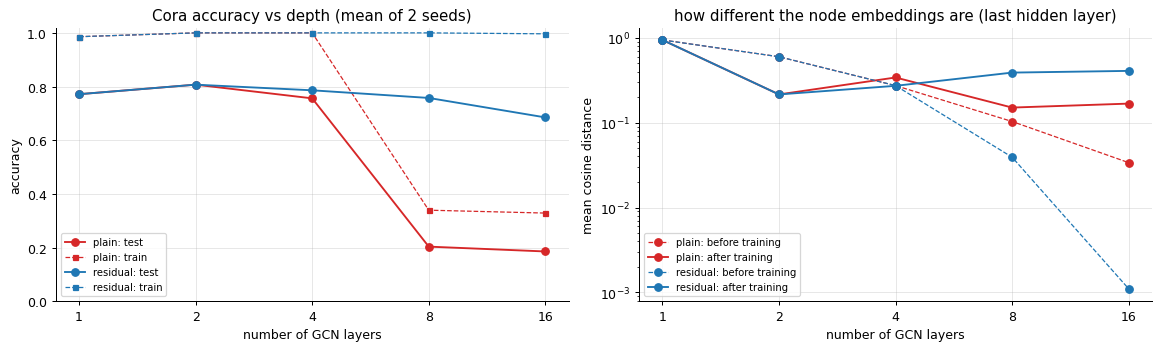

In [34]:
class DeepGCN(nn.Module):
    """n_layers GCNConv layers of width 64, optional residual connections, dropout before the output layer."""
    def __init__(self, d_in, d_out, n_layers, d_hidden=64, residual=False, dropout=0.5):
        super().__init__()
        dims = [d_in] + [d_hidden] * (n_layers - 1) + [d_out]
        self.convs = nn.ModuleList(GCNConv(a, b, cached=True) for a, b in zip(dims[:-1], dims[1:]))   # cached: Â built once
        self.residual, self.dropout = residual, dropout

    def forward(self, x, edge_index, return_hidden=False):
        h = x
        for i, conv in enumerate(self.convs[:-1]):
            h_new = F.relu(conv(h, edge_index))
            h = h + h_new if (self.residual and i > 0) else h_new      # the first layer changes the width: no skip
        out = self.convs[-1](F.dropout(h, self.dropout, self.training), edge_index)
        return (out, h) if return_hidden else out

def mean_cosine_distance(H):
    """1 - average cosine similarity over all pairs of rows (0 = all embeddings point the same way)."""
    return 1 - (F.normalize(H, dim=1).mean(0) ** 2).sum().item()

@torch.no_grad()
def last_hidden(model):
    model.eval()
    return model(data.x, data.edge_index, return_hidden=True)[1]

depths, depth_res = [1, 2, 4, 8, 16], {}
t0 = time.time()
for residual in [False, True]:
    for L in depths:
        runs = []
        for seed in range(2):
            torch.manual_seed(seed)
            model = DeepGCN(dataset.num_features, dataset.num_classes, L, residual=residual).to(device)
            mcd_init = mean_cosine_distance(last_hidden(model))
            hist = train_node_classifier(model, data, epochs=120, track=False)
            runs.append((hist["test"][-1], hist["train"][-1], mcd_init, mean_cosine_distance(last_hidden(model))))
        depth_res[residual, L] = np.mean(runs, axis=0)
        print(f"{'residual' if residual else 'plain':<9}{L:>3} layers   test {depth_res[residual, L][0]:.3f}   train {depth_res[residual, L][1]:.3f}"
              f"   MCD before training {depth_res[residual, L][2]:.3f}   after {depth_res[residual, L][3]:.3f}")
print(f"({time.time() - t0:.0f} s)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for residual, color in [(False, "tab:red"), (True, "tab:blue")]:
    label = "residual" if residual else "plain"
    r = np.array([depth_res[residual, L] for L in depths])
    axes[0].plot(depths, r[:, 0], "o-", color=color, label=f"{label}: test")
    axes[0].plot(depths, r[:, 1], "s--", color=color, lw=1, ms=4, label=f"{label}: train")
    axes[1].plot(depths, r[:, 2], "o--", color=color, lw=1, label=f"{label}: before training")
    axes[1].plot(depths, r[:, 3], "o-", color=color, label=f"{label}: after training")
for ax in axes:
    ax.set_xscale("log", base=2); ax.set_xticks(depths); ax.set_xticklabels(depths); ax.set_xlabel("number of GCN layers")
axes[0].set_ylabel("accuracy"); axes[0].set_ylim(0, 1.02); axes[0].legend(fontsize=8); axes[0].set_title("Cora accuracy vs depth (mean of 2 seeds)")
axes[1].set_yscale("log"); axes[1].set_ylabel("mean cosine distance"); axes[1].legend(fontsize=8)
axes[1].set_title("how different the node embeddings are (last hidden layer)")
plt.tight_layout(); plt.show()

**Interpretation.**
- **Plain GCN: shallow is best.** The 2-layer GCN is the best model (test 0.807). With 4 layers it drops to 0.756, and with 8 and 16 layers it collapses to about 0.20, with a training accuracy of only 0.34 and 0.33: the deep plain network cannot even fit the 140 training nodes.
- **Over-smoothing is visible before any training.** The mean cosine distance of the plain network's last hidden layer shrinks with depth: 0.94 for the raw features, 0.60 after 2 layers, 0.27 after 4, 0.10 after 8 and 0.034 after 16. At 16 layers the 2708 embeddings point almost the same way (average cosine similarity 0.97), as section 4 predicts for repeated multiplication by $\hat{\mathbf{A}}$. Training starts from representations in which the classes are hard to tell apart, and it does not recover: after training the deep plain networks are still at 0.15 to 0.17.
- **Residual connections slow the collapse.** With them the accuracy degrades slowly, 0.786 with 4 layers, 0.757 with 8 and 0.685 with 16, and the training accuracy stays near 1. They do not stop the smoothing at initialisation: the residual network is even more collapsed (0.039 at 8 layers, 0.001 at 16), because every layer adds one more smoothed, non-negative term to the sum and these terms share their dominant direction. What changes is training: gradients reach the early layers through the identity paths, the network fits the training set, and training pulls the embeddings apart again (0.39 to 0.41 after training, against 0.15 to 0.17 for the plain network). Still, no depth beats the 2-layer model.

Two effects are mixed here, as the literature has also found: **over-smoothing** (the representation collapses with depth) and the plain difficulty of **training** a deep stack of layers (vanishing gradients, as in deep MLPs). Other remedies attack the smoothing more directly: concatenating the outputs of all layers ("jumping knowledge"), normalisations that keep embeddings apart (PairNorm), or mixing the first-layer representation back in at every layer (APPNP, GCNII).

Over-smoothing is one of **three classic limits** of message passing:
1. **Over-smoothing**: many layers make all embeddings alike (sections 4 and 9).
2. **Over-squashing**: the receptive field grows exponentially with depth, but each node has a fixed-size vector, so information from far away is squeezed through bottleneck edges and lost. A long-range dependency through a bridge edge is hard to learn however many layers we add. Fixes rewire the graph or add global attention.
3. **Heterophily**: if neighbours tend to have different labels, averaging over them mixes classes. Fixes keep the node's own vector separate from the neighbourhood aggregate (as GraphSAGE does), use signed or learned weights, or aggregate over 2-hop neighbourhoods.

## 10. Expressive power: aggregators and the Weisfeiler–Lehman test

Which graphs can a message-passing GNN tell apart? The answer depends first on the aggregator. A node sees its neighbours as a **multiset** of vectors (a set where repetitions count), and AGG must turn that multiset into one vector. If two different neighbourhoods give the same aggregate, no later layer can recover the difference.

### 10a. Sum, mean and max on multisets

multiset 1  multiset 2                  sum            mean             max
[1, 1]      [1]                    2 vs 1 ✓          1 vs 1          1 vs 1
[1, 2]      [1, 1, 2, 2]           3 vs 6 ✓      1.5 vs 1.5          2 vs 2
[1, 2]      [1, 2, 2]              3 vs 5 ✓   1.5 vs 1.67 ✓          2 vs 2
✓ = the aggregator tells the two neighbourhoods apart


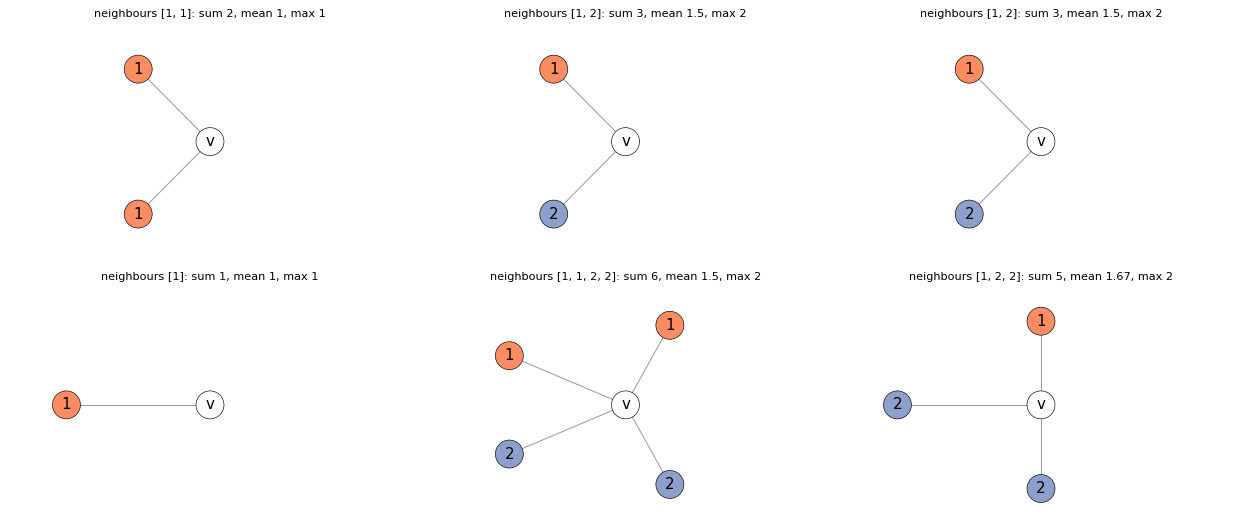

In [35]:
pairs = [([1, 1], [1]), ([1, 2], [1, 1, 2, 2]), ([1, 2], [1, 2, 2])]
aggs = {"sum": np.sum, "mean": np.mean, "max": np.max}
print(f"{'multiset 1':<12}{'multiset 2':<15}" + "".join(f"{a:>16}" for a in aggs))
for m1, m2 in pairs:
    cells_ = [f"{f(m1):.3g} vs {f(m2):.3g}" + ("" if np.isclose(f(m1), f(m2)) else " ✓") for f in aggs.values()]
    print(f"{str(m1):<12}{str(m2):<15}" + "".join(f"{c:>16}" for c in cells_))
print("✓ = the aggregator tells the two neighbourhoods apart")
assert np.mean([1, 1]) == np.mean([1]) and np.max([1, 1]) == np.max([1]) and np.sum([1, 1]) != np.sum([1])
assert np.mean([1, 2]) == np.mean([1, 1, 2, 2]) and np.max([1, 2]) == np.max([1, 1, 2, 2])
assert np.sum([1, 2]) != np.sum([1, 1, 2, 2])
assert np.max([1, 2]) == np.max([1, 2, 2]) and np.mean([1, 2]) != np.mean([1, 2, 2])

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for j, (m1, m2) in enumerate(pairs):
    for i, ms in enumerate([m1, m2]):
        ax = axes[i, j]
        star = nx.star_graph(len(ms))
        pos_s = nx.circular_layout(star); pos_s[0] = np.zeros(2)
        draw_graph(ax, star, pos_s, node_color=["white"] + [plt.get_cmap("Set2")(m) for m in ms], labels=False, node_size=500)
        nx.draw_networkx_labels(star, pos_s, labels={0: "v", **{k + 1: m for k, m in enumerate(ms)}}, ax=ax)
        ax.set_title(f"neighbours {ms}: sum {np.sum(ms)}, mean {np.mean(ms):.3g}, max {np.max(ms)}", fontsize=9)
        ax.set_xlim(-1.4, 1.4); ax.set_ylim(-1.4, 1.4)
plt.tight_layout(); plt.show()

- **Mean** sees only the **proportions** of each value: a node with one neighbour of feature 1 and a node with two such neighbours look the same. It cannot count.
- **Max** sees only **which values occur**: $\{1, 2\}$ and $\{1, 2, 2\}$ look the same.
- **Sum** distinguishes all three pairs. With one-hot features the sum is the vector of counts of each value, which determines the multiset exactly. Xu et al. (2019) proved more generally that sum aggregation followed by an MLP can be **injective** on multisets, and that mean and max cannot.

In an insurance graph, a claimant whose only link is one flagged garage and a claimant linked to five flagged garages have the same mean and the same max over their neighbours. Only the sum sees the difference.

### 10b. The Weisfeiler–Lehman colour refinement

The **1-WL test** (Weisfeiler and Lehman, 1968) is a classical heuristic for graph isomorphism. It is message passing with a perfect, injective aggregator:

1. Give every node the same colour.
2. Repeat: the new colour of $v$ is a hash of (old colour of $v$, **sorted multiset** of the old colours of its neighbours). Equal inputs get equal colours, different inputs different colours.
3. After each round, compare the **colour histograms** of the two graphs. If they differ, the graphs are certainly not isomorphic. If they never differ, the test is inconclusive.

To make colours comparable across graphs, we refine both graphs together with one shared table of colours; that table is our injective "hash".

same degree sequence: True
round 0: graph 1 [(0, 6)]   graph 2 [(0, 6)]   -> same
round 1: graph 1 [(0, 3), (1, 2), (2, 1)]   graph 2 [(0, 3), (1, 2), (2, 1)]   -> same
round 2: graph 1 [(0, 1), (1, 2), (2, 1), (4, 1), (5, 1)]   graph 2 [(0, 2), (1, 1), (3, 2), (6, 1)]   -> DIFFERENT


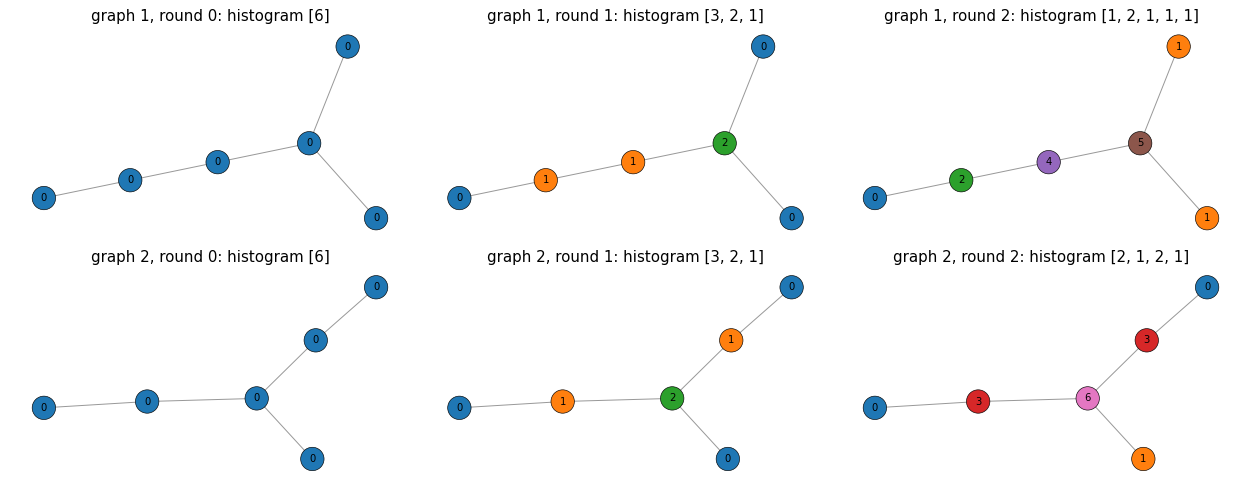

In [36]:
def wl_refine(graphs, iters=3):
    """1-WL colour refinement run jointly on several graphs (one shared colour table).
    Returns colours[t][g] = {node: colour} after t rounds."""
    colours = [[{v: 0 for v in g} for g in graphs]]                  # round 0: all nodes look the same
    for _ in range(iters):
        prev = colours[-1]
        sigs = [{v: (c[v], tuple(sorted(c[u] for u in g[v]))) for v in g} for g, c in zip(graphs, prev)]
        table = {s: i for i, s in enumerate(sorted({s for sg in sigs for s in sg.values()}))}   # injective "hash"
        colours.append([{v: table[s] for v, s in sg.items()} for sg in sigs])
    return colours

def colour_histogram(c):
    """Sorted (colour, count) pairs: the WL fingerprint of one graph."""
    return sorted(Counter(c.values()).items())

g1 = nx.path_graph(5); g1.add_edge(1, 5)          # a path with a branch at its second node
g2 = nx.path_graph(5); g2.add_edge(2, 5)          # a path with a branch at its middle node
print("same degree sequence:", sorted(d for _, d in g1.degree()) == sorted(d for _, d in g2.degree()))
wl12 = wl_refine([g1, g2], iters=2)
for t, ct in enumerate(wl12):
    h1, h2 = colour_histogram(ct[0]), colour_histogram(ct[1])
    print(f"round {t}: graph 1 {h1}   graph 2 {h2}   -> {'same' if h1 == h2 else 'DIFFERENT'}")
assert colour_histogram(wl12[1][0]) == colour_histogram(wl12[1][1]) and colour_histogram(wl12[2][0]) != colour_histogram(wl12[2][1])

fig, axes = plt.subplots(2, 3, figsize=(14, 5.5))
for i, g in enumerate([g1, g2]):
    pos_g = nx.kamada_kawai_layout(g)
    for t in range(3):
        cvals = [wl12[t][i][v] for v in g]
        draw_graph(axes[i, t], g, pos_g, node_color=[plt.get_cmap("tab10")(c) for c in cvals], labels=False, node_size=350,
                   title=f"graph {i + 1}, round {t}: histogram {[n for _, n in colour_histogram(wl12[t][i])]}")
        nx.draw_networkx_labels(g, pos_g, labels=dict(zip(g, cvals)), ax=axes[i, t], font_size=8)
plt.tight_layout(); plt.show()

Round 1 colours the nodes by degree. Both graphs have the same degree sequence, so the histograms still agree. Round 2 looks at the degrees of the neighbours: in graph 1 the degree-3 node has two leaves attached to it, in graph 2 only one. The histograms differ, so the graphs are not isomorphic. Each round of WL looks one hop further, exactly like one layer of a GNN.

### 10c. Where 1-WL, and every message-passing GNN, fails

**Theorem** (Xu et al. 2019; Morris et al. 2019). If 1-WL gives two graphs the same colour histograms, then **every** message-passing GNN gives them the same graph embedding (with a symmetric readout).

*Proof sketch, by induction on the layer $k$.* Claim: two nodes with the same WL colour after round $k$ have the same embedding after layer $k$. At $k = 0$ all nodes have the same input (no features, or the same feature). If $v$ and $v'$ have the same colour at round $k + 1$, they had the same colour at round $k$ and the same multiset of neighbour colours, so by induction the same own embedding and the same multiset of neighbour embeddings. AGG and UPDATE are functions of exactly these, so the outputs are equal. Equal colour histograms then give equal multisets of node embeddings, hence equal readouts. $\blacksquare$

So 1-WL is an **upper bound** on what message passing can distinguish. The bound is tight for the **Graph Isomorphism Network (GIN)**, whose layer
$$
\mathbf{h}_v' = \text{MLP}\Big((1 + \varepsilon)\,\mathbf{h}_v + \sum_{u \in \mathcal{N}(v)} \mathbf{h}_u\Big)
$$
uses a sum (injective on multisets, 10a), keeps the node's own vector distinguishable from its neighbours' through $\varepsilon$, and an MLP that can approximate the injective "hash". GCN (a weighted mean) and GAT (a learned weighted mean) are strictly weaker.

The classic failure: **two disjoint triangles** versus **one hexagon**. Both have 6 nodes, 6 edges, and every node has degree 2. Every node sees two neighbours that see two neighbours, and so on, so WL never splits the colours. We check it, and we check that random GIN and GCN networks with constant input features give exactly the same graph embedding for both graphs.

1-WL colour histograms of the two graphs are identical in all 5 rounds: [(0, 6)]
GIN: max |embedding(two triangles) - embedding(hexagon)| = 0.0e+00
GCN: max |embedding(two triangles) - embedding(hexagon)| = 0.0e+00
GIN with random node features: max difference = 0.267  (embedding size 1.846: now different)


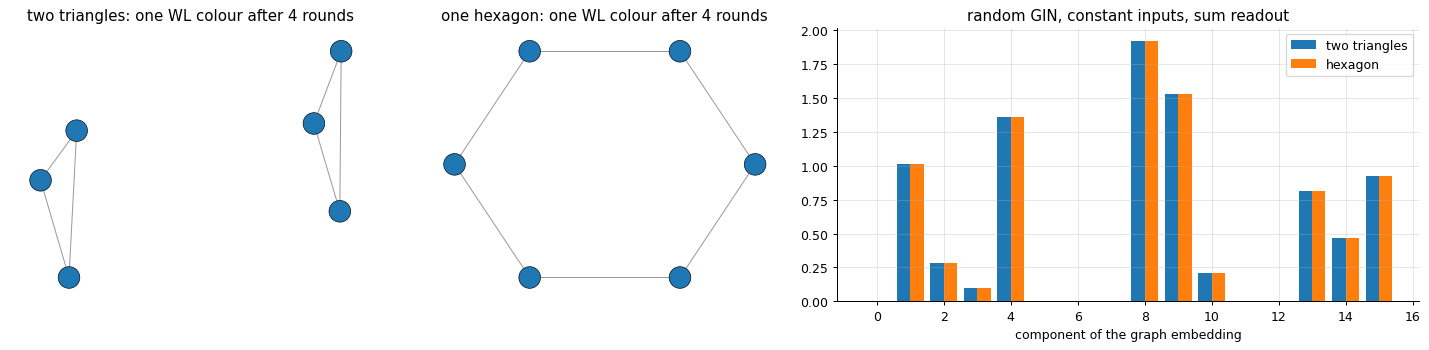

In [37]:
two_triangles = nx.disjoint_union(nx.cycle_graph(3), nx.cycle_graph(3))
hexagon = nx.cycle_graph(6)
wl_th = wl_refine([two_triangles, hexagon], iters=4)
assert all(colour_histogram(ct[0]) == colour_histogram(ct[1]) for ct in wl_th)
print("1-WL colour histograms of the two graphs are identical in all", len(wl_th), "rounds:", colour_histogram(wl_th[-1][0]))

def random_gnn_readout(G, kind, X=None, n_layers=3, dim=16, seed=0):
    """Sum readout of a random-weight GIN or GCN; the same seed gives the same weights for every graph."""
    torch.manual_seed(seed)
    A = torch.tensor(nx.to_numpy_array(G, nodelist=sorted(G)), dtype=torch.float32)
    A_hat = torch.tensor(normalize_adj(A.numpy()), dtype=torch.float32)
    H = torch.ones(len(A), 1) if X is None else X                    # constant input: no node features
    for _ in range(n_layers):
        mlp = nn.Sequential(nn.Linear(H.shape[1], dim), nn.ReLU(), nn.Linear(dim, dim))
        H = torch.relu(mlp(1.1 * H + A @ H)) if kind == "GIN" else torch.relu(A_hat @ mlp(H))   # GIN with ε = 0.1
    return H.sum(0).detach()

for kind in ["GIN", "GCN"]:
    z_tri, z_hex = random_gnn_readout(two_triangles, kind), random_gnn_readout(hexagon, kind)
    print(f"{kind}: max |embedding(two triangles) - embedding(hexagon)| = {(z_tri - z_hex).abs().max():.1e}")
    assert torch.allclose(z_tri, z_hex, atol=1e-5)

torch.manual_seed(1)
X_random = torch.randn(6, 3)                                         # fix: random node features
z_tri_r, z_hex_r = random_gnn_readout(two_triangles, "GIN", X=X_random), random_gnn_readout(hexagon, "GIN", X=X_random)
print(f"GIN with random node features: max difference = {(z_tri_r - z_hex_r).abs().max():.3f}"
      f"  (embedding size {z_tri_r.abs().max():.3f}: now different)")

fig, axes = plt.subplots(1, 3, figsize=(16, 4), gridspec_kw={"width_ratios": [1, 1, 1.6]})
for ax, g, title in [(axes[0], two_triangles, "two triangles"), (axes[1], hexagon, "one hexagon")]:
    draw_graph(ax, g, nx.kamada_kawai_layout(g) if g is hexagon else nx.spring_layout(g, seed=1), labels=False, node_size=300,
               node_color=[plt.get_cmap("tab10")(wl_th[-1][0 if g is two_triangles else 1][v]) for v in g],
               title=f"{title}: one WL colour after 4 rounds")
z_tri, z_hex = random_gnn_readout(two_triangles, "GIN"), random_gnn_readout(hexagon, "GIN")
idx = np.arange(len(z_tri))
axes[2].bar(idx - 0.2, z_tri, width=0.4, label="two triangles"); axes[2].bar(idx + 0.2, z_hex, width=0.4, label="hexagon")
axes[2].set_xlabel("component of the graph embedding"); axes[2].legend(); axes[2].set_title("random GIN, constant inputs, sum readout")
plt.tight_layout(); plt.show()

**What just happened?** Two graphs that any chemist would tell apart (two rings of 3 versus one ring of 6) get the same WL colours in every round, and exactly the same embedding (difference 0.0) from the random GIN and GCN. No amount of training can fix this, because the embeddings are identical for **every** choice of weights. Cycle length, triangle counts, connectivity: a message-passing GNN cannot count any of them in this example.

**Fixes, one line each.**
- **Node identifiers or random features**: give every node a unique or random input vector. This breaks the symmetry (above, the largest difference became 0.27, on embeddings of size about 1.8), but the output then depends on the arbitrary IDs or the random draw, so permutation invariance only holds on average.
- **Positional and structural encodings**: add features that describe each node's position or surroundings, such as Laplacian eigenvectors (section 4), random-walk return probabilities, or counts of triangles and cycles through the node.
- **Higher-order GNNs**: pass messages between pairs or tuples of nodes ($k$-WL and $k$-GNNs) or between subgraphs. More expressive, but much more expensive ($O(n^k)$ tuples).

## 11. Graph classification on MUTAG

**MUTAG** is a set of 188 small molecules (nitroaromatic compounds). Each node is an atom, one-hot encoded among 7 types, and each edge is a bond. The label says whether the compound is **mutagenic** on a bacterium. Now each example is a whole graph, and we need one prediction per graph: GNN layers, then a **readout** (sum, mean or max over the nodes of the graph), then a classifier.

graphs: 188   node features: 7 (one-hot atom type)   classes: 2
class sizes: [63, 125]   (1 = mutagenic)
atoms per molecule: mean 17.9, min 10, max 28
first molecule: Data(edge_index=[2, 38], x=[17, 7], edge_attr=[38, 4], y=[1])


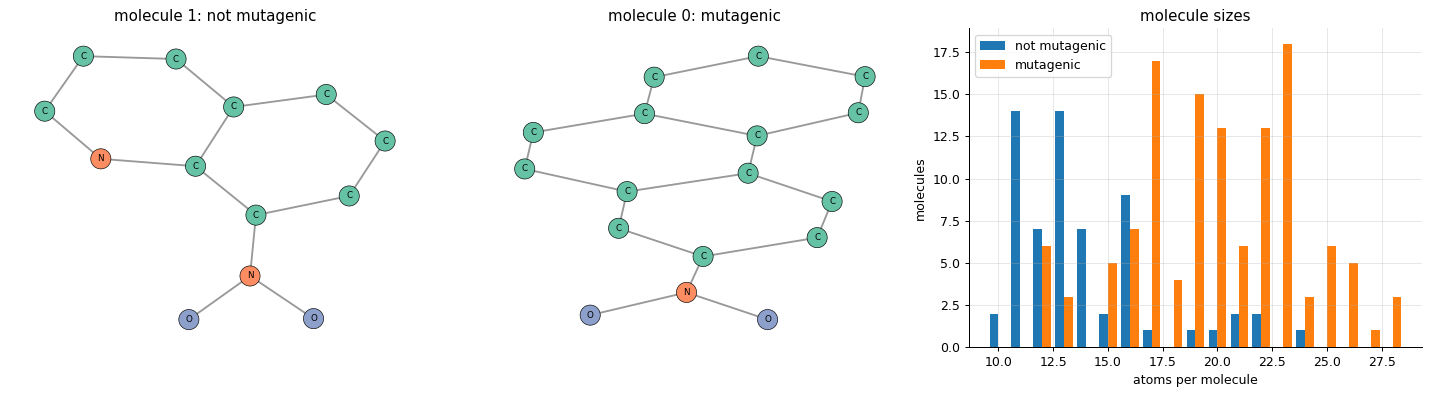

In [38]:
mutag = TUDataset(root="data/TUDataset", name="MUTAG")
ATOMS = ["C", "N", "O", "F", "I", "Cl", "Br"]                 # meaning of the 7 one-hot node features
y_m = mutag.y.numpy()
n_atoms = np.array([g.num_nodes for g in mutag])
print(f"graphs: {len(mutag)}   node features: {mutag.num_node_features} (one-hot atom type)   classes: {mutag.num_classes}")
print(f"class sizes: {np.bincount(y_m).tolist()}   (1 = mutagenic)")
print(f"atoms per molecule: mean {n_atoms.mean():.1f}, min {n_atoms.min()}, max {n_atoms.max()}")
print("first molecule:", mutag[0])

def draw_molecule(ax, g, title):
    """Draw one molecule, atoms coloured and labelled by type."""
    G_m = to_networkx(g, to_undirected=True)
    atoms = g.x.argmax(1).numpy()
    pos_m = nx.kamada_kawai_layout(G_m)
    draw_graph(ax, G_m, pos_m, node_color=plt.get_cmap("Set2")(atoms), labels=False, node_size=260, edge_width=1.5, title=title)
    nx.draw_networkx_labels(G_m, pos_m, labels={v: ATOMS[a] for v, a in enumerate(atoms)}, ax=ax, font_size=7)

i_neg, i_pos = int(np.where(y_m == 0)[0][0]), int(np.where(y_m == 1)[0][0])
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), gridspec_kw={"width_ratios": [1, 1, 1.1]})
draw_molecule(axes[0], mutag[i_neg], f"molecule {i_neg}: not mutagenic")
draw_molecule(axes[1], mutag[i_pos], f"molecule {i_pos}: mutagenic")
axes[2].hist([n_atoms[y_m == 0], n_atoms[y_m == 1]], bins=np.arange(9.5, 29.5, 1), label=["not mutagenic", "mutagenic"])
axes[2].set_xlabel("atoms per molecule"); axes[2].set_ylabel("molecules"); axes[2].legend(); axes[2].set_title("molecule sizes")
plt.tight_layout(); plt.show()

**Mini-batches of graphs.** Graphs have different sizes, so they cannot be stacked into one tensor like images. PyG's `DataLoader` puts the graphs of a batch side by side as **one big disconnected graph**:
- the node feature matrices are concatenated (rows of graph 2 after the rows of graph 1),
- the `edge_index` of graph $i$ is shifted by the number of nodes before it, so its adjacency matrix is a **block on the diagonal** and no edge connects two graphs,
- a `batch` vector records, for every node, which graph it belongs to.

Message passing on the big graph is then exactly message passing on each graph separately, and the readout sums (or averages, or maxes) the node vectors with the same `batch` value. No padding, no masking.

DataBatch(edge_index=[2, 94], x=[43, 7], edge_attr=[94, 4], y=[3], batch=[43], ptr=[4])
atoms in the 3 molecules: [17, 13, 13]   -> nodes in the batch: 43
batch vector (graph of every node):
 [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2]
ptr (first node of every graph): [0, 17, 30, 43]
first edge of molecule 1 on its own: [0, 1]   in the batch: [17, 18]  (shifted by 17)
sum readout of the raw features = atom counts per molecule:
           C   N   O   F   I  Cl  Br
mol 0:   14   1   2   0   0   0   0
mol 1:    9   2   2   0   0   0   0
mol 2:    9   2   2   0   0   0   0


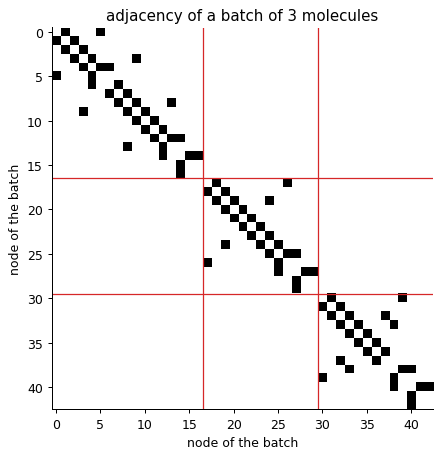

In [39]:
batch = next(iter(DataLoader(mutag[:3], batch_size=3)))
print(batch)
print("atoms in the 3 molecules:", [g.num_nodes for g in mutag[:3]], "  -> nodes in the batch:", batch.num_nodes)
print("batch vector (graph of every node):\n", batch.batch.tolist())
print("ptr (first node of every graph):", batch.ptr.tolist())
print("first edge of molecule 1 on its own:", mutag[1].edge_index[:, 0].tolist(),
      "  in the batch:", batch.edge_index[:, mutag[0].num_edges].tolist(), f" (shifted by {mutag[0].num_nodes})")
composition = global_add_pool(batch.x, batch.batch)               # sum readout of the one-hot atom types
print("sum readout of the raw features = atom counts per molecule:")
print("        " + "".join(f"{a:>4}" for a in ATOMS))
for i, row in enumerate(composition.int().tolist()):
    print(f"mol {i}: " + "".join(f"{c:>4}" for c in row))

A_batch = to_dense_adj(batch.edge_index, max_num_nodes=batch.num_nodes)[0]
fig, ax = plt.subplots(figsize=(5.2, 5.2))
ax.imshow(A_batch, cmap="Greys"); ax.grid(False)
for p in batch.ptr[1:-1].tolist():
    ax.axhline(p - 0.5, color="tab:red", lw=1); ax.axvline(p - 0.5, color="tab:red", lw=1)
ax.set_title("adjacency of a batch of 3 molecules"); ax.set_xlabel("node of the batch"); ax.set_ylabel("node of the batch")
plt.tight_layout(); plt.show()

**Model and evaluation.** A GIN with 3 `GINConv` layers of 32 units (each with an MLP Linear–BatchNorm–ReLU–Linear and a learned $\varepsilon$), a readout, and a linear classifier. We compare three readouts, sum, mean and max, with **10-fold stratified cross-validation**: the 188 molecules are split into 10 folds with the same class proportions; each fold is the test set once, the model is trained from scratch on the other 9 (Adam, learning rate 0.01, batches of 32, 60 epochs), and we report the mean and standard deviation of the 10 test accuracies. The test fold is never used to choose anything, not even the number of epochs.

readout sum   accuracy 0.845 ± 0.048   folds [0.84 0.89 0.84 0.89 0.84 0.84 0.84 0.89 0.83 0.72]


readout mean  accuracy 0.808 ± 0.065   folds [0.79 0.79 0.89 0.74 0.79 0.95 0.79 0.84 0.78 0.72]


readout max   accuracy 0.814 ± 0.089   folds [0.84 0.63 0.74 0.89 0.74 0.89 0.84 0.95 0.83 0.78]
majority class: 0.665   (33 s)
sum - mean: mean difference +0.037, per fold from -0.11 to +0.16
sum - max: mean difference +0.031, per fold from -0.06 to +0.26
mean - max: mean difference -0.006, per fold from -0.16 to +0.16


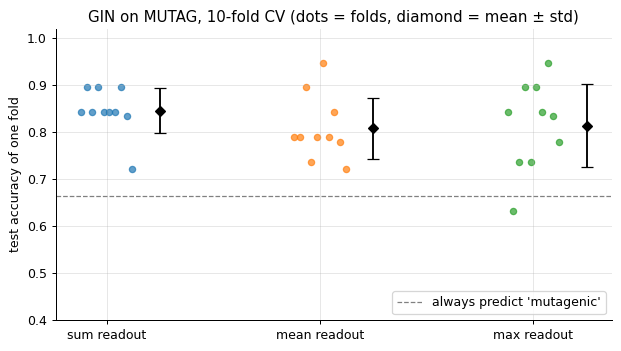

In [40]:
from sklearn.model_selection import StratifiedKFold

class GIN(nn.Module):
    """GINConv layers (MLP with batch norm inside), a readout over each graph's nodes, a linear classifier."""
    def __init__(self, d_in, d_hidden=32, n_classes=2, n_layers=3, readout=global_add_pool):
        super().__init__()
        dims = [d_in] + [d_hidden] * n_layers
        self.convs = nn.ModuleList(
            GINConv(nn.Sequential(nn.Linear(a, b), nn.BatchNorm1d(b), nn.ReLU(), nn.Linear(b, b)), train_eps=True)
            for a, b in zip(dims[:-1], dims[1:]))
        self.readout, self.head = readout, nn.Linear(d_hidden, n_classes)

    def forward(self, x, edge_index, batch):
        for conv in self.convs:
            x = F.relu(conv(x, edge_index))
        return self.head(self.readout(x, batch))                 # one row per graph

def cross_validate(readout, n_folds=10, epochs=60, seed=0):
    """Test accuracy of a GIN with the given readout on each fold of a stratified k-fold split."""
    accs = []
    folds = StratifiedKFold(n_folds, shuffle=True, random_state=seed).split(np.zeros(len(y_m)), y_m)
    for fold, (tr_idx, te_idx) in enumerate(folds):
        torch.manual_seed(fold)
        model = GIN(mutag.num_node_features, readout=readout).to(device)
        opt = torch.optim.Adam(model.parameters(), lr=0.01)
        loader = DataLoader(mutag[torch.tensor(tr_idx)], batch_size=32, shuffle=True,
                            generator=torch.Generator().manual_seed(fold))
        for epoch in range(epochs):
            model.train()
            for b in loader:
                b = b.to(device)
                opt.zero_grad()
                F.cross_entropy(model(b.x, b.edge_index, b.batch), b.y).backward()
                opt.step()
        model.eval()
        test_batch = next(iter(DataLoader(mutag[torch.tensor(te_idx)], batch_size=len(te_idx)))).to(device)
        with torch.no_grad():
            accs.append((model(test_batch.x, test_batch.edge_index, test_batch.batch).argmax(1) == test_batch.y).float().mean().item())
    return np.array(accs)

t0, cv = time.time(), {}
for name, readout in [("sum", global_add_pool), ("mean", global_mean_pool), ("max", global_max_pool)]:
    cv[name] = cross_validate(readout)
    print(f"readout {name:<5} accuracy {cv[name].mean():.3f} ± {cv[name].std():.3f}   folds {np.round(cv[name], 2)}")
print(f"majority class: {np.bincount(y_m).max() / len(y_m):.3f}   ({time.time() - t0:.0f} s)")
for a, b in [("sum", "mean"), ("sum", "max"), ("mean", "max")]:
    diff = cv[a] - cv[b]
    print(f"{a} - {b}: mean difference {diff.mean():+.3f}, per fold from {diff.min():+.2f} to {diff.max():+.2f}")

fig, ax = plt.subplots(figsize=(7, 4))
for i, (name, accs) in enumerate(cv.items()):
    ax.scatter(np.full(len(accs), i) + np.linspace(-0.12, 0.12, len(accs)), accs, s=25, alpha=0.7)
    ax.errorbar(i + 0.25, accs.mean(), yerr=accs.std(), fmt="D", color="k", capsize=5)
ax.axhline(np.bincount(y_m).max() / len(y_m), color="gray", ls="--", lw=1, label="always predict 'mutagenic'")
ax.set_xticks(range(3)); ax.set_xticklabels([f"{k} readout" for k in cv]); ax.set_ylabel("test accuracy of one fold")
ax.set_ylim(0.4, 1.02); ax.legend(loc="lower right"); ax.set_title("GIN on MUTAG, 10-fold CV (dots = folds, diamond = mean ± std)")
plt.tight_layout(); plt.show()

**Interpretation.** All three readouts beat the majority-class baseline (0.665): sum 0.845 ± 0.048, mean 0.808 ± 0.065, max 0.814 ± 0.089. Sum comes out on top by 3 to 4 points on average, but the fold-by-fold differences go both ways (sum minus mean ranges from $-0.11$ to $+0.16$), and the standard deviations, 5 to 9 points, are larger than the gaps between the means.

**Why the standard deviation is so large.** A test fold holds only 18 or 19 molecules, so one molecule is worth about 5.3 points of accuracy. Even a model with a true accuracy of 85% would score a binomial standard deviation of $\sqrt{0.85 \cdot 0.15 / 19} \approx 8$ points per fold from the luck of the draw alone. That is the size of the spread we see (4.8 to 8.9 points). The mean over 10 folds is more stable, but the folds share training data, so its error is larger than $\text{std}/\sqrt{10}$.

**Why it matters for model comparison.** Differences of a few points between readouts, or between papers that report results on MUTAG, are well inside this noise. Small changes, such as another CV seed, number of epochs or hidden size, can reverse the ranking: try it. To compare models honestly on small datasets: use the same folds for all models and look at the per-fold differences (printed above), repeat the cross-validation with several seeds, never select epochs or hyper-parameters on the test folds, and prefer larger benchmarks when possible. Theory (section 10) says sum is the most expressive readout. On this dataset all three are within noise of each other: the atom-type composition and local structure that matter for mutagenicity can be read out in several ways.

## 12. Link prediction and edge leakage

**The task.** Given a graph with some edges missing, predict which missing pairs should be linked: recommend a citation, a friend, a product; find an undisclosed link between a claimant and a garage. Recipe:

1. **Split the edges**, not the nodes. With `RandomLinkSplit`, 5% of the edges become validation targets and 10% become test targets. They are **removed** from the graph that the encoder sees. The remaining 85% are both the message-passing graph and the positive training examples.
2. **Encoder**: a 2-layer GCN computes $\mathbf{h}_v$ for every node, using only the training edges.
3. **Decoder**: score a pair by a dot product, $P\big((u, v) \in E\big) = \sigma(\mathbf{h}_u^\top\mathbf{h}_v)$.
4. **Negative sampling**: a graph lists only positive pairs, so at every epoch we sample as many random non-edges as positives and train a binary classifier with the binary cross-entropy.
5. **Evaluation**: ROC-AUC on the test pairs, which contain the held-out edges and the same number of non-edges.

In [41]:
split = T.RandomLinkSplit(num_val=0.05, num_test=0.1, is_undirected=True, add_negative_train_samples=False)
torch.manual_seed(0)
train_lp, val_lp, test_lp = split(data)
print(f"message-passing edges (directed): train {train_lp.edge_index.size(1)}, val {val_lp.edge_index.size(1)}, "
      f"test {test_lp.edge_index.size(1)}, full graph {data.edge_index.size(1)}")
print(f"target pairs: train {train_lp.edge_label_index.size(1)} positives (negatives sampled every epoch); "
      f"val {int(val_lp.edge_label.sum())} + {int((val_lp.edge_label == 0).sum())}; "
      f"test {int(test_lp.edge_label.sum())} positives + {int((test_lp.edge_label == 0).sum())} negatives")

def edge_set(ei):
    return set(map(tuple, ei.t().tolist()))
test_pos = test_lp.edge_label_index[:, test_lp.edge_label == 1]
assert not edge_set(test_pos) & edge_set(test_lp.edge_index)          # test edges are not in any message-passing graph
assert edge_set(test_pos) <= edge_set(data.edge_index)                 # ... but they are in the full graph
print("test edges are hidden from the encoder: checked")

message-passing edges (directed): train 8976, val 8976, test 9502, full graph 10556
target pairs: train 4488 positives (negatives sampled every epoch); val 263 + 263; test 527 positives + 527 negatives
test edges are hidden from the encoder: checked


In [42]:
from sklearn.metrics import roc_auc_score, roc_curve

class LinkGCN(nn.Module):
    """GCN encoder (1433 -> 128 -> 64) and dot-product decoder: P(u ~ v) = σ(h_u · h_v)."""
    def __init__(self, d_in, d_hidden=128, d_out=64):
        super().__init__()
        self.conv1, self.conv2 = GCNConv(d_in, d_hidden), GCNConv(d_hidden, d_out)

    def encode(self, x, edge_index):
        return self.conv2(F.relu(self.conv1(x, edge_index)), edge_index)

    def decode(self, z, pairs):
        return (z[pairs[0]] * z[pairs[1]]).sum(-1)               # logits; the sigmoid is inside the loss

@torch.no_grad()
def link_scores(model, mp_edges, target):
    """σ(h_u · h_v) for the target pairs, with message passing on mp_edges."""
    model.eval()
    return model.decode(model.encode(data.x, mp_edges), target.edge_label_index).sigmoid().cpu().numpy()

def train_link_predictor(mp_train, mp_val, epochs=200, seed=0):
    """Train on the positive training edges with fresh random negatives every epoch; returns model and val AUC curve."""
    torch.manual_seed(seed); random.seed(seed)               # PyG's negative_sampling draws with Python's random
    model = LinkGCN(dataset.num_features).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=0.01)
    pos = train_lp.edge_label_index
    labels = torch.cat([torch.ones(pos.size(1)), torch.zeros(pos.size(1))]).to(device)
    val_auc = []
    for epoch in range(epochs):
        model.train(); opt.zero_grad()
        z = model.encode(data.x, mp_train)
        neg = negative_sampling(train_lp.edge_index, num_nodes=data.num_nodes, num_neg_samples=pos.size(1))
        F.binary_cross_entropy_with_logits(model.decode(z, torch.cat([pos, neg], 1)), labels).backward()
        opt.step()
        val_auc.append(roc_auc_score(val_lp.edge_label.cpu(), link_scores(model, mp_val, val_lp)))
    return model, val_auc

y_test = test_lp.edge_label.cpu().numpy()
model_clean, val_clean = train_link_predictor(train_lp.edge_index, val_lp.edge_index)
s_clean = link_scores(model_clean, test_lp.edge_index, test_lp)              # train + val edges, test edges hidden
s_leak_eval = link_scores(model_clean, data.edge_index, test_lp)            # same model, full graph at test time
model_leak, val_leak = train_link_predictor(data.edge_index, data.edge_index)   # full graph everywhere
s_leak = link_scores(model_leak, data.edge_index, test_lp)
auc = {"correct: test edges hidden": roc_auc_score(y_test, s_clean),
       "leak at test time only": roc_auc_score(y_test, s_leak_eval),
       "leak in training and test": roc_auc_score(y_test, s_leak)}
for k, v in auc.items():
    print(f"{k:<30} test ROC-AUC {v:.3f}")

correct: test edges hidden     test ROC-AUC 0.918
leak at test time only         test ROC-AUC 0.970
leak in training and test      test ROC-AUC 0.971


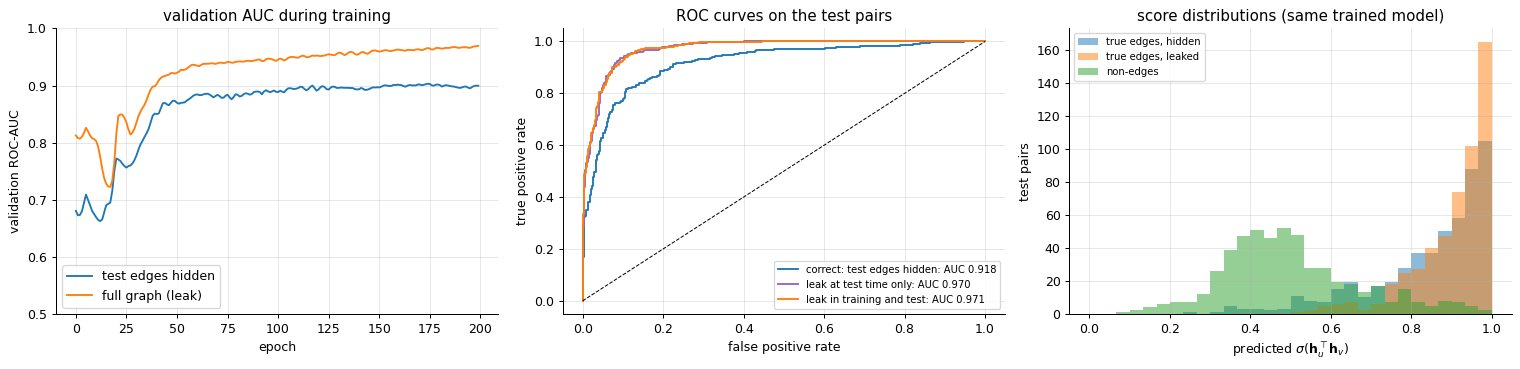

median score of the true test edges: hidden 0.894, leaked 0.934


In [43]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.2))
axes[0].plot(val_clean, label="test edges hidden"); axes[0].plot(val_leak, label="full graph (leak)")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("validation ROC-AUC"); axes[0].set_ylim(0.5, 1.0); axes[0].legend()
axes[0].set_title("validation AUC during training")
for (name, s), color in zip([("correct: test edges hidden", s_clean), ("leak at test time only", s_leak_eval),
                             ("leak in training and test", s_leak)], ["tab:blue", "tab:purple", "tab:orange"]):
    fpr, tpr, _ = roc_curve(y_test, s)
    axes[1].plot(fpr, tpr, color=color, label=f"{name}: AUC {auc[name]:.3f}")
axes[1].plot([0, 1], [0, 1], "k--", lw=0.8)
axes[1].set_xlabel("false positive rate"); axes[1].set_ylabel("true positive rate"); axes[1].legend(fontsize=8, loc="lower right")
axes[1].set_title("ROC curves on the test pairs")
bins = np.linspace(0, 1, 31)
axes[2].hist(s_clean[y_test == 1], bins=bins, alpha=0.5, label="true edges, hidden")
axes[2].hist(s_leak_eval[y_test == 1], bins=bins, alpha=0.5, label="true edges, leaked")
axes[2].hist(s_clean[y_test == 0], bins=bins, alpha=0.5, label="non-edges")
axes[2].set_xlabel(r"predicted $\sigma(\mathbf{h}_u^\top\mathbf{h}_v)$"); axes[2].set_ylabel("test pairs"); axes[2].legend(fontsize=8)
axes[2].set_title("score distributions (same trained model)")
plt.tight_layout(); plt.show()
print(f"median score of the true test edges: hidden {np.median(s_clean[y_test == 1]):.3f}, leaked {np.median(s_leak_eval[y_test == 1]):.3f}")

**What just happened?** Done correctly, the GCN encoder with a dot-product decoder reaches a test ROC-AUC of 0.918: it ranks a held-out citation above a random non-citation in about 92% of the pairs. Letting the test edges into the message-passing graph inflates it to 0.970 when the leak happens only at evaluation, and 0.971 when it happens in training and evaluation.

The mechanism is direct. If $u$–$v$ is in the message-passing graph, one GCN layer adds a share of $\mathbf{h}_v$ to $\mathbf{h}_u$ and vice versa, so $\mathbf{h}_u^\top\mathbf{h}_v$ is large **because the edge exists**. The model is not predicting the link, it is reading it. The score histogram shows it: the same trained model gives the true test edges higher scores when they are visible (median 0.93 against 0.89), and above all the tail of low-scored true edges, which is what costs AUC, shrinks.

**Lesson.** In link prediction the **targets are part of the input structure**, so the target edges must be removed from the graph the encoder sees: validation edges during model selection, test edges during testing, and in production, by definition, the links we want to predict are not there yet. This is the graph version of **target leakage** in tabular data, and it is easy to commit: one `data.edge_index` instead of `train_data.edge_index` in the wrong place is enough. The same care applies to the time dimension in practice: a fraud model must not see links that were created after the moment of the prediction.

In [44]:
print(f"whole notebook: {(time.time() - T_START) / 60:.1f} min on {device}")

whole notebook: 3.1 min on cpu


## 13. Summary

- **Graphs as data**: adjacency $\mathbf{A}$, degrees $\mathbf{D}$, features $\mathbf{X}$ (rows = nodes), stored as `edge_index` ($2 \times \lvert E\rvert$, both directions). Tasks at node, edge and graph level all start from node embeddings $\mathbf{h}_v$.
- **Symmetry**: node numbers are arbitrary, so node-level models must be **equivariant**, $f(\mathbf{P}\mathbf{X}, \mathbf{P}\mathbf{A}\mathbf{P}^\top) = \mathbf{P}f(\mathbf{X}, \mathbf{A})$, and graph-level models **invariant**. Shared weights and symmetric aggregation give this for free.
- **Message passing**: $\mathbf{h}_v^{(k+1)} = \text{UPDATE}\big(\mathbf{h}_v^{(k)}, \text{AGG}_{u \in \mathcal{N}(v)}\text{MSG}(\mathbf{h}_u^{(k)}, \mathbf{h}_v^{(k)})\big)$. $k$ layers see the $k$-hop neighbourhood.
- **GCN**: $\mathbf{H}^{(k+1)} = \sigma(\hat{\mathbf{A}}\mathbf{H}^{(k)}\mathbf{W}^{(k)})$ with $\hat{\mathbf{A}} = \tilde{\mathbf{D}}^{-1/2}(\mathbf{A} + \mathbf{I})\tilde{\mathbf{D}}^{-1/2}$; per node $\mathbf{h}_v' = \sigma\big(\sum_{u \in \mathcal{N}(v)\cup\{v\}} \mathbf{W}^\top\mathbf{h}_u/\sqrt{\tilde d_u\tilde d_v}\big)$. Self-loops keep the node's own vector; the normalisation keeps hubs and leaves on the same scale.
- **Spectral view**: $\mathbf{L} = \mathbf{D} - \mathbf{A}$, $\mathbf{x}^\top\mathbf{L}\mathbf{x} = \sum_{E}(x_u - x_v)^2$; eigenvectors are graph Fourier modes, and the Fiedler vector finds communities. $\hat{\mathbf{A}} = \mathbf{I} - \tilde{\mathbf{D}}^{-1/2}\mathbf{L}\tilde{\mathbf{D}}^{-1/2}$ has eigenvalues in $(-1, 1]$, so a GCN is a **low-pass filter**, and many layers **over-smooth**.
- **Implementation**: gather `H[src]`, weight, scatter-add at `dst`: $O(\lvert E\rvert d)$ instead of $O(n^2 d)$.
- **Cora**: homophily 0.81; MLP 57.3%, label propagation 73.1%, GCN 81.0%, GAT 81.7%. The graph is a strong regulariser when labels are scarce.
- **GAT**: $\alpha_{vu} = \text{softmax}_{u}\big(\text{LeakyReLU}(\mathbf{a}^\top[\mathbf{W}\mathbf{h}_v \Vert \mathbf{W}\mathbf{h}_u])\big)$, $\mathbf{h}_v' = \sum_u \alpha_{vu}\mathbf{W}\mathbf{h}_u$, multi-head. A transformer layer is attention on the complete graph plus positional encodings.
- **Depth**: 2 layers are best for a plain GCN; residual connections slow the collapse. The three classic limits: over-smoothing, over-squashing, heterophily.
- **Expressive power**: sum aggregation is injective on multisets, mean and max are not. Message-passing GNNs are at most as powerful as 1-WL; GIN, $\mathbf{h}_v' = \text{MLP}\big((1 + \varepsilon)\mathbf{h}_v + \sum_{u\in\mathcal{N}(v)}\mathbf{h}_u\big)$, reaches it. Two triangles and a hexagon look identical to all of them.
- **Graph classification**: batch = block-diagonal big graph + `batch` vector + readout. On small datasets (MUTAG, 188 graphs) the cross-validation standard deviation is about 5 to 9 points: compare models on the same folds and do not over-interpret small gaps.
- **Link prediction**: $\sigma(\mathbf{h}_u^\top\mathbf{h}_v)$, negative sampling, ROC-AUC. Remove the target edges from the message-passing graph (AUC 0.918 when done right, 0.971 with the leak).

## Exercises

Try each one before opening the answer.

1. **Equivariance.** Prove that a GCN layer with a bias, $\sigma(\hat{\mathbf{A}}\mathbf{X}\mathbf{W} + \mathbf{1}\mathbf{b}^\top)$, is permutation equivariant, and that the sum readout of its output is invariant.
2. **By hand.** Compute row E of $\hat{\mathbf{A}}\mathbf{X}$ for the toy graph of section 3. Compare with the mean aggregation $\tilde{\mathbf{D}}^{-1}\tilde{\mathbf{A}}\mathbf{X}$ and with the plain sum $\tilde{\mathbf{A}}\mathbf{X}$.
3. **Mean aggregation.** Why can a mean aggregator not distinguish the neighbourhoods $\{1, 1\}$ and $\{1\}$? Give an example of two neighbourhoods that the mean distinguishes and the max does not.
4. **Receptive field.** Which nodes can influence $\mathbf{h}_v$ after a 3-layer GNN? For node 11 of the karate club (a leaf attached to node 0), how many nodes does it see after 1, 2 and 3 layers?
5. **Directed graphs.** Cora's citations are directed in reality. What changes in `edge_index`, in the normalisation and in the spectral story of section 4 if we keep the direction?
6. **Two triangles vs a hexagon.** Propose a node feature that lets a message-passing GNN tell the two graphs of section 10c apart. Why does the node degree not work?
7. **Leakage.** Explain why the test edges must be hidden from the message-passing graph in link prediction, and what the leaky AUC would mean for a fraud team that deploys the model.

<details>
<summary><b>Answers</b></summary>

**1.** With $\mathbf{X}' = \mathbf{P}\mathbf{X}$ and $\mathbf{A}' = \mathbf{P}\mathbf{A}\mathbf{P}^\top$, section 2 showed $\hat{\mathbf{A}}' = \mathbf{P}\hat{\mathbf{A}}\mathbf{P}^\top$. The bias term is the same on every row, and $\mathbf{P}\mathbf{1} = \mathbf{1}$, so $\mathbf{1}\mathbf{b}^\top = \mathbf{P}\mathbf{1}\mathbf{b}^\top$. Then
$\sigma(\hat{\mathbf{A}}'\mathbf{X}'\mathbf{W} + \mathbf{1}\mathbf{b}^\top) = \sigma(\mathbf{P}\hat{\mathbf{A}}\mathbf{P}^\top\mathbf{P}\mathbf{X}\mathbf{W} + \mathbf{P}\mathbf{1}\mathbf{b}^\top) = \sigma(\mathbf{P}(\hat{\mathbf{A}}\mathbf{X}\mathbf{W} + \mathbf{1}\mathbf{b}^\top)) = \mathbf{P}\,\sigma(\hat{\mathbf{A}}\mathbf{X}\mathbf{W} + \mathbf{1}\mathbf{b}^\top)$, where the last step uses that $\sigma$ acts entry by entry. For the readout, $\mathbf{1}^\top(\mathbf{P}\mathbf{H}) = (\mathbf{P}^\top\mathbf{1})^\top\mathbf{H} = \mathbf{1}^\top\mathbf{H}$, because $\mathbf{P}^\top\mathbf{1} = \mathbf{1}$. A stack of such layers is equivariant by induction.

**2.** $\mathcal{N}(E) \cup \{E\} = \{D, E\}$, $\tilde d_D = 3$, $\tilde d_E = 2$. So $\mathbf{h}_E = \mathbf{x}_D/\sqrt{3 \cdot 2} + \mathbf{x}_E/\sqrt{2 \cdot 2} = [2, 0]/\sqrt 6 + [0, 2]/2 = [0.816, 1.000]$, the last row printed in section 3. The mean gives $([2, 0] + [0, 2])/2 = [1, 1]$ and the plain sum $[2, 2]$. The symmetric normalisation gives D's message less weight ($1/\sqrt 6 = 0.41$) than E's own vector ($1/2$), because D has more neighbours than E.

**3.** The mean divides by the number of neighbours: $(1 + 1)/2 = 1 = 1/1$. It only sees the proportion of each value, not the count, so a node cannot know how many neighbours share a property. Mean distinguishes but max does not: $\{1, 2\}$ (mean 1.5, max 2) and $\{1, 2, 2\}$ (mean 1.67, max 2). Max sees only which values occur.

**4.** A $k$-layer GNN computes $\mathbf{h}_v$ from the nodes at distance at most $k$ from $v$ (its $k$-hop neighbourhood), and nothing else: each layer extends the reach by one hop. Node 11 sees 2 nodes after 1 layer (itself and node 0), 17 after 2 layers (node 0 is a hub with 16 neighbours), and 26 of the 34 after 3 layers. You can check it with `len(nx.single_source_shortest_path_length(G, 11, cutoff=k))`. Hubs make the receptive field explode after very few layers, which is the root of over-squashing.

**5.** `edge_index` stores each citation once, as (citing, cited) or the reverse, so messages flow only one way: a paper hears only from the papers that cite it (or only from those it cites). $\mathbf{A}$ is no longer symmetric, so the in-degree and out-degree differ and the normalisation must choose, for example a mean over in-neighbours $\mathbf{D}_{\text{in}}^{-1}\mathbf{A}$. The spectral story breaks: a non-symmetric $\mathbf{L}$ may have complex eigenvalues and no orthonormal eigenbasis, so the low-pass interpretation no longer holds as such. In practice one either makes the graph undirected (as Cora does), or adds the reverse edges as a **second relation type** with its own weight matrix (as in relational GCNs), so that information flows both ways while the model still knows the direction.

**6.** Any feature that the local structure does not determine. The number of triangles through each node, $t_v = (\mathbf{A}^3)_{vv}/2$, is 1 for every node of the two triangles and 0 for every node of the hexagon, so even the readout of the input layer differs. Other options: the local clustering coefficient, the length of the shortest cycle through the node, Laplacian eigenvectors as positional encodings (the two triangles have eigenvalue 0 twice because they form two components), or random features. The degree does not work because it is 2 for every node of both graphs: it is exactly what 1-WL computes in its first round, and 1-WL already fails.

**7.** If the edge $u$–$v$ is in the message-passing graph, after one layer $\mathbf{h}_u$ contains a term proportional to $\mathbf{h}_v$ (and vice versa), so their dot product is high precisely for the pairs we test. The model reads the answer from its input; section 12 showed the AUC jumping from 0.918 to 0.971. In deployment the links to predict (an undisclosed relation between a claimant and a garage, say) are by definition absent from the graph, so the real performance is the clean one. A fraud team that trusted the leaky number would set thresholds and expected catch rates that the model cannot deliver, and would discover it only after investigators had wasted time on false alarms or missed real cases.

</details>